### 1. Environment setup

In [1]:
#1
import numpy as np
import pandas as pd
import plotly.graph_objects as go

import matplotlib.pyplot as plt

import sys
from pathlib import Path

repo_dir = Path.cwd().parents[1]

if str(repo_dir) not in sys.path:
    sys.path.insert(0, str(repo_dir))

In [2]:
#3

from pv_chip_aarhus.analysis.data_io import DataIO
from pv_chip_aarhus.analysis.analysis_params import dataset_dir

# Create temporary DataIO object
catalog = DataIO(dataset_dir)

print("Sessions in datadir:")

for sid in catalog.sessions:
    print(f"    {sid}")

Sessions in datadir:
    20260603_eye2_2nd


### 2. Load data (Change session IDs here)

In [3]:
import inspect

print(inspect.getfile(DataIO))

c:\Users\au617715\Documents\MEA_experiments_analysis_code\mea_experiments\pv_chip_aarhus\analysis\data_io.py


In [4]:
import inspect
from pv_chip_aarhus.preprocessing import dataset_sessions as ds

print(inspect.getfile(ds))
print(ds.dataset_sessions.keys())

c:\Users\au617715\Documents\MEA_experiments_analysis_code\mea_experiments\pv_chip_aarhus\preprocessing\dataset_sessions.py
dict_keys(['20260603_eye2_2nd'])


In [5]:
# #5

# # ==========================================
# # Sessions to load
# # ==========================================

# session_ids = [

#     "20260601_eye1_1st",

# ]

# all_data_io = {}

# # ==========================================
# # Load sessions
# # ==========================================

# for session_id in session_ids:

#     session_data = DataIO(dataset_dir)

#     session_data.load_session(session_id)

#     all_data_io[session_id] = session_data

#     print(f"\nLoaded session: {session_id}")

#     print(f"Recordings : {len(session_data.recording_df)}")
#     print(f"Clusters   : {len(session_data.cluster_df)}")
#     print(f"Trials     : {len(session_data.trial_df)}")
#     print(f"Bursts     : {len(session_data.burst_df)}")

### 3. Access tables with metadata
All tables are pandas dataframes. These are the attributes I used all the time:

`df.index.values`: the index for each row, this can be used to quickly access a row

`df.loc[INDEX]`: this is how to index into a row

`df.columns`: list available columns

`df.loc[INDEX, COLUMN]` : gives value of a single cell

`df.query("COLUMN == VALUE")` : filters the dataframe based on column values

`df.iterrows()`  : allow you to loop over  each row of the table

In [6]:
# #6

# # ==========================================
# # Dataset overview
# # ==========================================

# for session_id, session_data in all_data_io.items():

#     print(f"\n{'=' * 60}")
#     print(session_id)
#     print(f"{'=' * 60}")

#     print(f"Recordings : {len(session_data.recording_df)}")
#     print(f"Clusters   : {len(session_data.cluster_df)}")
#     print(f"Trials     : {len(session_data.trial_df)}")
#     print(f"Bursts     : {len(session_data.burst_df)}")

#     print("\nAvailable recordings:")

#     for rec_id in sorted(session_data.spiketimes.keys()):
#         print(f"    {rec_id}")

In [7]:
# #8

# # ==========================================
# # Data sanity check
# # ==========================================

# for session_id, session_data in all_data_io.items():

#     print(f"\nSession: {session_id}")

#     print(
#         f"Spike recordings : "
#         f"{len(session_data.spiketimes)}"
#     )

#     print(
#         f"Clusters         : "
#         f"{len(session_data.cluster_df)}"
#     )

#     print(
#         f"Bursts           : "
#         f"{len(session_data.burst_df)}"
#     )

### 4. Select recording, unit and other analysis parameters

In [8]:
#15
# Experimental recording
#
# Naming convention:
#
# XX_MODE_SOURCE_PROTOCOL
#
# Examples:
#
# 02_N_P_pow
#     Irradiance series
#     Normal pulsed stimulation
#     Polychrome only
#
# 07_N_L_dur
#     Duration series
#     Normal pulsed stimulation
#     Laser only
#
# 15_N_P_longstim
#     Long stimulation protocol
#
# ==========================================
# Analysis parameters
# ==========================================

selected_session = "20260601_eye1_1st"

# Experiment to analyse
protocol = "dur"          # pow, dur, freq, del, del2, longstim
stim_mode = "L"           # P, L or B
laser_mode = "N"          # N or LC

# Optional manual override
manual_rec_id = None      # e.g. "05_N_P_dur"

# Cluster
unit_id = "uid_20260601_012"

# Analysis window (ms)
t_pre = 1000
t_post = 7000

analysis_window = (-t_pre, t_post)

### 4. Selection of parameters (Helping part)

In [9]:
# #16
# # ==========================================
# # Select recording
# # ==========================================
# session_data = all_data_io[selected_session]

# if manual_rec_id is not None:

#     rec_id = manual_rec_id

# else:

#     candidates = sorted(
#         rec
#         for rec in session_data.spiketimes.keys()
#         if (
#             rec.endswith(protocol)
#             and f"_{stim_mode}_" in rec
#             and rec.split("_")[1] == laser_mode
#         )
#     )

#     if len(candidates) == 0:
#         raise ValueError("No matching recording found.")

#     # Always use the newest repeat
#     rec_id = candidates[-1]

# print(f"Selected recording: {rec_id}")

In [10]:
# #17
# print("Current analysis")
# print("----------------")
# print(f"Selected session    : {selected_session}")
# print(f"Recording           : {rec_id}")
# print(f"Unit                : {unit_id}")
# print(f"Protocol            : {protocol}")
# print(f"Stim. mode          : {stim_mode}")
# print(f"Laser mode          : {laser_mode}")
# print(f"Window              : {-t_pre} to +{t_post} ms")

In [11]:
# #18
# assert rec_id in session_data.spiketimes, (
#     f"{rec_id} not found.\n"
#     f"Available recordings:\n"
#     f"{list(session_data.spiketimes.keys())}"
# )

# assert unit_id in session_data.spiketimes[rec_id], (
#     f"{unit_id} not found in {rec_id}"
# )

In [12]:
#19
# ==========================================
# Stimulation metadata definitions
# ==========================================

"""
Metadata column definitions for the two stimulation sources.

These dictionaries are used throughout the notebook when
constructing analysis views.
"""

pchr_columns = {

    "onset": "pchr_onset",
    "duration": "pchr_on_duration",
    "off_duration": "pchr_off_duration",
    "delay": "pchr_delay",
    "power": "pchr_power",
    "frequency": "pchr_frequency",

}

laser_columns = {

    "onset": "laser_onset",
    "duration": "laser_on_duration",
    "off_duration": "laser_off_duration",
    "delay": "laser_delay",
    "power": "laser_power",
    "frequency": "laser_frequency",

}

### 5. Determine analysis views <- Helper cell

#### 19.5

In [13]:
#19.5
# HELPER FUNCTION
# ==========================================
# Prepare recording-specific analysis state
# ==========================================

def prepare_recording_analysis(
    data_io,
    rec_id,
    protocol,
    stim_mode,
    pchr_columns,
    laser_columns,
):
    # ==========================================
    # Determine recording-specific parameters
    # ==========================================

    """
    Prepare one or more analysis views for the selected recording.

    Each analysis view contains all metadata required by the
    downstream analysis.

    Ordinary recordings contain one analysis view.

    Combined LC_B recordings contain two independent analysis
    views:

        Polychrome
        Laser

    Downstream code should always obtain metadata from the
    selected analysis view rather than relying on recording-level
    variables.
    """

    # ------------------------------------------
    # Determine grouping label
    # ------------------------------------------

    if protocol == "pow":

        group_label = "Irradiance"

    elif protocol == "dur":

        group_label = "Pulse duration (ms)"

    elif protocol == "freq":

        group_label = "Pulse frequency (Hz)"

    elif protocol == "longstim":

        group_label = "Stimulation duration (ms)"

    elif protocol in ["del", "del2"]:

        group_label = "Delay condition"

    else:

        raise ValueError(
            f"Unknown protocol: {protocol}"
        )

    # ------------------------------------------
    # Select bursts belonging to the recording
    # ------------------------------------------

    burst_df = (
        data_io.burst_df
        .query("rec_id == @rec_id")
        .copy()
    )

    assert not burst_df.empty, (
        f"No bursts found for recording {rec_id}"
    )

    # ------------------------------------------
    # Helper functions
    # ------------------------------------------

    def build_stim_windows(burst_info, stim_source):
        """
        Determine the alignment onset and stimulation windows.

        Returns
        -------
        alignment_onset : float
            Absolute recording time used to align spikes.

        windows : list
            List of (x0, x1, label) tuples relative to the
            alignment onset.
        """

        if protocol in ["del", "del2"]:

            # Delay metadata indicate which stimulus is delayed:
            #
            # pchr_delay  > 0 : Polychrome starts after Laser
            # laser_delay > 0 : Laser starts after Polychrome
            #
            # Only one onset is stored in the metadata. The other onset is
            # reconstructed here.
            p_on = burst_info["pchr_onset"]
            l_on = burst_info["laser_onset"]

            # Delay metadata indicate which stimulus is delayed.
            # Only one onset is stored; reconstruct the other.

            if np.isnan(l_on):

                if burst_info["pchr_delay"] > 0:
                    # Polychrome is delayed relative to the laser
                    l_on = (
                        p_on
                        - burst_info["pchr_delay"]
                    )

                else:
                    # Laser is delayed relative to the polychrome
                    l_on = (
                        p_on
                        + burst_info["laser_delay"]
                    )

            elif np.isnan(p_on):

                if burst_info["laser_delay"] > 0:
                    p_on = (
                        l_on
                        - burst_info["laser_delay"]
                    )

                else:
                    p_on = (
                        l_on
                        + burst_info["pchr_delay"]
                    )

            alignment = min(p_on, l_on)

            p_on -= alignment
            l_on -= alignment
                    

        else:

            if stim_source == "P":

                alignment = burst_info["pchr_onset"]

                p_on = 0
                l_on = None

            elif stim_source == "L":

                alignment = burst_info["laser_onset"]

                p_on = None
                l_on = 0

            else:

                raise ValueError(
                    f"Unknown stimulation source: {stim_source}"
                )

        windows = []

        if p_on is not None:
            windows.append(
                (
                    p_on,
                    p_on + burst_info["pchr_on_duration"],
                    "Polychrome",
                )
            )

        if l_on is not None:
            windows.append(
                (
                    l_on,
                    l_on + burst_info["laser_on_duration"],
                    "Laser",
                )
            )

        return alignment, windows


    def make_view(name, stim_source, columns):
        """Create one analysis view."""

        if protocol == "pow":
            group_column = columns["power"]

        elif protocol == "dur":
            group_column = columns["duration"]

        elif protocol == "freq":
            group_column = columns["frequency"]

        elif protocol == "longstim":
            group_column = columns["duration"]

        elif protocol in ["del", "del2"]:
            group_column = columns["delay"]

        else:
            raise ValueError(protocol)

        return {

            "name": name,

            "stim_source": stim_source,

            "group_column": group_column,
            "group_label": group_label,

            "onset_column": columns["onset"],

            "on_duration_column": columns["duration"],
            "off_duration_column": columns["off_duration"],

            "power_column": columns["power"],
            "frequency_column": columns["frequency"],

            # New
            "stim_windows": (
                lambda burst_info:
                    build_stim_windows(
                        burst_info,
                        stim_source,
                    )
            ),

        }

    # ------------------------------------------
    # Build analysis views
    # ------------------------------------------

    analysis_views = []

    if stim_mode == "P":

        analysis_views.append(
            make_view(
                "Polychrome",
                "P",
                pchr_columns,
            )
        )

    elif stim_mode == "L":

        analysis_views.append(
            make_view(
                "Laser",
                "L",
                laser_columns,
            )
        )

    elif stim_mode == "B":

        analysis_views.append(
            make_view(
                "Polychrome",
                "P",
                pchr_columns,
            )
        )

        analysis_views.append(
            make_view(
                "Laser",
                "L",
                laser_columns,
            )
        )

    else:

        raise ValueError(
            f"Unknown stimulation mode: {stim_mode}"
        )
    
    return (
        burst_df,
        analysis_views,
        group_label,
    )

#### 20

In [14]:
# #20

# burst_df, analysis_views, group_label = prepare_recording_analysis(

#     data_io=data_io,

#     rec_id=rec_id,

#     protocol=protocol,

#     stim_mode=stim_mode,

#     pchr_columns=pchr_columns,

#     laser_columns=laser_columns,

# )

# # ------------------------------------------
# # Backwards compatibility
# # ------------------------------------------

# current_view = analysis_views[0]

# group_column = current_view["group_column"]
# group_label = current_view["group_label"]

# onset_column = current_view["onset_column"]

# on_duration_column = current_view["on_duration_column"]
# off_duration_column = current_view["off_duration_column"]

# power_column = current_view["power_column"]
# frequency_column = current_view["frequency_column"]

# # ------------------------------------------
# # Summary
# # ------------------------------------------

# print("Analysis views")
# print("--------------")

# for view in analysis_views:

#     print(
#         f"{view['name']:<12}"
#         f" source={view['stim_source']}"
#         f" group={view['group_column']}"
#         f" onset={view['onset_column']}"
#     )

### 6. Extract stimulus-aligned spike trains

#### Function #21

In [15]:
#21
# ==========================================
# Extract stimulus-aligned spike trains
# ==========================================

"""
Goal
----
Convert one continuous spike train from a single unit
into many stimulus-aligned spike trains.

The original spike train contains the firing activity
throughout the entire recording.

For each stimulation burst, spikes are extracted within
a time window around stimulus onset and shifted so that

    0 ms = stimulus onset

The output is a dictionary:

all_spiketimes[train_id] = [
    burst_1_spikes,
    burst_2_spikes,
    ...
]

Each burst therefore contains spike times relative to
stimulus onset and is ready for raster plotting or
statistical analysis.
"""

def extract_spikes(
    session_data,
    rec_id,
    unit_id,
    verbose=True,
):
    """
    Extract stimulus-aligned spike trains
    for one unit.

    Parameters
    ----------
    session_data : object
        Session data object containing spike times.

    rec_id : str
        Recording identifier.

    unit_id : str
        Unit identifier.

    verbose : bool, default=True
        Print extraction progress and summary.

    Returns
    -------
    dict
        all_spiketimes
    """

    assert rec_id in session_data.spiketimes, (
        f"{rec_id} not found in spiketimes."
    )

    assert unit_id in session_data.spiketimes[rec_id], (
        f"{unit_id} not found in recording {rec_id}."
    )

    # ------------------------------------------
    # Extract stimulus-aligned spike trains
    # ------------------------------------------

    # Dictionary of extracted spike trains.
    #
    # Structure
    # ---------
    # all_spiketimes[view_name][train_id]
    #
    # Example
    # -------
    # all_spiketimes["Polychrome"]["tid_001"]
    #
    all_spiketimes = {}

    # ------------------------------------------
    # Loop over analysis views
    # ------------------------------------------

    for view in analysis_views:

        if verbose:
            print(f"\nExtracting {view['name']} responses")

        # Helper describing the stimulation timing
        stim_windows = view["stim_windows"]

        # Load the complete spike train for the selected unit
        spiketrain = session_data.spiketimes[rec_id][unit_id]

        view_spiketimes = {}

        # Loop over each stimulation condition
        for train_id, train_df in burst_df.groupby("train_id"):

            spiketimes_trial = []

            # Loop over every stimulation burst
            for _, burst_info in train_df.iterrows():

                # ----------------------------------
                # Determine alignment onset
                # ----------------------------------

                alignment_onset, _ = stim_windows(
                    burst_info
                )
                idx = np.where(
                    (spiketrain >= alignment_onset - t_pre)
                    & (spiketrain <= alignment_onset + t_post)
                )[0]

                spiketimes_burst = (
                    spiketrain[idx] - alignment_onset
                )

                spiketimes_trial.append(
                    spiketimes_burst
                )

            view_spiketimes[train_id] = spiketimes_trial

        all_spiketimes[view["name"]] = view_spiketimes

    # ------------------------------------------
    # Summary
    # ------------------------------------------

    if verbose:

        print("\nExtraction complete")
        print("-------------------")
        print(f"Recording : {rec_id}")
        print(f"Unit      : {unit_id}")

        for view_name, view_data in all_spiketimes.items():

            print(f"\n{view_name}")

            for train_id, spikes in view_data.items():

                print(
                    f"  {train_id}: "
                    f"{len(spikes)} repetitions"
                )
            
    return all_spiketimes

### 7. Raster plot: Single units

In [16]:
# #25
# import plotly.graph_objects as go

# fig = go.Figure()

# # ------------------------------------------
# # Stimulation legend
# # ------------------------------------------

# fig.add_scatter(
#     x=[None], y=[None],
#     mode="markers",
#     marker=dict(size=12, color="royalblue"),
#     name="Polychrome",
# )

# fig.add_scatter(
#     x=[None], y=[None],
#     mode="markers",
#     marker=dict(size=12, color="crimson"),
#     name="Laser",
# )

# fig.add_scatter(
#     x=[None], y=[None],
#     mode="markers",
#     marker=dict(size=12, color="mediumpurple"),
#     name="Both",
# )

# # ------------------------------------------
# # Select analysis view
# # ------------------------------------------

# """
# Select which stimulation view to display.

# For ordinary recordings there is only one available view.
# For combined (LC_B) recordings this can be either
# 'Polychrome' or 'Laser'.
# """

# # For now, display the first available view.
# # Later this can become:
# #
# #     for view in analysis_views:
# #
# view = analysis_views[0]

# view_name = view["name"]
# view_spiketimes = all_spiketimes[view_name]
# stim_windows = view["stim_windows"]

# # Metadata for this analysis view
# group_column = view["group_column"]
# group_label = view["group_label"]

# on_duration_column = view["on_duration_column"]
# off_duration_column = view["off_duration_column"]

# print(f"Displaying {view_name}")
# print(f"Grouping by : {group_column}")

# # ------------------------------------------
# # Vertical offsets
# # ------------------------------------------

# burst_offset = 0

# # Spike coordinates
# x_plot = []
# y_plot = []

# # Tick labels
# yticks = []
# ytext = []

# # ------------------------------------------
# # Trial metadata
# # ------------------------------------------

# trial_df = (
#     session_data.trial_df
#     .query("train_id in @view_spiketimes.keys()")
# )

# # ------------------------------------------
# # Order stimulation conditions
# # ------------------------------------------

# sorted_train_ids = (
#     trial_df
#     .sort_values(group_column)
#     .drop_duplicates("train_id")
#     ["train_id"]
#     .tolist()
# )

# # ------------------------------------------
# # Determine x-axis limits
# # ------------------------------------------

# cycle_durations = (
#     trial_df[on_duration_column]
#     + trial_df[off_duration_column]
# )

# min_cycle_duration = cycle_durations.min()
# max_cycle_duration = cycle_durations.max()

# x_axis_start = -min(
#     t_pre,
#     min_cycle_duration,
# )

# x_axis_end = min(
#     t_post,
#     max_cycle_duration,
# )

# # ------------------------------------------
# # Draw raster
# # ------------------------------------------

# for train_id in sorted_train_ids:

#     spiketrains = view_spiketimes[train_id]

#     df = trial_df.query(
#         "train_id == @train_id"
#     )

#     group_value = df.iloc[0][group_column]

#     row = burst_df.query(
#         "train_id == @train_id"
#     ).iloc[0]

#     off_duration = df.iloc[0][off_duration_column]

#     # End of the final stimulus in this burst
#     _, windows = stim_windows(row)
#     stimulus_duration = max(
#         x1 - x0
#         for x0, x1, _ in windows
#     )

#     stimulus_end = max(
#         x1 for _, x1, _ in windows
#     )

#     # Display one complete stimulation cycle,
#     # but never beyond the analysis window.
#     display_end = min(
#         analysis_window[1],
#         stimulus_end + off_duration,
#     )

#     print(
#         f"{train_id}: "
#         f"{group_column} = {group_value}"
#     )

#     group_start = burst_offset

#     for sp in spiketrains:

#         # Only display spikes within one stimulation cycle
#         sp = sp[
#             (sp >= analysis_window[0]) &
#             (sp <= display_end)
#         ]

#         x_plot.append(
#             np.vstack([
#                 sp,
#                 sp,
#                 np.full(sp.size, np.nan)
#             ]).T.flatten()
#         )

#         y_plot.append(
#             np.vstack([
#                 np.ones(sp.size) * burst_offset,
#                 np.ones(sp.size) * (burst_offset + 1),
#                 np.full(sp.size, np.nan)
#             ]).T.flatten()
#         )

#         burst_offset += 1

#     group_end = burst_offset
   
#     # --------------------------------------
#     # Stimulation windows
#     # --------------------------------------

#     yticks.append(
#         (group_start + group_end) / 2
#     )

#     ytext.append(group_value)

#     _, windows = stim_windows(row)

#     colour_map = {
#         "Polychrome": "royalblue",
#         "Laser": "crimson",
#     }

#     segments = [
#         (x0, x1, colour_map[label])
#         for x0, x1, label in windows
#     ]

#     # Draw overlap in purple

#     if len(segments) == 2:

#         polychrome = next(
#             s for s in segments
#             if s[2] == "royalblue"
#         )

#         laser = next(
#             s for s in segments
#             if s[2] == "crimson"
#         )

#         p0, p1, _ = polychrome
#         l0, l1, _ = laser

#         overlap0 = max(p0, l0)
#         overlap1 = min(p1, l1)

#         if overlap1 > overlap0:

#             fig.add_shape(
#                 type="rect",
#                 x0=overlap0,
#                 x1=overlap1,
#                 y0=group_start,
#                 y1=group_end,
#                 fillcolor="mediumpurple",
#                 opacity=0.35,
#                 line_width=0,
#                 layer="below",
#             )

#             if p0 < overlap0:

#                 fig.add_shape(
#                     type="rect",
#                     x0=p0,
#                     x1=overlap0,
#                     y0=group_start,
#                     y1=group_end,
#                     fillcolor="royalblue",
#                     opacity=0.30,
#                     line_width=0,
#                     layer="below",
#                 )

#             if overlap1 < p1:

#                 fig.add_shape(
#                     type="rect",
#                     x0=overlap1,
#                     x1=p1,
#                     y0=group_start,
#                     y1=group_end,
#                     fillcolor="royalblue",
#                     opacity=0.30,
#                     line_width=0,
#                     layer="below",
#                 )

#             if l0 < overlap0:

#                 fig.add_shape(
#                     type="rect",
#                     x0=l0,
#                     x1=overlap0,
#                     y0=group_start,
#                     y1=group_end,
#                     fillcolor="crimson",
#                     opacity=0.30,
#                     line_width=0,
#                     layer="below",
#                 )

#             if overlap1 < l1:

#                 fig.add_shape(
#                     type="rect",
#                     x0=overlap1,
#                     x1=l1,
#                     y0=group_start,
#                     y1=group_end,
#                     fillcolor="crimson",
#                     opacity=0.30,
#                     line_width=0,
#                     layer="below",
#                 )

#         else:

#             for x0, x1, color in segments:

#                 fig.add_shape(
#                     type="rect",
#                     x0=x0,
#                     x1=x1,
#                     y0=group_start,
#                     y1=group_end,
#                     fillcolor=color,
#                     opacity=0.30,
#                     line_width=0,
#                     layer="below",
#                 )

#     else:

#         for x0, x1, color in segments:

#             fig.add_shape(
#                 type="rect",
#                 x0=x0,
#                 x1=x1,
#                 y0=group_start,
#                 y1=group_end,
#                 fillcolor=color,
#                 opacity=0.30,
#                 line_width=0,
#                 layer="below",
#             )

# # ------------------------------------------
# # Combine raster lines
# # ------------------------------------------

# if len(x_plot):

#     x_plot = np.hstack(x_plot)
#     y_plot = np.hstack(y_plot)

#     fig.add_scatter(

#         x=x_plot,
#         y=y_plot,

#         mode="lines",

#         line=dict(
#             width=2,
#             color="black",
#         ),

#         showlegend=False,

#     )

# # ------------------------------------------
# # Axes
# # ------------------------------------------

# fig.update_yaxes(

#     tickmode="array",

#     tickvals=yticks,
#     ticktext=ytext,

#     title=group_label,

#     autorange="reversed",

# )

# fig.update_xaxes(

#     title="Time from stimulus onset (ms)",

#     range=[
#         x_axis_start,
#         x_axis_end,
#     ],

# )

# fig.update_layout(

#     title=(
#         f"{view_name} raster plot\n"
#         f"{session_id} | {rec_id} | {unit_id}"
#     ),

#     height=900,

# )

# fig.show()

### 8. Bootstrap significance

### 9. Population analysis

#### Session database (Add new session here) (31)

In [17]:
#31

from pathlib import Path

session_database = {

    "20260527_eye2_1st": {
    
            "dataset_dir": Path(
                r"D:\ACJ\20260527\20260527 No chip rd1 763 eye2 1st half\Analysis\raw_filtered\dataset"
            ),
    
            "implant": "none",
            "chrimsonr": True,
            "tags": [],
    
        },

    "20260601_eye1_1st": {

        "dataset_dir": Path(
            r"D:\ACJ\20260601\20260601 PV chip rd1 770 eye1 1st half\Analysis\raw_filtered\dataset"
        ),

        "implant": "functional",
        "chrimsonr": True,
        "tags": ["good_quality"],

    },

    "20260603_eye2_2nd": {
        
                "dataset_dir": Path(
                    r"D:\ACJ\20260603\20260603 Fake chip d-grease rd1 766 eye2 2nd half\Analysis\raw_filtered\dataset"
                ),
        
                "implant": "nonfunctional",
                "chrimsonr": True,
                "tags": [],
        
        },

    "20260604_eye1_2nd": {
        
                "dataset_dir": Path(
                    r"D:\ACJ\20260604\20260604 PV chip d-grease rd1 758 eye1 2nd half\Analysis\raw_filtered\dataset"
                ),
        
                "implant": "functional",
                "chrimsonr": False,
                "tags": [],
        
        },

    "20260604_eye2_2nd": {

        "dataset_dir": Path(
            r"D:\ACJ\20260604\20260604 Fake chip d-grease rd1 758 eye2 2nd half\Analysis\raw_filtered\dataset"
        ),

        "implant": "nonfunctional",
        "chrimsonr": False,
        "tags": [],

    },

}

#### Analysis configuration

In [18]:
#32
# ==========================================
# Population analysis configuration
# ==========================================

analysis_config = {

    # --------------------------------------
    # Session selection
    # --------------------------------------

    # If this list is non-empty, analyse only these sessions.
    # Otherwise use the metadata filters below.

    "sessions": [

         "20260601_eye1_1st",
         "20260603_eye2_2nd",
         "20260604_eye1_2nd",
         "20260604_eye2_2nd",
        # "20260602_eye2",
        

    ],

    # --------------------------------------
    # Session metadata filters
    # --------------------------------------

    # Used only when "sessions" is None.

    "implant": [

        # "functional",
        # "nonfunctional",
        # "none",

    ],

    "chrimsonr": [

        # True,
        # False,

    ],

    "tags": [

        # "good_quality",

    ],

    # --------------------------------------
    # Recording filters
    # --------------------------------------

    "protocols": [

        "pow",
        "dur",
        "del",
        "del2",
        "longstim",

    ],

    "stim_modes": [

        "P",
        "L",
        "B",

    ],

    "laser_modes": [

        "N",

    ],

    # --------------------------------------
    # Manual recording selection
    # --------------------------------------

    "include_recordings": [

        # "04_LC_B_pow",

    ],

    "exclude_recordings": [

        # "07_N_L_dur",

    ],

    # --------------------------------------
    # Analysis options
    # --------------------------------------

    "offset_baseline_mode": "onset_baseline",

}

#### Select sessions for analysis, no variables (33)

In [19]:
#33

# ==========================================
# Select sessions
# ==========================================

print("Selecting sessions...")

selected_sessions = []

selected_session_info = {}

# ==========================================
# Manual selection
# ==========================================

if len(analysis_config["sessions"]) > 0:

    for session_id in analysis_config["sessions"]:

        if session_id not in session_database:

            print(

                f"Warning: "

                f"{session_id} not found."

            )

            continue

        selected_sessions.append(

            session_id

        )

        selected_session_info[session_id] = (

            session_database[session_id]

        )

# ==========================================
# Metadata selection
# ==========================================

else:

    for session_id, info in session_database.items():

        # ----------------------------------
        # Implant filter
        # ----------------------------------

        if (

            len(analysis_config["implant"]) > 0

            and

            info["implant"]

            not in analysis_config["implant"]

        ):

            continue

        # ----------------------------------
        # ChrimsonR filter
        # ----------------------------------

        if (

            len(analysis_config["chrimsonr"]) > 0

            and

            info["chrimsonr"]

            not in analysis_config["chrimsonr"]

        ):

            continue

        # ----------------------------------
        # Tag filter
        # ----------------------------------

        if len(analysis_config["tags"]) > 0:

            if not any(

                tag in info["tags"]

                for tag in analysis_config["tags"]

            ):

                continue

        selected_sessions.append(

            session_id

        )

        selected_session_info[session_id] = info

# ==========================================
# Summary
# ==========================================

print()

print(

    f"Selected "

    f"{len(selected_sessions)} session(s)"

)

for session_id in selected_sessions:

    info = selected_session_info[session_id]

    print(

        f"{session_id:<25}"

        f"{info['implant']:<15}"

        f"ChrimsonR={info['chrimsonr']}"

    )

Selecting sessions...

Selected 4 session(s)
20260601_eye1_1st        functional     ChrimsonR=True
20260603_eye2_2nd        nonfunctional  ChrimsonR=True
20260604_eye1_2nd        functional     ChrimsonR=False
20260604_eye2_2nd        nonfunctional  ChrimsonR=False


In [20]:
#34
# ==========================================
# Load selected sessions
# ==========================================

all_data_io = {}

print("Selected sessions")
print("-----------------")

for session_id in selected_sessions:

    print(session_id)

for session_id in selected_sessions:

    dataset_dir = selected_session_info[session_id]["dataset_dir"]

    session_data = DataIO(dataset_dir)

    session_data.load_session(session_id)

    all_data_io[session_id] = session_data

    print(f"\nLoaded session: {session_id}")

    print(f"Recordings : {len(session_data.recording_df)}")
    print(f"Clusters   : {len(session_data.cluster_df)}")
    print(f"Trials     : {len(session_data.trial_df)}")
    print(f"Bursts     : {len(session_data.burst_df)}")

Selected sessions
-----------------
20260601_eye1_1st
20260603_eye2_2nd
20260604_eye1_2nd
20260604_eye2_2nd

Loaded session: 20260601_eye1_1st
Recordings : 15
Clusters   : 49
Trials     : 62
Bursts     : 1860

Loaded session: 20260603_eye2_2nd
Recordings : 11
Clusters   : 18
Trials     : 45
Bursts     : 1350

Loaded session: 20260604_eye1_2nd
Recordings : 10
Clusters   : 41
Trials     : 42
Bursts     : 1260

Loaded session: 20260604_eye2_2nd
Recordings : 10
Clusters   : 39
Trials     : 42
Bursts     : 1260


#### Load previously saved bootstrap

In [21]:
#36

from pathlib import Path
import pickle

# ==========================================
# Load population bootstrap results
# ==========================================

results_dir = Path(

    r"C:\Users\au617715\Documents\MEA_results_DO_NOT_TOUCH"

)

cache_version = "v2"

population_bootstrap = {}

loaded_sessions = 0

loaded_recordings = 0

# ==========================================
# Load selected sessions
# ==========================================

for session_id in selected_sessions:

    session_dir = results_dir / session_id

    if not session_dir.exists():

        print(

            f"Warning: Session not found: "

            f"{session_id}"

        )

        continue

    population_bootstrap[session_id] = {}

    recording_count = 0

    for result_file in sorted(

        session_dir.glob(

            f"*_{cache_version}.pkl"

        )

    ):

        rec_id = result_file.stem.replace(

            f"_{cache_version}",

            "",

        )

        with result_file.open("rb") as f:

            population_bootstrap[session_id][rec_id] = (

                pickle.load(f)

            )

        recording_count += 1

        loaded_recordings += 1

    print(

        f"{session_id:<25}"

        f"{recording_count:>3} recordings"

    )

    loaded_sessions += 1

# ==========================================
# Summary
# ==========================================

print()

print(

    f"Loaded {loaded_recordings} recording(s)"

)

print(

    f"Across {loaded_sessions} session(s)"

)

20260601_eye1_1st          9 recordings
20260603_eye2_2nd          7 recordings
20260604_eye1_2nd          7 recordings
20260604_eye2_2nd          7 recordings

Loaded 30 recording(s)
Across 4 session(s)


#### Testing loaded data

In [22]:
#36a
# ==========================================
# Inspect cached bootstrap structure
# ==========================================

session_id = next(iter(population_bootstrap))
rec_id = next(iter(population_bootstrap[session_id]))
unit_id = next(iter(population_bootstrap[session_id][rec_id]))

unit_results = population_bootstrap[session_id][rec_id][unit_id]

print(f"Session : {session_id}")
print(f"Recording : {rec_id}")
print(f"Unit : {unit_id}")

print("\nTop-level keys:")
print(unit_results.keys())

Session : 20260601_eye1_1st
Recording : 01_N_P_pow
Unit : uid_20260601_000

Top-level keys:
dict_keys(['onset_baseline', 'pre_offset'])


In [23]:
#36b
view_name = next(iter(unit_results))
train_id = next(iter(unit_results[view_name]))
event_name = next(iter(unit_results[view_name][train_id]))

result = unit_results[view_name][train_id][event_name]

print(f"View : {view_name}")
print(f"Train : {train_id}")
print(f"Event : {event_name}")

print("\nResult keys:")
for key in result.keys():
    print(key)

View : onset_baseline
Train : Polychrome
Event : tid_000_01

Result keys:
onset
offset


#### Building Population Summary table

In [24]:
#37
# ==========================================
# Build population summary table
# ==========================================

def build_population_summary(
    population_bootstrap,
    selected_session_info,
):
    """
    Convert bootstrap results from all analysed units into one
    tidy DataFrame.

    One row corresponds to one

        unit
        analysis view
        stimulation condition
        alignment event

    No statistics are recomputed here. This function simply
    reorganises the output from run_bootstrap_analysis().

    Parameters
    ----------
    population_bootstrap : dict
        Bootstrap results for all analysed sessions.

    selected_session_info : dict
        Session metadata for the selected sessions.

    Returns
    -------
    pandas.DataFrame
    """

    rows = []

    # ------------------------------------------
    # Loop over analysed units
    # ------------------------------------------

    for session_id, session_results in population_bootstrap.items():

        # ------------------------------------------
        # Session metadata
        # ------------------------------------------

        session_info = selected_session_info[session_id]

        for rec_id, recording_results in session_results.items():

            for unit_id, unit_results in recording_results.items():

                for baseline_mode, baseline_results in unit_results.items():

                    for view_name, view_results in baseline_results.items():

                        for train_id, train_results in view_results.items():

                            for event_name, result in train_results.items():

                                excited_bins = result.get("excited_bins")
                                inhibited_bins = result.get("inhibited_bins")

                                rec_parts = rec_id.split("_")

                                assert len(rec_parts) == 4, (
                                    f"Unexpected rec_id format: {rec_id}"
                                )

                                row = {

                                    # ----------------------------------
                                    # Identifiers
                                    # ----------------------------------

                                    "session_id": session_id,
                                    "rec_id": rec_id,

                                    "unit_id": unit_id,
                                    "view": view_name,
                                    "train_id": train_id,
                                    "event": event_name,

                                    # ----------------------------------
                                    # Session metadata
                                    # ----------------------------------

                                    "implant": session_info["implant"],
                                    "chrimsonr": session_info["chrimsonr"],
                                    "tags": session_info["tags"],

                                    # ----------------------------------
                                    # Recording metadata
                                    # ----------------------------------

                                    "laser_mode": rec_parts[1],
                                    "stim_mode": rec_parts[2],
                                    "protocol": rec_parts[3],

                                    "baseline_mode": baseline_mode,

                                    "unit_id": unit_id,
                                    "view": view_name,
                                    "train_id": train_id,
                                    "event": event_name,

                                    # ----------------------------------
                                    # Experimental metadata
                                    # ----------------------------------

                                    "group_value": result.get("group_value"),
                                    "metadata": result.get("metadata"),

                                    # ----------------------------------
                                    # Baseline statistics
                                    # ----------------------------------

                                    "baseline_rate": result.get("baseline_rate"),
                                    "baseline_ci_low": result.get(
                                        "baseline_ci", (None, None)
                                    )[0],
                                    "baseline_ci_high": result.get(
                                        "baseline_ci", (None, None)
                                    )[1],

                                    # ----------------------------------
                                    # Response classification
                                    # ----------------------------------

                                    "response_type": result.get("response_type"),
                                    "responding": result.get("responding"),

                                    # ----------------------------------
                                    # Significant bins
                                    # ----------------------------------

                                    "excited_bins": excited_bins,
                                    "inhibited_bins": inhibited_bins,

                                    "n_excited_bins": (
                                        sum(excited_bins)
                                        if excited_bins is not None
                                        else None
                                    ),

                                    "n_inhibited_bins": (
                                        sum(inhibited_bins)
                                        if inhibited_bins is not None
                                        else None
                                    ),

                                    # ----------------------------------
                                    # Complete bootstrap output
                                    # ----------------------------------

                                    "bootstrap_result": result,
                                    }
                                

                                rows.append(row)

    population_summary = pd.DataFrame(rows)

    return population_summary


# ------------------------------------------
# Build population summary table
# ------------------------------------------

population_summary = build_population_summary(
    population_bootstrap,
    selected_session_info,
)

print(f"Population summary: {len(population_summary)} rows")

display(population_summary.head())

Population summary: 25604 rows


,session_id,rec_id,unit_id,view,train_id,event,implant,chrimsonr,tags,laser_mode,...,baseline_rate,baseline_ci_low,baseline_ci_high,response_type,responding,excited_bins,inhibited_bins,n_excited_bins,n_inhibited_bins,bootstrap_result
0,20260601_eye1_1st,01_N_P_pow,uid_20260601_000,Polychrome,tid_000_01,onset,functional,True,[good_quality],N,...,24.250000,14.916667,33.422917,none,False,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",0,2,"{'group_value': 12.0, 'metadata': [5997.799804..."
1,20260601_eye1_1st,01_N_P_pow,uid_20260601_000,Polychrome,tid_000_01,offset,functional,True,[good_quality],N,...,24.250000,15.000000,33.750000,none,False,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",0,0,"{'group_value': 12.0, 'metadata': [5997.799804..."
2,20260601_eye1_1st,01_N_P_pow,uid_20260601_000,Polychrome,tid_001_01,onset,functional,True,[good_quality],N,...,25.083333,16.081250,34.168750,none,False,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",0,2,"{'group_value': 25.0, 'metadata': [31001.55078..."
3,20260601_eye1_1st,01_N_P_pow,uid_20260601_000,Polychrome,tid_001_01,offset,functional,True,[good_quality],N,...,25.083333,16.247917,34.166667,none,False,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",0,0,"{'group_value': 25.0, 'metadata': [31001.55078..."
4,20260601_eye1_1st,01_N_P_pow,uid_20260601_000,Polychrome,tid_002_01,onset,functional,True,[good_quality],N,...,25.750000,16.416667,35.750000,none,False,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",0,2,"{'group_value': 50.0, 'metadata': [56005.10156..."


#### 37A Filtering Helper

In [25]:
#37A
# ==========================================
# Population filtering helper
# ==========================================

def filter_population_summary(
    population_summary,
    protocol=None,
    stim_mode=None,
    laser_mode=None,
    view=None,
    baseline_mode=None,
    event="both",
    include_units="all",
):
    """
    Filter the population summary table.

    This helper is shared by all downstream analyses
    (response summaries, response phenotypes, PSTHs,
    latency analyses, etc.).

    Parameters
    ----------
    population_summary : pandas.DataFrame

    protocol : str or None

    stim_mode : str or None

    laser_mode : str or None

    view : str or None

    baseline_mode : str or None

    event : {"onset", "offset", "both"}

    include_units : {"all", "responding", "unit_responding"}

    Returns
    -------
    pandas.DataFrame
    """

    filtered = population_summary.copy()

    # --------------------------------------
    # Recording filters
    # --------------------------------------

    if protocol is not None:

        filtered = filtered[
            filtered["protocol"] == protocol
        ]

    if stim_mode is not None:

        filtered = filtered[
            filtered["stim_mode"] == stim_mode
        ]

    if laser_mode is not None:

        filtered = filtered[
            filtered["laser_mode"] == laser_mode
        ]

    if view is not None:

        filtered = filtered[
            filtered["view"] == view
        ]

    # --------------------------------------
    # Baseline mode
    # --------------------------------------

    if baseline_mode is not None:

        filtered = filtered[
            filtered["baseline_mode"] == baseline_mode
        ]

    # --------------------------------------
    # Alignment event
    # --------------------------------------

    if event != "both":

        filtered = filtered[
            filtered["event"] == event
        ]

    # --------------------------------------
    # Unit selection
    # --------------------------------------

    if include_units == "responding":

        filtered = filtered[
            filtered["responding"]
        ]

    elif include_units == "unit_responding":

        responding_units = (

            filtered

            .loc[
                filtered["responding"],
                [
                    "session_id",
                    "rec_id",
                    "unit_id",
                ],
            ]

            .drop_duplicates()

        )

        filtered = filtered.merge(

            responding_units,

            on=[
                "session_id",
                "rec_id",
                "unit_id",
            ],

            how="inner",

        )

    elif include_units == "all":

        pass

    else:

        raise ValueError(

            f"Unknown include_units: {include_units}"

        )

    return filtered

#### 37B Build comparison labels

In [26]:
#37B
# ==========================================
# Build comparison labels
# ==========================================

def build_comparison_labels(

    dataframe,

    comparison_groups,

    comparison_styles=None,

):
    """
    Build comparison keys and human-readable labels
    for arbitrary experimental groupings.

    The returned dataframe contains

        comparison_key

            Tuple used for grouping.

        comparison_label

            Human-readable label used throughout
            downstream analyses and figures.

    Parameters
    ----------
    dataframe : pandas.DataFrame

    comparison_groups : list[str]

        Columns defining the experimental grouping.

    comparison_styles : dict, optional

        Mapping from raw values to display names and plotting properties.

    Returns
    -------
    pandas.DataFrame
    """

    df = dataframe.copy()

    if comparison_styles is None:

        comparison_styles = {}

    # --------------------------------------
    # No grouping
    # --------------------------------------

    if len(comparison_groups) == 0:

        df["comparison_key"] = [tuple()] * len(df)

        df["comparison_label"] = "All"

        return df

    # --------------------------------------
    # Comparison key
    # --------------------------------------

    df["comparison_key"] = list(

        zip(

            *[
                df[column]
                for column in comparison_groups
            ]

        )

    )

    # --------------------------------------
    # Human-readable label
    # --------------------------------------

    label_columns = []

    for column in comparison_groups:

        mapping = comparison_styles.get(column, {})

        labels = df[column].map(

            lambda value:

            mapping.get(

                value,

                {},

            ).get(

                "label",

                str(value),

            )

        )
        
        label_columns.append(labels)

    df["comparison_label"] = (

        pd.concat(

            label_columns,

            axis=1,

        )

        .agg(

            " | ".join,

            axis=1,

        )

    )

    return df

#### 37C Comparison style helper (Cosmetics)

In [27]:
#37C
# ==========================================
# Comparison style helper
# ==========================================

"""
Build plotting styles for arbitrary experimental
groupings.

The returned dictionary is used throughout the
notebook to generate consistent labels and colours.
"""

# ==========================================
# Style builder
# ==========================================

def build_comparison_styles(
    comparison_groups,
):
    """
    Return plotting styles for the requested
    comparison variables.
    """

    variable_styles = {

        "implant": {

            "functional": {

                "label": "PV implant",

                "colour": "#009E73",

            },

            "nonfunctional": {

                "label": "Inert implant",

                "colour": "#D55E00",

            },

            "none": {

                "label": "No implant",

                "colour": "#7F7F7F",

            },

        },

        "chrimsonr": {

            True: {

                "label": "ChrimsonR+",

            },

            False: {

                "label": "ChrimsonR−",

            },

        },

    }

    return {

        group: variable_styles[group]

        for group in comparison_groups

    }

# ==========================================
# Helper functions
# ==========================================

def get_comparison_label(

    comparison_key,

    comparison_groups,

    comparison_styles,

):
    """
    Return the display label corresponding to a
    comparison key.
    """

    labels = []

    for group, value in zip(

        comparison_groups,

        comparison_key,

    ):

        labels.append(

            comparison_styles

            .get(group, {})

            .get(value, {})

            .get(

                "label",

                str(value),

            )

        )

    return " | ".join(labels)

def get_comparison_colour(

    comparison_key,

    comparison_groups,

    comparison_styles,

):
    """
    Return the plotting colour corresponding to a
    comparison key.
    """

    # --------------------------------------
    # Special case:
    # Implant × ChrimsonR
    # --------------------------------------

    if comparison_groups == ["implant", "chrimsonr"]:

        colour_map = {

            # PV implant
            ("functional", True): "#00796B",      # dark teal
            ("functional", False): "#80CBC4",     # light teal

            # Inert implant
            ("nonfunctional", True): "#C62828",   # dark red
            ("nonfunctional", False): "#FFB74D",  # light orange

        }

        return colour_map.get(comparison_key, "0.4")

    # --------------------------------------
    # Default behaviour
    # --------------------------------------

    for group, value in zip(

        comparison_groups,

        comparison_key,

    ):

        colour = (

            comparison_styles
            .get(group, {})
            .get(value, {})
            .get("colour")

        )

        if colour is not None:

            return colour

    return "0.4"


### How many neurons responded?

#### Diagnostics

In [28]:
#37D
session = next(iter(population_bootstrap))
rec = next(iter(population_bootstrap[session]))
unit = next(iter(population_bootstrap[session][rec]))

population_bootstrap[session][rec][unit].keys()

dict_keys(['onset_baseline', 'pre_offset'])

In [29]:
#37E
# ==========================================
# DIAGNOSTIC
# Population summary contents
# ==========================================

print(
    population_summary[
        [
            "session_id",
            "implant",
            "chrimsonr",
            "rec_id",
            "stim_mode",
            "laser_mode",
            "protocol",
            "view",
            "group_value",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "session_id",
            "rec_id",
            "view",
            "group_value",
        ]
    )
    .to_string(index=False)
)

       session_id       implant  chrimsonr          rec_id stim_mode laser_mode protocol       view  group_value
20260601_eye1_1st    functional       True      01_N_P_pow         P          N      pow Polychrome         12.0
20260601_eye1_1st    functional       True      01_N_P_pow         P          N      pow Polychrome         25.0
20260601_eye1_1st    functional       True      01_N_P_pow         P          N      pow Polychrome         50.0
20260601_eye1_1st    functional       True      01_N_P_pow         P          N      pow Polychrome        100.0
20260601_eye1_1st    functional       True      02_N_P_pow         P          N      pow Polychrome         12.0
20260601_eye1_1st    functional       True      02_N_P_pow         P          N      pow Polychrome         25.0
20260601_eye1_1st    functional       True      02_N_P_pow         P          N      pow Polychrome         50.0
20260601_eye1_1st    functional       True      02_N_P_pow         P          N      pow Polychr

In [30]:
#37F
# ==========================================
# DIAGNOSTIC
# Group values for 07_N_L_dur
# ==========================================

display(

    population_summary.loc[
        population_summary["rec_id"] == "07_N_L_dur",
        [
            "session_id",
            "implant",
            "chrimsonr",
            "rec_id",
            "stim_mode",
            "laser_mode",
            "protocol",
            "view",
            "group_value",
            "event",
            "baseline_mode",
        ],
    ]
    .drop_duplicates()
    .sort_values(
        [
            "view",
            "group_value",
            "event",
            "baseline_mode",
        ]
    )

)

,session_id,implant,chrimsonr,rec_id,stim_mode,laser_mode,protocol,view,group_value,event,baseline_mode
3925,20260601_eye1_1st,functional,True,07_N_L_dur,L,N,dur,Laser,1.0,offset,onset_baseline
3941,20260601_eye1_1st,functional,True,07_N_L_dur,L,N,dur,Laser,1.0,offset,pre_offset
3924,20260601_eye1_1st,functional,True,07_N_L_dur,L,N,dur,Laser,1.0,onset,onset_baseline
3940,20260601_eye1_1st,functional,True,07_N_L_dur,L,N,dur,Laser,1.0,onset,pre_offset
3929,20260601_eye1_1st,functional,True,07_N_L_dur,L,N,dur,Laser,5.0,offset,onset_baseline
3945,20260601_eye1_1st,functional,True,07_N_L_dur,L,N,dur,Laser,5.0,offset,pre_offset
3928,20260601_eye1_1st,functional,True,07_N_L_dur,L,N,dur,Laser,5.0,onset,onset_baseline
3944,20260601_eye1_1st,functional,True,07_N_L_dur,L,N,dur,Laser,5.0,onset,pre_offset
3935,20260601_eye1_1st,functional,True,07_N_L_dur,L,N,dur,Laser,10.0,offset,onset_baseline
3951,20260601_eye1_1st,functional,True,07_N_L_dur,L,N,dur,Laser,10.0,offset,pre_offset


#### 38 Recording selection

In [31]:
#38
# ==========================================
# Population analysis selection
# ==========================================

"""
Configure and filter the population summary.

This cell performs data selection only.

The resulting filtered_summary is used by all
subsequent population analyses.
"""

# ==========================================
# Recording selection
# ==========================================

protocol = "dur"
# "pow"
# "dur"
# "del"
# "del2"
# "longstim"
# None (= all)

stim_mode = "L"
# "P"
# "L"
# "B"
# None (= all)

laser_mode = "N"
# "N"
# "LC"
# None (= all)

view = "Laser"
# "Laser"
# "Polychrome"
# None (= all)

baseline_mode = None
# "onset_baseline"
# "pre_offset"
# None (= both)

event = "both"
# "onset"
# "offset"
# "both"

# ==========================================
# Experimental grouping
# ==========================================

response_comparison_groups = [

    "implant",

    "chrimsonr",

]

response_comparison_styles = build_comparison_styles(

    response_comparison_groups,

)

# ==========================================
# Apply filters
# ==========================================

filtered_summary = filter_population_summary(

    population_summary,

    protocol=protocol,
    stim_mode=stim_mode,
    laser_mode=laser_mode,
    view=view,
    baseline_mode=baseline_mode,
    event=event,

)

# ==========================================
# Summary
# ==========================================

print("Population selection")
print("--------------------")

print(f"Rows       : {len(filtered_summary)}")

print(
    f"Sessions   : "
    f"{filtered_summary['session_id'].nunique()}"
)

print(
    f"Recordings : "
    f"{filtered_summary['rec_id'].nunique()}"
)

print(
    f"Units      : "
    f"{filtered_summary['unit_id'].nunique()}"
)

if filtered_summary.empty:

    print("\nNo matching data.")

else:

    display(

        filtered_summary[
            [
                "session_id",
                "rec_id",
                "unit_id",
                "group_value",
                "view",
                "event",
            ]
        ]
        .sort_values(
            [
                "session_id",
                "rec_id",
                "group_value",
                "unit_id",
            ]
        )
        .head(20)

    )

Population selection
--------------------
Rows       : 4704
Sessions   : 4
Recordings : 3
Units      : 108


,session_id,rec_id,unit_id,group_value,view,event
3924,20260601_eye1_1st,07_N_L_dur,uid_20260601_000,1.0,Laser,onset
3925,20260601_eye1_1st,07_N_L_dur,uid_20260601_000,1.0,Laser,offset
3940,20260601_eye1_1st,07_N_L_dur,uid_20260601_000,1.0,Laser,onset
3941,20260601_eye1_1st,07_N_L_dur,uid_20260601_000,1.0,Laser,offset
3956,20260601_eye1_1st,07_N_L_dur,uid_20260601_001,1.0,Laser,onset
3957,20260601_eye1_1st,07_N_L_dur,uid_20260601_001,1.0,Laser,offset
3972,20260601_eye1_1st,07_N_L_dur,uid_20260601_001,1.0,Laser,onset
3973,20260601_eye1_1st,07_N_L_dur,uid_20260601_001,1.0,Laser,offset
3988,20260601_eye1_1st,07_N_L_dur,uid_20260601_002,1.0,Laser,onset
3989,20260601_eye1_1st,07_N_L_dur,uid_20260601_002,1.0,Laser,offset


#### 38A Plotting

,baseline_mode,view,event,group_value,n_units,n_responding,fraction_responding,percent_responding
0,onset_baseline,Laser,offset,1.0,147,9,0.061224,6.122449
1,onset_baseline,Laser,offset,5.0,147,11,0.074830,7.482993
2,onset_baseline,Laser,offset,10.0,147,13,0.088435,8.843537
3,onset_baseline,Laser,offset,30.0,147,14,0.095238,9.523810
4,onset_baseline,Laser,offset,100.0,147,19,0.129252,12.925170
5,onset_baseline,Laser,offset,500.0,147,24,0.163265,16.326531
6,onset_baseline,Laser,offset,1000.0,147,30,0.204082,20.408163
7,onset_baseline,Laser,offset,5000.0,147,35,0.238095,23.809524
8,onset_baseline,Laser,onset,1.0,147,10,0.068027,6.802721
9,onset_baseline,Laser,onset,5.0,147,10,0.068027,6.802721


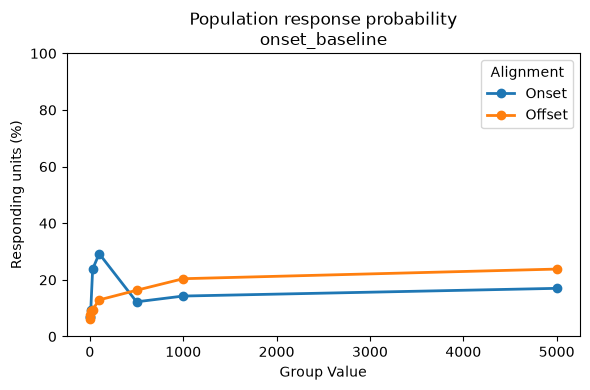

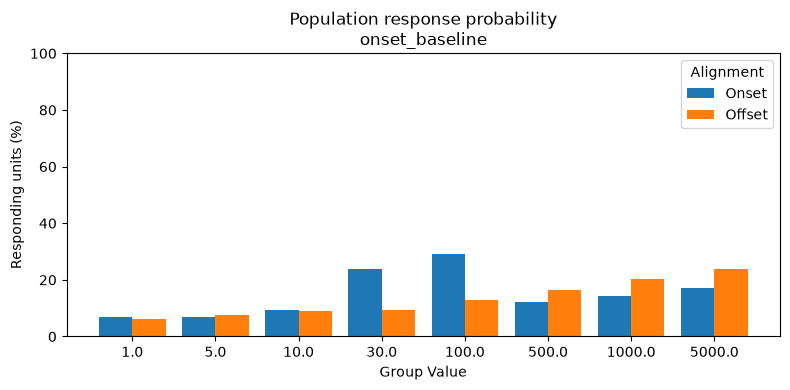

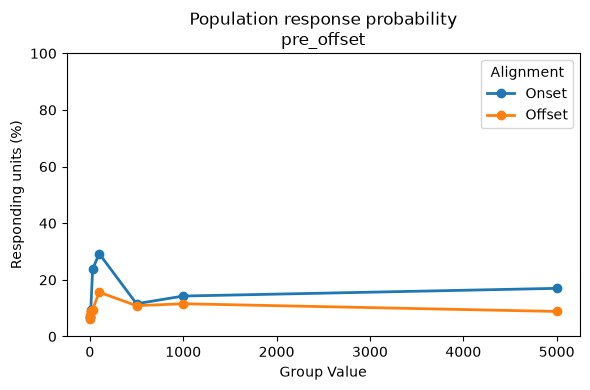

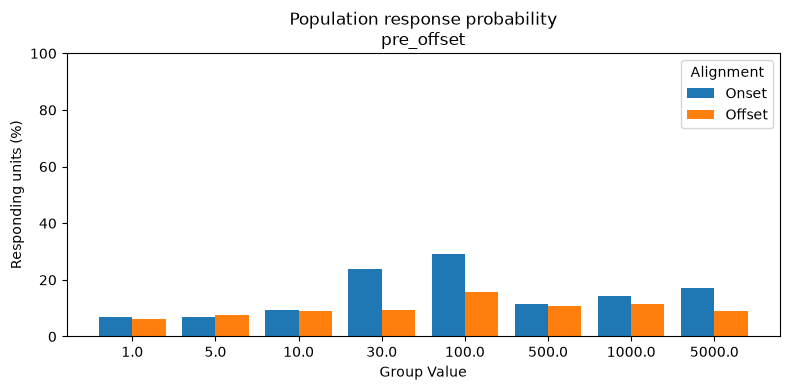

In [32]:
#38A
# ==========================================
# Population response probability
# ==========================================

"""
Summarize and visualize the fraction of responding
units for each stimulus condition.

Uses the filtered_summary generated in #38.
"""

# ==========================================
# Stimulus grouping
# ==========================================

stimulus_group = "group_value"

# ==========================================
# Population response summary
# ==========================================

def summarize_response_probability(
    dataframe,
):
    """
    Summarize the fraction of responding units
    for each stimulus condition.
    """

    summary = (

        dataframe

        .groupby(

            [

                "baseline_mode",
                "view",
                "event",
                stimulus_group,

            ],

            as_index=False,

        )

        .agg(

            n_units=(

                "unit_id",
                "count",

            ),

            n_responding=(

                "responding",
                "sum",

            ),

        )

    )

    summary["fraction_responding"] = (

        summary["n_responding"]

        / summary["n_units"]

    )

    summary["percent_responding"] = (

        100

        * summary["fraction_responding"]

    )

    return summary


# ==========================================
# Summarize
# ==========================================

response_probability_summary = (

    summarize_response_probability(

        filtered_summary

    )

)

display(response_probability_summary)

# ==========================================
# Plot response probability
# ==========================================

baseline_modes = [

    "onset_baseline",
    "pre_offset",

]

for baseline_mode in baseline_modes:

    baseline_df = (

        response_probability_summary[

            response_probability_summary["baseline_mode"]

            == baseline_mode

        ]

    )

    if baseline_df.empty:

        continue

    # --------------------------------------
    # Line plot
    # --------------------------------------

    fig, ax = plt.subplots(

        figsize=(6, 4)

    )

    for event in [

        "onset",
        "offset",

    ]:

        df = (

            baseline_df[

                baseline_df["event"]

                == event

            ]

            .sort_values(

                stimulus_group

            )

        )

        ax.plot(

            df[stimulus_group],

            df["percent_responding"],

            marker="o",

            linewidth=2,

            label=event.capitalize(),

        )

    ax.set_xlabel(

        stimulus_group.replace(

            "_",
            " ",

        ).title()

    )

    ax.set_ylabel(

        "Responding units (%)"

    )

    ax.set_title(

        f"Population response probability\n"

        f"{baseline_mode}"

    )

    ax.set_ylim(

        0,
        100,

    )

    ax.legend(

        title="Alignment",

    )

    plt.tight_layout()

    plt.show()

    # --------------------------------------
    # Bar plot
    # --------------------------------------

    fig, ax = plt.subplots(

        figsize=(8, 4)

    )

    events = [

        "onset",
        "offset",

    ]

    conditions = sorted(

        baseline_df[

            stimulus_group

        ].unique()

    )

    x = np.arange(

        len(conditions)

    )

    bar_width = 0.4

    for i, event in enumerate(events):

        df = (

            baseline_df[

                baseline_df["event"]

                == event

            ]

            .set_index(

                stimulus_group

            )

            .reindex(

                conditions

            )

        )

        ax.bar(

            x + (i - 0.5) * bar_width,

            df["percent_responding"],

            width=bar_width,

            label=event.capitalize(),

        )

    ax.set_xticks(x)

    ax.set_xticklabels(

        conditions

    )

    ax.set_xlabel(

        stimulus_group.replace(

            "_",
            " ",

        ).title()

    )

    ax.set_ylabel(

        "Responding units (%)"

    )

    ax.set_title(

        f"Population response probability\n"

        f"{baseline_mode}"

    )

    ax.set_ylim(

        0,
        100,

    )

    ax.legend(

        title="Alignment",

    )

    plt.tight_layout()

    plt.show()

#### 38B (Helper)

In [33]:
#38B
# ==========================================
# Build comparison labels
# ==========================================

"""
Create comparison labels that can be reused by all
population response analyses.

Uses the filtered_summary generated in #38.
"""

# ==========================================
# Build comparison labels
# ==========================================

response_comparison_df = build_comparison_labels(

    filtered_summary,

    response_comparison_groups,

    comparison_styles=response_comparison_styles,

)

# ==========================================
# Summary
# ==========================================

print()

print("Comparison groups")

print("-----------------")

response_summary = (

    response_comparison_df

    .groupby(

        "comparison_label",

    )

    .agg(

        n_sessions=("session_id", "nunique"),

        n_recordings=("rec_id", "nunique"),

        n_units=("unit_id", "nunique"),

    )

    .sort_index()

)

display(response_summary)


Comparison groups
-----------------


,n_sessions,n_recordings,n_units
comparison_label,,,
Inert implant | ChrimsonR+,1,1,18
Inert implant | ChrimsonR−,1,1,39
PV implant | ChrimsonR+,1,1,49
PV implant | ChrimsonR−,1,1,41


#### 38C New plots comparing experimental groups

,baseline_mode,view,event,comparison_label,group_value,n_units,n_responding,fraction_responding,percent_responding
0,onset_baseline,Laser,offset,Inert implant | ChrimsonR+,1.0,18,0,0.000000,0.000000
1,onset_baseline,Laser,offset,Inert implant | ChrimsonR+,5.0,18,0,0.000000,0.000000
2,onset_baseline,Laser,offset,Inert implant | ChrimsonR+,10.0,18,1,0.055556,5.555556
3,onset_baseline,Laser,offset,Inert implant | ChrimsonR+,30.0,18,2,0.111111,11.111111
4,onset_baseline,Laser,offset,Inert implant | ChrimsonR+,100.0,18,1,0.055556,5.555556
...,...,...,...,...,...,...,...,...,...
123,pre_offset,Laser,onset,PV implant | ChrimsonR−,30.0,41,9,0.219512,21.951220
124,pre_offset,Laser,onset,PV implant | ChrimsonR−,100.0,41,16,0.390244,39.024390
125,pre_offset,Laser,onset,PV implant | ChrimsonR−,500.0,41,0,0.000000,0.000000
126,pre_offset,Laser,onset,PV implant | ChrimsonR−,1000.0,41,0,0.000000,0.000000


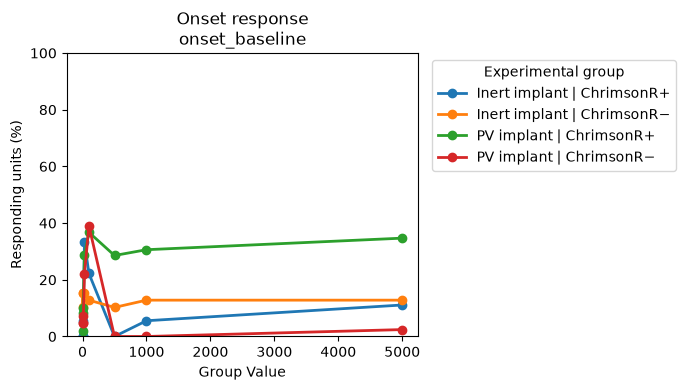

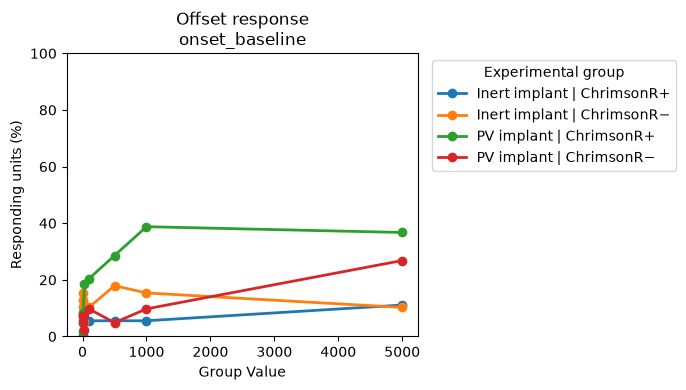

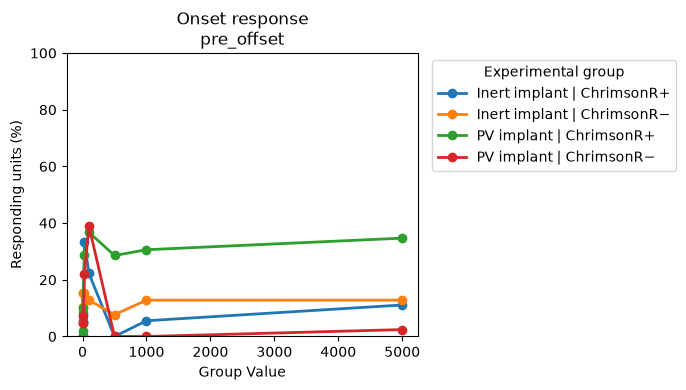

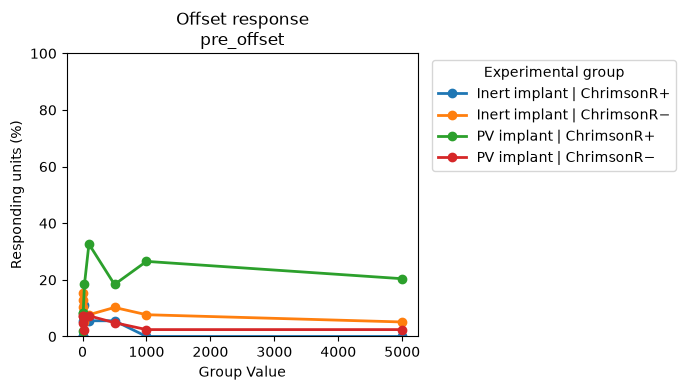

In [34]:
#38C
# ==========================================
# Population response comparison
# ==========================================

"""
Compare response probability between experimental groups.

Uses the comparison labels generated in #38B.

Each line represents one experimental group.
"""

# ==========================================
# Stimulus grouping
# ==========================================

stimulus_group = "group_value"

# ==========================================
# Summarize responses
# ==========================================

def summarize_response_comparison(
    dataframe,
):
    """
    Summarize response probability for each
    experimental group and stimulus condition.
    """

    summary = (

        dataframe

        .groupby(

            [

                "baseline_mode",
                "view",
                "event",
                "comparison_label",
                stimulus_group,

            ],

            as_index=False,

        )

        .agg(

            n_units=(

                "unit_id",
                "count",

            ),

            n_responding=(

                "responding",
                "sum",

            ),

        )

    )

    summary["fraction_responding"] = (

        summary["n_responding"]

        / summary["n_units"]

    )

    summary["percent_responding"] = (

        100

        * summary["fraction_responding"]

    )

    return summary


# ==========================================
# Summarize
# ==========================================

response_population_comparison = (

    summarize_response_comparison(

        response_comparison_df

    )

)

display(response_population_comparison)

# ==========================================
# Plot comparison
# ==========================================

baseline_modes = [

    "onset_baseline",
    "pre_offset",

]

events = [

    "onset",
    "offset",

]

for baseline_mode in baseline_modes:

    baseline_df = (

        response_population_comparison[

            response_population_comparison["baseline_mode"]

            == baseline_mode

        ]

    )

    if baseline_df.empty:

        continue

    for event in events:

        event_df = (

            baseline_df[

                baseline_df["event"]

                == event

            ]

        )

        if event_df.empty:

            continue

        fig, ax = plt.subplots(

            figsize=(7, 4)

        )

        # ----------------------------------
        # One line per experimental group
        # ----------------------------------

        for label, group_df in (

            event_df

            .groupby("comparison_label")

        ):

            group_df = (

                group_df

                .sort_values(

                    stimulus_group

                )

            )

            ax.plot(

                group_df[stimulus_group],

                group_df["percent_responding"],

                marker="o",

                linewidth=2,

                label=label,

            )

        ax.set_xlabel(

            stimulus_group.replace(

                "_",
                " ",

            ).title()

        )

        ax.set_ylabel(

            "Responding units (%)"

        )

        ax.set_ylim(

            0,
            100,

        )

        ax.set_title(

            f"{event.capitalize()} response\n"

            f"{baseline_mode}"

        )

        ax.legend(

            title="Experimental group",

            bbox_to_anchor=(1.02, 1),

            loc="upper left",

        )

        plt.tight_layout()

        plt.show()

#### What type of responses were observed?

,baseline_mode,view,event,group_value,n_units,n_excited,n_inhibited,n_mixed,n_none,n_responding
0,onset_baseline,Laser,offset,1.0,147,0,9,0,138,9
1,onset_baseline,Laser,offset,5.0,147,0,11,0,136,11
2,onset_baseline,Laser,offset,10.0,147,1,12,0,134,13
3,onset_baseline,Laser,offset,30.0,147,0,14,0,133,14
4,onset_baseline,Laser,offset,100.0,147,0,19,0,128,19
5,onset_baseline,Laser,offset,500.0,147,0,24,0,123,24
6,onset_baseline,Laser,offset,1000.0,147,1,29,0,117,30
7,onset_baseline,Laser,offset,5000.0,147,14,19,2,112,35
8,onset_baseline,Laser,onset,1.0,147,0,10,0,137,10
9,onset_baseline,Laser,onset,5.0,147,0,10,0,137,10


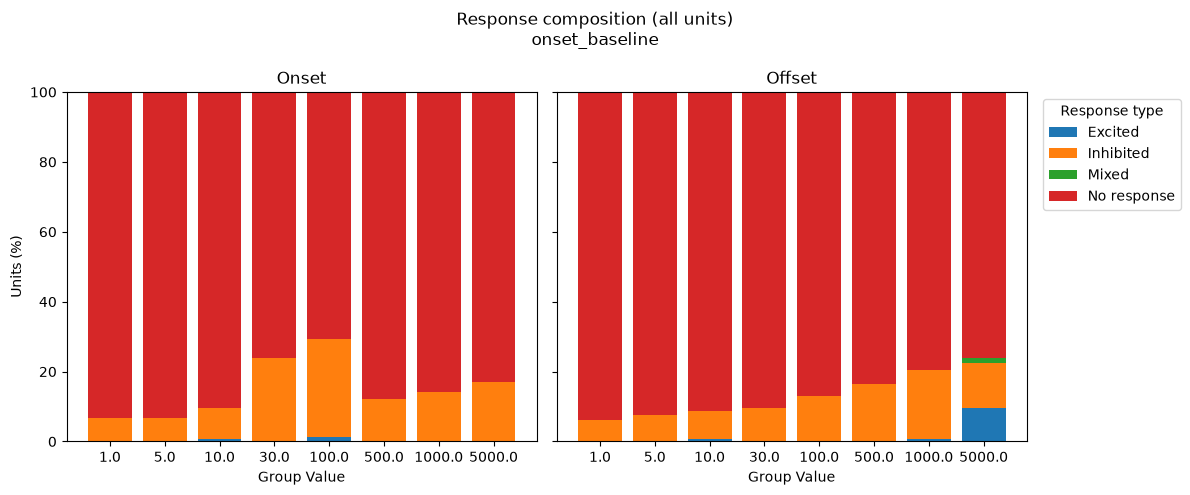

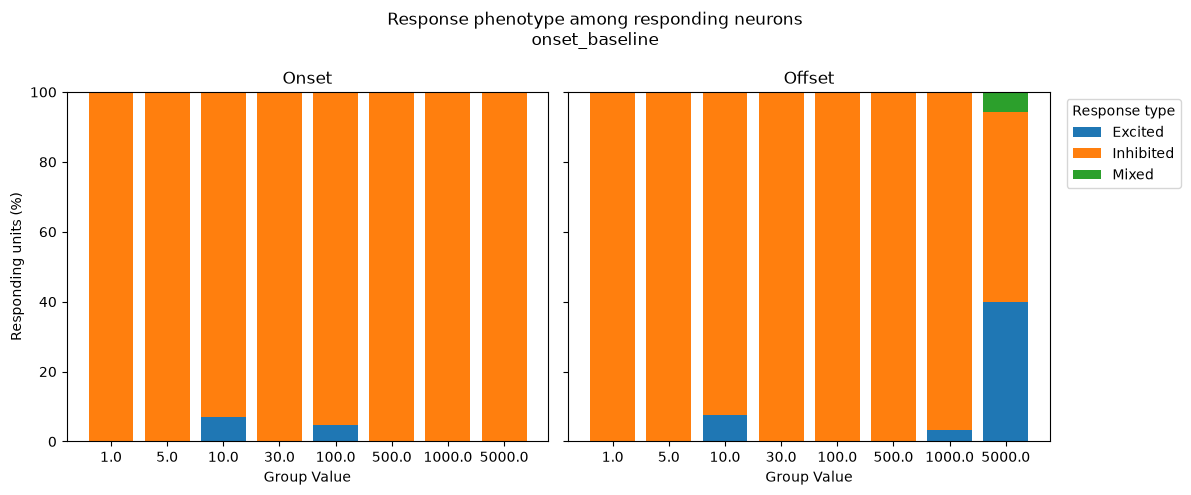

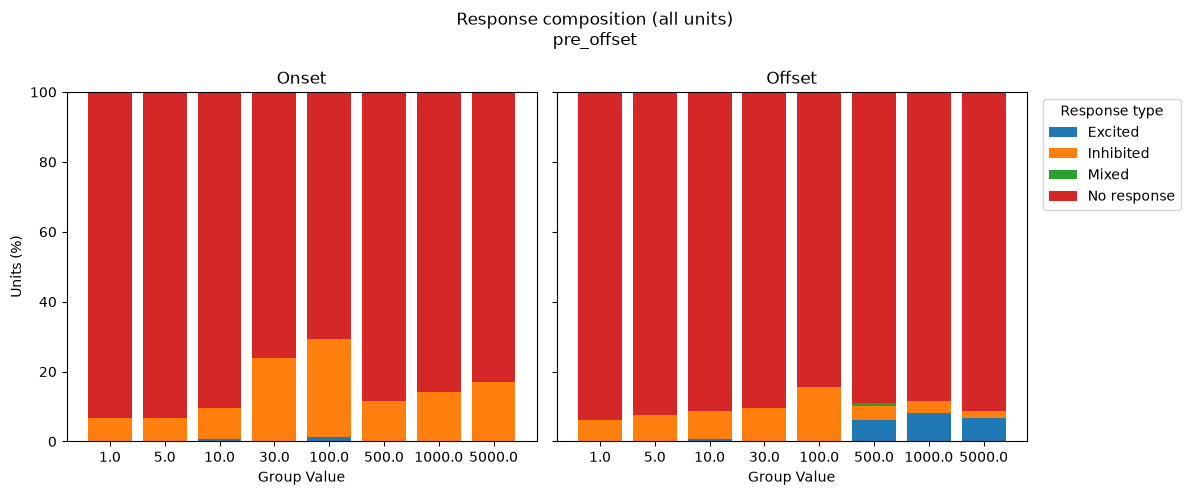

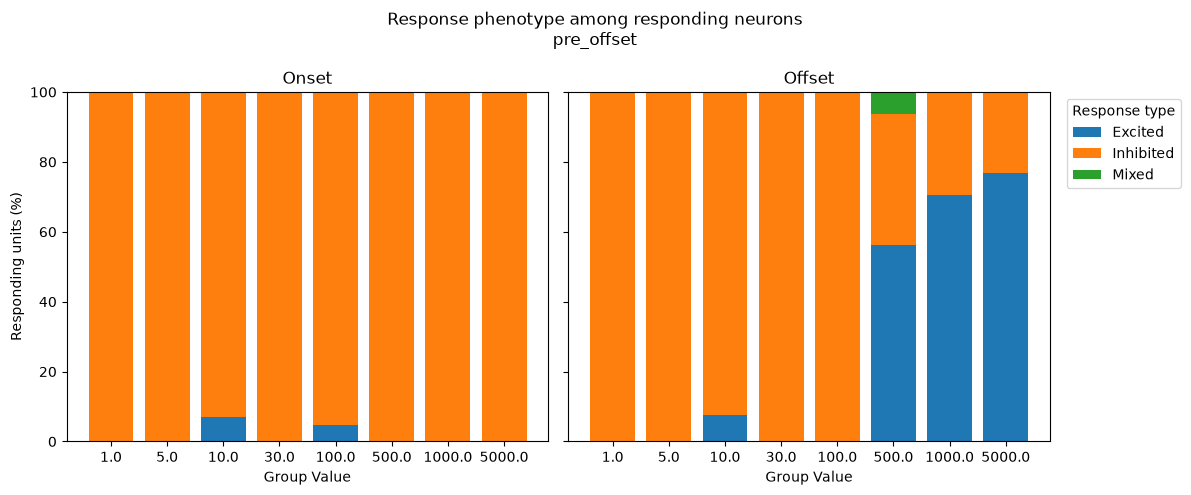

In [35]:
#39
# ==========================================
# Population response phenotype
# ==========================================

"""
Summarize the response phenotype as a function of the
selected stimulation parameter.

This cell uses the filtered dataset produced in #38A.

The following cell (#39A) will compare experimental
groups (implant, ChrimsonR, etc.).
"""

# ==========================================
# Summarize response types
# ==========================================

def summarize_response_types(
    dataframe,
):
    """
    Summarize neuronal response phenotypes for each
    stimulation condition.
    """

    summary = (

        dataframe

        .groupby(

            [

                "baseline_mode",
                "view",
                "event",
                stimulus_group,

            ],

            as_index=False,

        )

        .agg(

            n_units=(

                "unit_id",
                "count",

            ),

            n_excited=(

                "response_type",

                lambda x: (x == "excited").sum(),

            ),

            n_inhibited=(

                "response_type",

                lambda x: (x == "inhibited").sum(),

            ),

            n_mixed=(

                "response_type",

                lambda x: (x == "mixed").sum(),

            ),

            n_none=(

                "response_type",

                lambda x: (x == "none").sum(),

            ),

        )

    )

    summary["n_responding"] = (

        summary["n_excited"]

        + summary["n_inhibited"]

        + summary["n_mixed"]

    )

    return summary


# ==========================================
# Build summary table
# ==========================================

population_response_types = (

    summarize_response_types(

        filtered_summary

    )

)

display(population_response_types)

# ==========================================
# Plot settings
# ==========================================

baseline_modes = [

    "onset_baseline",
    "pre_offset",

]

events = [

    "onset",
    "offset",

]

response_categories_all = [

    ("n_excited", "Excited"),

    ("n_inhibited", "Inhibited"),

    ("n_mixed", "Mixed"),

    ("n_none", "No response"),

]

response_categories_responding = [

    ("n_excited", "Excited"),

    ("n_inhibited", "Inhibited"),

    ("n_mixed", "Mixed"),

]

# ==========================================
# Generate figures
# ==========================================

for baseline_mode in baseline_modes:

    baseline_df = (

        population_response_types[

            population_response_types["baseline_mode"]

            == baseline_mode

        ]

    )

    if baseline_df.empty:

        continue

    # ======================================
    # Figure 1
    # All recorded units
    # ======================================

    fig, axes = plt.subplots(

        1,

        2,

        figsize=(12, 5),

        sharey=True,

    )

    for ax, event in zip(axes, events):

        event_df = (

            baseline_df

            .query("event == @event")

            .sort_values(stimulus_group)

        )

        if event_df.empty:

            ax.set_visible(False)

            continue

        bottom = np.zeros(len(event_df))

        for column, label in response_categories_all:

            values = (

                100

                * event_df[column]

                / event_df["n_units"]

            )

            ax.bar(

                event_df[stimulus_group].astype(str),

                values,

                bottom=bottom,

                label=label,

            )

            bottom += values

        ax.set_title(

            event.capitalize()

        )

        ax.set_xlabel(

            stimulus_group

            .replace("_", " ")

            .title()

        )

        ax.set_ylim(

            0,

            100,

        )

    axes[0].set_ylabel(

        "Units (%)"

    )

    axes[1].legend(

        title="Response type",

        bbox_to_anchor=(1.02, 1),

    )

    plt.suptitle(

        "Response composition (all units)\n"

        f"{baseline_mode}"

    )

    plt.tight_layout()

    plt.show()

    # ======================================
    # Figure 2
    # Responding units only
    # ======================================

    fig, axes = plt.subplots(

        1,

        2,

        figsize=(12, 5),

        sharey=True,

    )

    for ax, event in zip(axes, events):

        event_df = (

            baseline_df

            .query("event == @event")

            .sort_values(stimulus_group)

            .copy()

        )

        if event_df.empty:

            ax.set_visible(False)

            continue

        responding = (

            event_df["n_responding"]

            .replace(0, np.nan)

        )

        bottom = np.zeros(len(event_df))

        for column, label in response_categories_responding:

            values = (

                100

                * event_df[column]

                / responding

            ).fillna(0)

            ax.bar(

                event_df[stimulus_group].astype(str),

                values,

                bottom=bottom,

                label=label,

            )

            bottom += values

        ax.set_title(

            event.capitalize()

        )

        ax.set_xlabel(

            stimulus_group

            .replace("_", " ")

            .title()

        )

        ax.set_ylim(

            0,

            100,

        )

    axes[0].set_ylabel(

        "Responding units (%)"

    )

    axes[1].legend(

        title="Response type",

        bbox_to_anchor=(1.02, 1),

    )

    plt.suptitle(

        "Response phenotype among responding neurons\n"

        f"{baseline_mode}"

    )

    plt.tight_layout()

    plt.show()

#### 39A Plotting: For a given stimulus condition, how do the different experimental groups compare?

In [36]:
# 39A
# ==========================================
# Build response phenotype comparison table
# ==========================================

"""
Summarize neuronal response phenotypes for each
experimental group and stimulation condition.

This table is reused by downstream comparison plots
and future statistical analyses.
"""

# ==========================================
# Summarize response phenotypes
# ==========================================

def summarize_response_phenotypes(
    dataframe,
):
    """
    Summarize neuronal response phenotypes for every
    combination of

        baseline
        event
        stimulus condition
        experimental group
    """

    summary = (

        dataframe

        .groupby(

            [

                "baseline_mode",
                "view",
                "event",
                stimulus_group,
                "comparison_label",

            ],

            as_index=False,

        )

        .agg(

            n_units=(

                "unit_id",
                "count",

            ),

            n_excited=(

                "response_type",

                lambda x: (x == "excited").sum(),

            ),

            n_inhibited=(

                "response_type",

                lambda x: (x == "inhibited").sum(),

            ),

            n_mixed=(

                "response_type",

                lambda x: (x == "mixed").sum(),

            ),

            n_none=(

                "response_type",

                lambda x: (x == "none").sum(),

            ),

        )

    )

    # --------------------------------------
    # Responding units
    # --------------------------------------

    summary["n_responding"] = (

        summary["n_excited"]

        + summary["n_inhibited"]

        + summary["n_mixed"]

    )

    # --------------------------------------
    # Percentages of all recorded units
    # --------------------------------------

    summary["pct_excited"] = (

        100

        * summary["n_excited"]

        / summary["n_units"]

    )

    summary["pct_inhibited"] = (

        100

        * summary["n_inhibited"]

        / summary["n_units"]

    )

    summary["pct_mixed"] = (

        100

        * summary["n_mixed"]

        / summary["n_units"]

    )

    summary["pct_none"] = (

        100

        * summary["n_none"]

        / summary["n_units"]

    )

    # --------------------------------------
    # Percentages among responding neurons
    # --------------------------------------

    responding = (

        summary["n_responding"]

        .replace(

            0,

            np.nan,

        )

    )

    summary["pct_excited_resp"] = (

        100

        * summary["n_excited"]

        / responding

    )

    summary["pct_inhibited_resp"] = (

        100

        * summary["n_inhibited"]

        / responding

    )

    summary["pct_mixed_resp"] = (

        100

        * summary["n_mixed"]

        / responding

    )

    return summary


# ==========================================
# Build comparison table
# ==========================================

response_phenotype_summary = (

    summarize_response_phenotypes(

        response_comparison_df

    )

)

# ==========================================
# Sort table
# ==========================================

response_phenotype_summary = (

    response_phenotype_summary

    .sort_values(

        [

            "baseline_mode",
            "event",
            stimulus_group,
            "comparison_label",

        ]

    )

    .reset_index(

        drop=True,

    )

)

# ==========================================
# Summary
# ==========================================

print()

print("Population response phenotype comparison")

print("---------------------------------------")

print(

    f"Rows : "

    f"{len(response_phenotype_summary)}"

)

print(

    f"Experimental groups : "

    f"{response_phenotype_summary['comparison_label'].nunique()}"

)

print(

    f"Stimulus conditions : "

    f"{response_phenotype_summary[stimulus_group].nunique()}"

)

display(

    response_phenotype_summary

)


Population response phenotype comparison
---------------------------------------
Rows : 128
Experimental groups : 4
Stimulus conditions : 8


,baseline_mode,view,event,group_value,comparison_label,n_units,n_excited,n_inhibited,n_mixed,n_none,n_responding,pct_excited,pct_inhibited,pct_mixed,pct_none,pct_excited_resp,pct_inhibited_resp,pct_mixed_resp
0,onset_baseline,Laser,offset,1.0,Inert implant | ChrimsonR+,18,0,0,0,18,0,0.0,0.000000,0.0,100.000000,NaN,NaN,NaN
1,onset_baseline,Laser,offset,1.0,Inert implant | ChrimsonR−,39,0,5,0,34,5,0.0,12.820513,0.0,87.179487,0.0,100.0,0.0
2,onset_baseline,Laser,offset,1.0,PV implant | ChrimsonR+,49,0,1,0,48,1,0.0,2.040816,0.0,97.959184,0.0,100.0,0.0
3,onset_baseline,Laser,offset,1.0,PV implant | ChrimsonR−,41,0,3,0,38,3,0.0,7.317073,0.0,92.682927,0.0,100.0,0.0
4,onset_baseline,Laser,offset,5.0,Inert implant | ChrimsonR+,18,0,0,0,18,0,0.0,0.000000,0.0,100.000000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,pre_offset,Laser,onset,1000.0,PV implant | ChrimsonR−,41,0,0,0,41,0,0.0,0.000000,0.0,100.000000,NaN,NaN,NaN
124,pre_offset,Laser,onset,5000.0,Inert implant | ChrimsonR+,18,0,2,0,16,2,0.0,11.111111,0.0,88.888889,0.0,100.0,0.0
125,pre_offset,Laser,onset,5000.0,Inert implant | ChrimsonR−,39,0,5,0,34,5,0.0,12.820513,0.0,87.179487,0.0,100.0,0.0
126,pre_offset,Laser,onset,5000.0,PV implant | ChrimsonR+,49,0,17,0,32,17,0.0,34.693878,0.0,65.306122,0.0,100.0,0.0


#### 39B

In [37]:
#39B
# ==========================================
# Prepare response phenotype plots
# ==========================================

"""
Create grouped stacked bar plots comparing response
phenotypes between experimental groups.

This cell prepares the plotting data.

The following cell (#39C) generates the figures.
"""

# ==========================================
# Plot settings
# ==========================================

baseline_modes = [

    "onset_baseline",
    "pre_offset",

]

events = [

    "onset",
    "offset",

]

response_categories_all = [

    ("pct_excited", "Excited"),
    ("pct_inhibited", "Inhibited"),
    ("pct_mixed", "Mixed"),
    ("pct_none", "No response"),

]

response_categories_responding = [

    ("pct_excited_resp", "Excited"),
    ("pct_inhibited_resp", "Inhibited"),
    ("pct_mixed_resp", "Mixed"),

]

# ==========================================
# Group ordering
# ==========================================

response_comparison_labels = [

    "PV implant | ChrimsonR+",

    "PV implant | ChrimsonR−",

    "Inert implant | ChrimsonR+",

    "Inert implant | ChrimsonR−",

]

response_stimulus_values = sorted(

    response_phenotype_summary[
        stimulus_group
    ].unique()

)

print("Experimental groups")

for label in response_comparison_labels:

    print(f"    {label}")

print()

print("Stimulus conditions")

for value in response_stimulus_values:

    print(f"    {value}")

# ==========================================
# Bar layout
# ==========================================

# ------------------------------------------
# X-axis layout
# ------------------------------------------

bar_width = 0.30

stimulus_spacing = 0.35

group_spacing = (
    len(response_stimulus_values) * stimulus_spacing
    + 0.9
)

group_centres = (
    np.arange(len(response_comparison_labels))
    * group_spacing
)

stimulus_offsets = (

    np.arange(len(response_stimulus_values))

    - (len(response_stimulus_values) - 1) / 2

) * stimulus_spacing

# ==========================================
# Colour map
# ==========================================

response_colours = {

    "Excited": "tab:blue",

    "Inhibited": "tab:orange",

    "Mixed": "tab:green",

    "No response": "tab:red",

}

# ==========================================
# Prepare plotting tables
# ==========================================

response_plot_data = {}

for baseline_mode in baseline_modes:

    baseline_df = (

        response_phenotype_summary[

            response_phenotype_summary[
                "baseline_mode"
            ]

            == baseline_mode

        ]

    )

    if baseline_df.empty:

        continue

    response_plot_data[baseline_mode] = {}

    for event in events:

        event_df = (

            baseline_df[

                baseline_df["event"]

                == event

            ]

        )

        if event_df.empty:

            continue

        response_plot_data[baseline_mode][event] = {}

        # ----------------------------------
        # Store one dataframe per stimulus
        # ----------------------------------

        for stimulus_value in response_stimulus_values:

            stimulus_df = (

                event_df[

                    event_df[stimulus_group]

                    == stimulus_value

                ]

                .set_index(

                    "comparison_label"

                )

                .reindex(

                    response_comparison_labels

                )

            )

            response_plot_data[

                baseline_mode

            ][

                event

            ][

                stimulus_value

            ] = stimulus_df

# ==========================================
# Summary
# ==========================================

print()

print("Prepared response phenotype plot data")

for baseline_mode, baseline_data in response_plot_data.items():

    print()

    print(baseline_mode)

    for event, event_data in baseline_data.items():

        print(

            f"    {event:<8}"

            f"{len(event_data)} stimulus condition(s)"

        )

Experimental groups
    PV implant | ChrimsonR+
    PV implant | ChrimsonR−
    Inert implant | ChrimsonR+
    Inert implant | ChrimsonR−

Stimulus conditions
    1.0
    5.0
    10.0
    30.0
    100.0
    500.0
    1000.0
    5000.0

Prepared response phenotype plot data

onset_baseline
    onset   8 stimulus condition(s)
    offset  8 stimulus condition(s)

pre_offset
    onset   8 stimulus condition(s)
    offset  8 stimulus condition(s)


#### 39C Plots

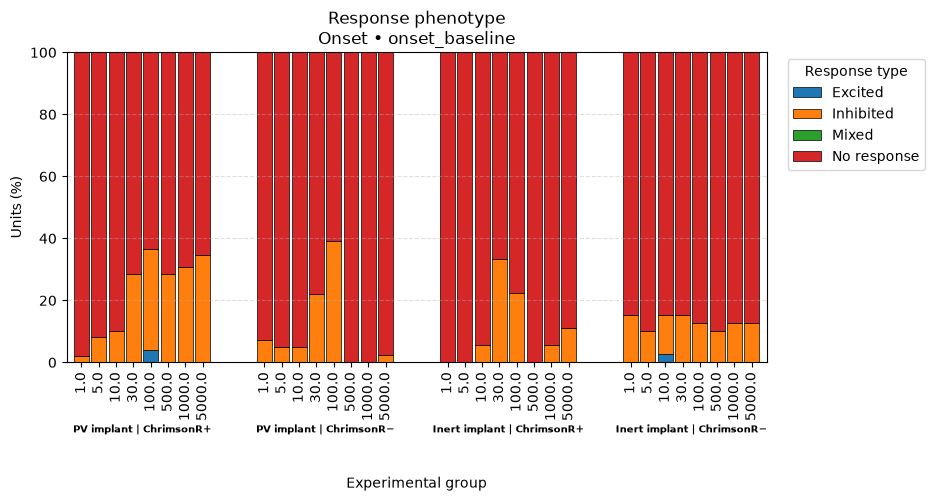

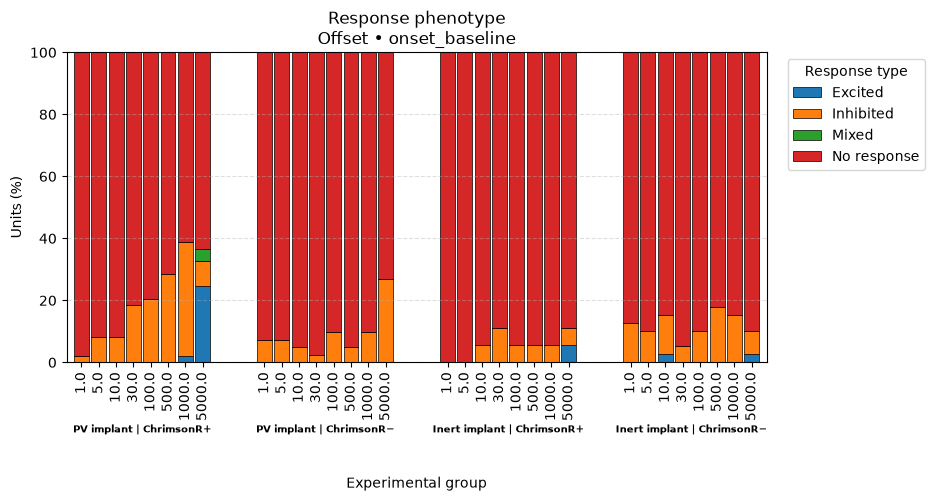

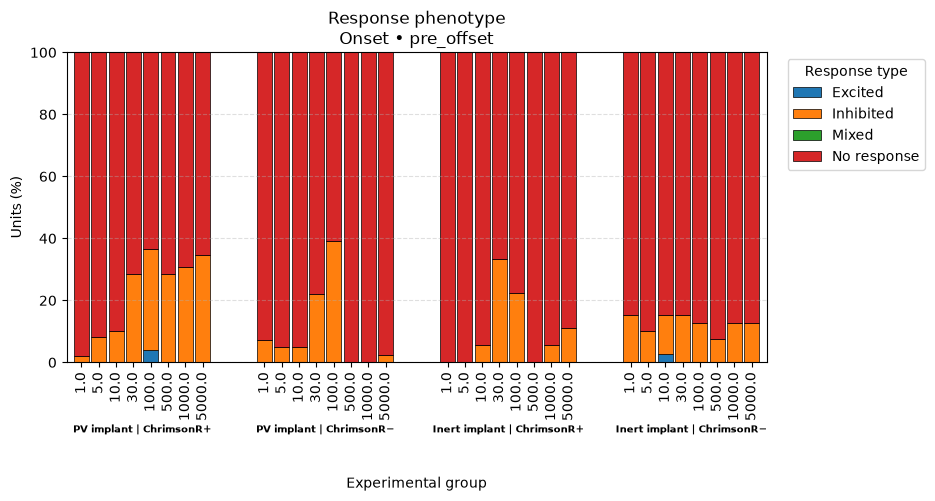

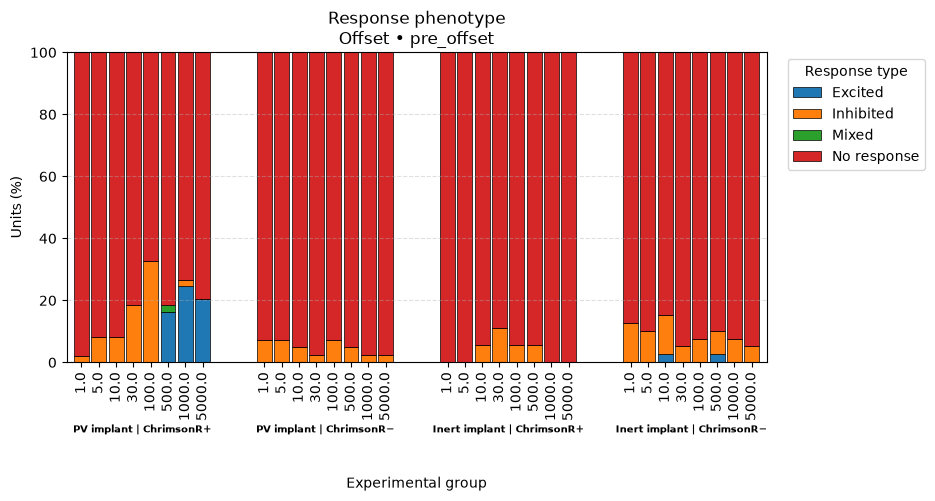

In [38]:
#39C
# ==========================================
# Plot response phenotypes
# ==========================================

for baseline_mode in baseline_modes:

    if baseline_mode not in response_plot_data:
        continue

    for event in events:

        if event not in response_plot_data[baseline_mode]:
            continue

        fig, ax = plt.subplots(
            figsize=(10, 5)
        )

        # ----------------------------------
        # Plot one bar per stimulus condition
        # within each comparison group
        # ----------------------------------

        for stimulus_index, stimulus_value in enumerate(response_stimulus_values):

            df = response_plot_data[
                baseline_mode
            ][
                event
            ][
                stimulus_value
            ]

            x = (
                group_centres
                + stimulus_offsets[stimulus_index]
            )

            bottom = np.zeros(
                len(response_comparison_labels)
            )

            # ------------------------------
            # Stack response categories
            # ------------------------------

            for column, label in response_categories_all:

                values = (
                    df[column]
                    .fillna(0)
                    .to_numpy()
                )

                ax.bar(

                    x,

                    values,

                    width=bar_width,

                    bottom=bottom,

                    color=response_colours[label],

                    edgecolor="black",

                    linewidth=0.5,

                    label=(
                        label
                        if stimulus_index == 0
                        else None
                    ),

                )

                bottom += values

        # ----------------------------------
        # Axis formatting
        # ----------------------------------

        # ----------------------------------
        # X-axis labels
        # ----------------------------------

        tick_positions = []

        tick_labels = []

        for centre in group_centres:

            for offset, stimulus in zip(
                stimulus_offsets,
                response_stimulus_values,
            ):

                tick_positions.append(
                    centre + offset
                )

                tick_labels.append(
                    str(stimulus)
                )

        ax.set_xticks(
            tick_positions
        )

        ax.set_xticklabels(
            tick_labels,
            rotation=90,
        )

        # ----------------------------------
        # Experimental group labels
        # ----------------------------------

        for centre, label in zip(

            group_centres,

            response_comparison_labels,

        ):

            ax.text(

                centre,

                -0.20,

                label,

                transform=ax.get_xaxis_transform(),

                ha="center",

                va="top",

                fontsize=7,

                fontweight="bold",

            )

        # ----------------------------------
        # Axis formatting
        # ----------------------------------

        ax.set_xlim(

            tick_positions[0] - bar_width,

            tick_positions[-1] + bar_width,

        )

        ax.set_ylim(0, 100)

        ax.set_ylabel("Units (%)")

        ax.set_xlabel(

            "Experimental group",

            labelpad=40,

        )

        ax.set_title(

            f"Response phenotype\n"

            f"{event.capitalize()} • {baseline_mode}"

        )

        # ----------------------------------
        # Legend
        # ----------------------------------

        handles, labels = ax.get_legend_handles_labels()

        unique = dict(zip(labels, handles))

        ax.legend(

            unique.values(),

            unique.keys(),

            title="Response type",

            bbox_to_anchor=(1.02, 1),

            loc="upper left",

        )

        # ----------------------------------
        # Grid
        # ----------------------------------

        ax.grid(

            axis="y",

            linestyle="--",

            alpha=0.4,

        )

        plt.subplots_adjust(

            left=0.10,

            right=0.80,

            top=0.90,

            bottom=0.28,

        )

        plt.show()

In [39]:
#40
population_summary["response_type"].value_counts(dropna=False)

response_type
none         21089
inhibited     4021
excited        461
mixed           33
Name: count, dtype: int64

In [40]:
#41
responding_units = (
    population_summary
    .loc[population_summary["responding"], "unit_id"]
    .unique()
)

print(responding_units)

<StringArray>
['uid_20260601_000', 'uid_20260601_001', 'uid_20260601_005',
 'uid_20260601_008', 'uid_20260601_009', 'uid_20260601_010',
 'uid_20260601_015', 'uid_20260601_019', 'uid_20260601_021',
 'uid_20260601_022',
 ...
 'uid_20260604_004', 'uid_20260604_006', 'uid_20260604_020',
 'uid_20260604_030', 'uid_20260604_036', 'uid_20260604_038',
 'uid_20260604_039', 'uid_20260604_035', 'uid_20260604_003',
 'uid_20260604_032']
Length: 108, dtype: str


### PSTH

#### Laser Duration PSTH (42)

In [56]:
#42
# ==========================================
# Population PSTH configuration
# ==========================================

"""
Configure and select recordings for the population PSTH analysis.

This cell only performs data selection.

The following cells will

    #43  Reload aligned spike trains

    #44  Compute PSTHs

    #45  Plot PSTHs
"""

# ==========================================
# User settings
# ==========================================

protocol = "longstim"
# "pow"
# "dur"
# "freq"
# "del"
# "del2"
# "longstim"
# None (= all)

stim_mode = "P"
# "P"
# "L"
# "B"
# None (= all)

laser_mode = "N"
# "N"
# "LC"
# None (= all)

view = "Polychrome"
# "Laser"
# "Polychrome"

include_units = "unit_responding"
# "responding"
# "unit_responding"
# "all"

baseline_mode = "onset_baseline"
# "onset_baseline"
# "pre_offset"

event = "both"
# "onset"
# "offset"
# "both"

psth_alignment = "both"
# "onset"
# "offset"
# "both"

# ==========================================
# PSTH parameters
# ==========================================

analysis_window = (-1000, 1000)

bin_width = 20      # ms

bin_step = 5        # ms

# ==========================================
# Experimental grouping
# ==========================================

psth_comparison_groups = [

    "implant","chrimsonr"

]

# ==========================================
# Comparison styles
# ==========================================

psth_comparison_styles = build_comparison_styles(

    psth_comparison_groups,

)

# ==========================================
# Filter population summary
# ==========================================

psth_filtered_summary = filter_population_summary(

    population_summary,

    protocol=protocol,

    stim_mode=stim_mode,

    laser_mode=laser_mode,

    view=view,

    baseline_mode=baseline_mode,

    event=event,

    include_units=include_units,

)

psth_comparison_df = build_comparison_labels(

    filtered_summary,

    psth_comparison_groups,

    comparison_styles=psth_comparison_styles,

)

# ==========================================
# Verify sessions
# ==========================================

print()

print("Sessions in psth_comparison_df")

display(

    psth_comparison_df[
        [
            "session_id",
            "rec_id",
        ]
    ]

    .drop_duplicates()

    .sort_values(
        [
            "session_id",
            "rec_id",
        ]
    )

)

print()

print("Sessions in all_data_io")

for key in sorted(all_data_io):

    print(f"    {key}")

# ==========================================
# Summary
# ==========================================

if psth_comparison_df.empty:

    print(
        "\nNo recordings match the selected filters."
    )

else:

    print(
        "Population PSTH selection"
    )

    print(
        "-------------------------"
    )

    print(
        f"Session(s)   : "
        f"{psth_comparison_df['session_id'].nunique()}"
    )

    print(
        f"Recording(s) : "
        f"{psth_comparison_df['rec_id'].nunique()}"
    )

    print(
        f"Unit(s)      : "
        f"{psth_comparison_df['unit_id'].nunique()}"
    )

    print(
        f"Conditions   : "
        f"{psth_comparison_df['group_value'].nunique()}"
    )

    print(
        f"View         : {view}"
    )

    print(
        f"Baseline     : {baseline_mode}"
    )

    print(
        f"Event        : {event}"
    )

    print(
        f"Units        : {include_units}"
    )

    print(
        f"Comparison  : "
        f"{psth_comparison_groups}"
    )

    display(

        psth_comparison_df[
            [
                "session_id",
                "rec_id",
                "group_value",
                "comparison_label",
                "event",
                "unit_id",
            ]
        ]
        .sort_values(

            [
                "session_id",
                "rec_id",
                "comparison_label",
                "group_value",
                "unit_id",

            ]

        )
        .head(20)

    )


Sessions in psth_comparison_df


,session_id,rec_id
3920,20260601_eye1_1st,07_N_L_dur
10468,20260603_eye2_2nd,06_N_L_dur
14616,20260604_eye1_2nd,05_N_L_dur
21236,20260604_eye2_2nd,05_N_L_dur



Sessions in all_data_io
    20260601_eye1_1st
    20260603_eye2_2nd
    20260604_eye1_2nd
    20260604_eye2_2nd
Population PSTH selection
-------------------------
Session(s)   : 4
Recording(s) : 3
Unit(s)      : 108
Conditions   : 8
View         : Polychrome
Baseline     : onset_baseline
Event        : both
Units        : unit_responding
Comparison  : ['implant', 'chrimsonr']


,session_id,rec_id,group_value,comparison_label,event,unit_id
3924,20260601_eye1_1st,07_N_L_dur,1.0,PV implant | ChrimsonR+,onset,uid_20260601_000
3925,20260601_eye1_1st,07_N_L_dur,1.0,PV implant | ChrimsonR+,offset,uid_20260601_000
3940,20260601_eye1_1st,07_N_L_dur,1.0,PV implant | ChrimsonR+,onset,uid_20260601_000
3941,20260601_eye1_1st,07_N_L_dur,1.0,PV implant | ChrimsonR+,offset,uid_20260601_000
3956,20260601_eye1_1st,07_N_L_dur,1.0,PV implant | ChrimsonR+,onset,uid_20260601_001
3957,20260601_eye1_1st,07_N_L_dur,1.0,PV implant | ChrimsonR+,offset,uid_20260601_001
3972,20260601_eye1_1st,07_N_L_dur,1.0,PV implant | ChrimsonR+,onset,uid_20260601_001
3973,20260601_eye1_1st,07_N_L_dur,1.0,PV implant | ChrimsonR+,offset,uid_20260601_001
3988,20260601_eye1_1st,07_N_L_dur,1.0,PV implant | ChrimsonR+,onset,uid_20260601_002
3989,20260601_eye1_1st,07_N_L_dur,1.0,PV implant | ChrimsonR+,offset,uid_20260601_002


In [57]:
# DIAGNOSTIC
display(

    population_summary[
        population_summary["rec_id"] == "05_N_L_dur"
    ][
        [
            "session_id",
            "rec_id",
            "unit_id",
        ]
    ]

    .drop_duplicates()

    .sort_values(
        [
            "session_id",
            "unit_id",
        ]
    )

)

,session_id,rec_id,unit_id
14616,20260604_eye1_2nd,05_N_L_dur,uid_20260604_000
14648,20260604_eye1_2nd,05_N_L_dur,uid_20260604_001
14680,20260604_eye1_2nd,05_N_L_dur,uid_20260604_002
14712,20260604_eye1_2nd,05_N_L_dur,uid_20260604_003
14744,20260604_eye1_2nd,05_N_L_dur,uid_20260604_004
...,...,...,...
22324,20260604_eye2_2nd,05_N_L_dur,uid_20260604_034
22356,20260604_eye2_2nd,05_N_L_dur,uid_20260604_035
22388,20260604_eye2_2nd,05_N_L_dur,uid_20260604_036
22420,20260604_eye2_2nd,05_N_L_dur,uid_20260604_037


#### Build population spike database (43)

In [58]:
#43
# ==========================================
# Build population spike database
# ==========================================

"""
Reload aligned spike trains for the selected units.

Each row corresponds to one trial from one stimulation
condition.

The resulting DataFrame is the input for all subsequent
population PSTH analyses.
"""

psth_rows = []

# ==========================================
# Validate loaded sessions
# ==========================================

missing_sessions = sorted(

    set(psth_comparison_df["session_id"].unique())

    - set(all_data_io.keys())

)

if missing_sessions:

    raise RuntimeError(

        "The following sessions are missing from all_data_io:\n\n"

        + "\n".join(missing_sessions)

        + "\n\nPlease rerun #34 to reload the selected sessions."

    )

# ------------------------------------------
# Loop over sessions
# ------------------------------------------

for session_id in sorted(psth_comparison_df["session_id"].unique()):

    print(f"Session : {session_id}")

    print()

    print("Available sessions")

    for key in sorted(all_data_io):

        print(f"    {key}")

    session_data = all_data_io[session_id]

    session_summary = psth_comparison_df[
        psth_comparison_df["session_id"] == session_id
    ]

    # --------------------------------------
    # Loop over recordings
    # --------------------------------------

    for rec_id in sorted(session_summary["rec_id"].unique()):

        print(f"Loading {rec_id}")

        recording_protocol = rec_id.split("_")[3]
        recording_stim_mode = rec_id.split("_")[2]

        (
            burst_df,
            analysis_views,
            group_label,
        ) = prepare_recording_analysis(

            data_io=session_data,

            rec_id=rec_id,

            protocol=recording_protocol,

            stim_mode=recording_stim_mode,

            pchr_columns=pchr_columns,

            laser_columns=laser_columns,

        )

        # --------------------------------------
        # Units belonging to this recording
        # --------------------------------------

        recording_summary = session_summary[
            session_summary["rec_id"] == rec_id
        ]

        unit_ids = sorted(
            recording_summary["unit_id"].unique()
        )

        # --------------------------------------
        # Reload aligned spikes
        # --------------------------------------

        for unit_id in unit_ids:

            all_spiketimes = extract_spikes(

                session_data,
                rec_id,
                unit_id,
                verbose=False,

            )

            unit_summary = recording_summary[
                recording_summary["unit_id"] == unit_id
            ]

            # ----------------------------------
            # Loop over selected conditions
            # ----------------------------------

            for _, row in unit_summary.iterrows():

                train_id = row["train_id"]

                event_name = row["event"]

                group_value = row["group_value"]

                metadata = row["metadata"]

                comparison_label = row["comparison_label"]

                comparison_key = row["comparison_key"]

                # ----------------------------------
                # Analysis view
                # ----------------------------------

                current_view = next(

                    v

                    for v in analysis_views

                    if v["name"] == view

                )

                # ----------------------------------
                # Stimulus windows
                # ----------------------------------

                alignment, stim_windows = (

                    current_view["stim_windows"](metadata)

                )

                # ----------------------------------
                # Unique stimulation pattern
                # ----------------------------------

                pattern_key = tuple(

                    (

                        int(round(start)),

                        int(round(stop)),

                        label,

                    )

                    for start, stop, label in stim_windows

                )

                view_spikes = all_spiketimes[view]

                if train_id not in view_spikes:

                    continue

                trial_spikes = view_spikes[train_id]

                # ----------------------------------
                # One row per trial
                # ----------------------------------

                for trial_index, spiketrain in enumerate(trial_spikes):

                    # ----------------------------------
                    # Store both alignments
                    # ----------------------------------

                    onset_spikes = spiketrain

                    offset_time = next(

                        stop

                        for _, stop, label in stim_windows

                        if label == view

                    )

                    offset_spikes = spiketrain - offset_time

                    psth_rows.append(

                        {

                            # ----------------------------------
                            # Recording identifiers
                            # ----------------------------------

                            "session_id": session_id,

                            "rec_id": rec_id,

                            "unit_id": unit_id,

                            # ----------------------------------
                            # Experimental metadata
                            # ----------------------------------

                            "implant": row["implant"],

                            "chrimsonr": row["chrimsonr"],

                            "comparison_key": comparison_key,

                            "comparison_label": comparison_label,

                            "baseline_mode": row["baseline_mode"],

                            "tags": row["tags"],

                            # ----------------------------------
                            # Stimulation metadata
                            # ----------------------------------

                            "view": view,

                            "event": event_name,

                            "group_value": group_value,

                            "train_id": train_id,

                            "trial": trial_index,

                            "metadata": metadata,

                            # ----------------------------------
                            # Spike data
                            # ----------------------------------

                            "stim_windows": stim_windows,

                            "pattern_key": pattern_key,

                            "onset_spikes": onset_spikes,

                            "offset_spikes": offset_spikes,

                        }

                    )

# ==========================================
# Build DataFrame
# ==========================================

psth_df = pd.DataFrame(psth_rows)

# ==========================================
# Summary
# ==========================================

print()

print("Population spike database")
print("-------------------------")

print(f"Trials      : {len(psth_df)}")

print(f"Units       : {psth_df['unit_id'].nunique()}")

print(f"Recordings  : {psth_df['rec_id'].nunique()}")

print(f"Conditions  : {sorted(psth_df['group_value'].unique())}")

display(
    psth_df.head()
)

Session : 20260601_eye1_1st

Available sessions
    20260601_eye1_1st
    20260603_eye2_2nd
    20260604_eye1_2nd
    20260604_eye2_2nd
Loading 07_N_L_dur


StopIteration: 

#### PSTH Helper (44)

In [ ]:
#44
# ==========================================
# Compute population PSTHs
# ==========================================

"""
Compute one population PSTH for each stimulus condition.

Workflow

    trials
        ↓
    mean within unit
        ↓
    mean across units
"""

# ==========================================
# Experimental grouping
# ==========================================

psth_comparison_groups = [
    "implant",
    "chrimsonr",
]

# ------------------------------------------
# Sliding analysis windows
# ------------------------------------------

bin_starts = np.arange(

    analysis_window[0],

    analysis_window[1] - bin_width + bin_step,

    bin_step,

)

bin_centres = (

    bin_starts

    + bin_width / 2

)

bin_ends = bin_starts + bin_width

# --------------------------------------
# Select spike alignment
# --------------------------------------

if psth_alignment == "onset":

    spike_columns = ["onset_spikes"]

elif psth_alignment == "offset":

    spike_columns = ["offset_spikes"]

elif psth_alignment == "both":

    spike_columns = [

        "onset_spikes",

        "offset_spikes",

    ]

else:

    raise ValueError(
        f"Unknown psth_alignment: {psth_alignment}"
    )

# ==========================================
# Pre-group conditions
# ==========================================

grouped = psth_df.groupby(

    [
        "comparison_label",
        "group_value",
        "pattern_key",
    ]

)

condition_groups = {

    key: value

    for key, value in grouped

}

# ==========================================
# Compute PSTHs
# ==========================================

population_psth = {}

condition_keys = list(

    psth_df[
        [
            "comparison_label",
            "group_value",
            "pattern_key",
        ]
    ]

    .drop_duplicates()

    .itertuples(index=False, name=None)

)

for spike_column in spike_columns:

    alignment_name = spike_column.replace(
        "_spikes",
        "",
    )

    for comparison_label, group_value, pattern_key in condition_keys:

        print(

            f"{alignment_name:>6} | "

            f"{comparison_label:<30} | "

            f"{group_value:<8} | "

            f"pattern {hash(pattern_key) % 1000}"

        )

        condition_df = condition_groups[
            (
                comparison_label,
                group_value,
                pattern_key,
            )
        ]

        # --------------------------------------
        # One PSTH per unit
        # --------------------------------------

        unit_rates = []

        unit_groups = condition_df.groupby(

            "unit_id",

            sort=True,

        )

        for unit_id, unit_df in unit_groups:

            trial_rates = []

            for spiketrain in unit_df[spike_column]:

                spiketrain = np.asarray(spiketrain)

                counts = (

                    (

                        (spiketrain[:, None] >= bin_starts)

                        &

                        (spiketrain[:, None] < bin_ends)

                    )

                    .sum(axis=0)

                    * 1000

                    / bin_width

                )

                trial_rates.append(counts)

            if len(trial_rates) == 0:

                continue

            trial_rates = np.asarray(trial_rates)

            # Mean PSTH for this unit

            unit_rates.append(

                trial_rates.mean(axis=0)

            )

        if len(unit_rates) == 0:

            continue

        unit_rates = np.asarray(unit_rates)

        # --------------------------------------
        # Store population statistics
        # --------------------------------------

        metadata = (

            condition_df.iloc[0]["metadata"]

        )

        stim_windows = (

            condition_df.iloc[0]["stim_windows"]

        )

        comparison_metadata = {

            column: condition_df.iloc[0][column]

            for column in psth_comparison_groups

        }

        population_psth[
            (
                alignment_name,
                comparison_label,
                group_value,
                pattern_key,
            )
        ] = {

            "group_value": group_value,

            "pattern_key": pattern_key,

            "stim_windows": stim_windows,

            "alignment": alignment_name,

            "comparison_label": comparison_label,

            "comparison_metadata": comparison_metadata,

            "metadata": metadata,

            "time": bin_centres,

            "mean": unit_rates.mean(axis=0),

            "sem": (

                unit_rates.std(

                    axis=0,

                    ddof=1,

                )

                /

                np.sqrt(

                    unit_rates.shape[0]

                )

            ),

            "unit_rates": unit_rates,

            "n_units": unit_rates.shape[0],

            "n_trials": len(condition_df),

        }

# ==========================================
# Summary
# ==========================================

print()

print("Population PSTHs")
print("----------------")

for key in sorted(population_psth):

    psth = population_psth[key]

    print(

        f"{psth['alignment']:>6} | "

        f"{psth['comparison_label']:<30} | "

        f"{psth['group_value']:<8} | "

        f"{psth['n_units']:>3} units"

    )

 onset | PV implant | ChrimsonR+        | 1000.0   | pattern 843
 onset | PV implant | ChrimsonR+        | 500.0    | pattern 842
 onset | PV implant | ChrimsonR+        | 1.0      | pattern 739
 onset | PV implant | ChrimsonR+        | 100.0    | pattern 468
 onset | PV implant | ChrimsonR+        | 5.0      | pattern 321
 onset | PV implant | ChrimsonR+        | 5000.0   | pattern 808
 onset | PV implant | ChrimsonR+        | 30.0     | pattern 602
 onset | PV implant | ChrimsonR+        | 10.0     | pattern 640
 onset | Inert implant | ChrimsonR+     | 5.0      | pattern 321
 onset | Inert implant | ChrimsonR+     | 10.0     | pattern 640
 onset | Inert implant | ChrimsonR+     | 1.0      | pattern 739
 onset | Inert implant | ChrimsonR+     | 5000.0   | pattern 808
 onset | Inert implant | ChrimsonR+     | 30.0     | pattern 602
 onset | Inert implant | ChrimsonR+     | 500.0    | pattern 842
 onset | Inert implant | ChrimsonR+     | 1000.0   | pattern 843
 onset | Inert implant | 

#### PSTH Plot (45)

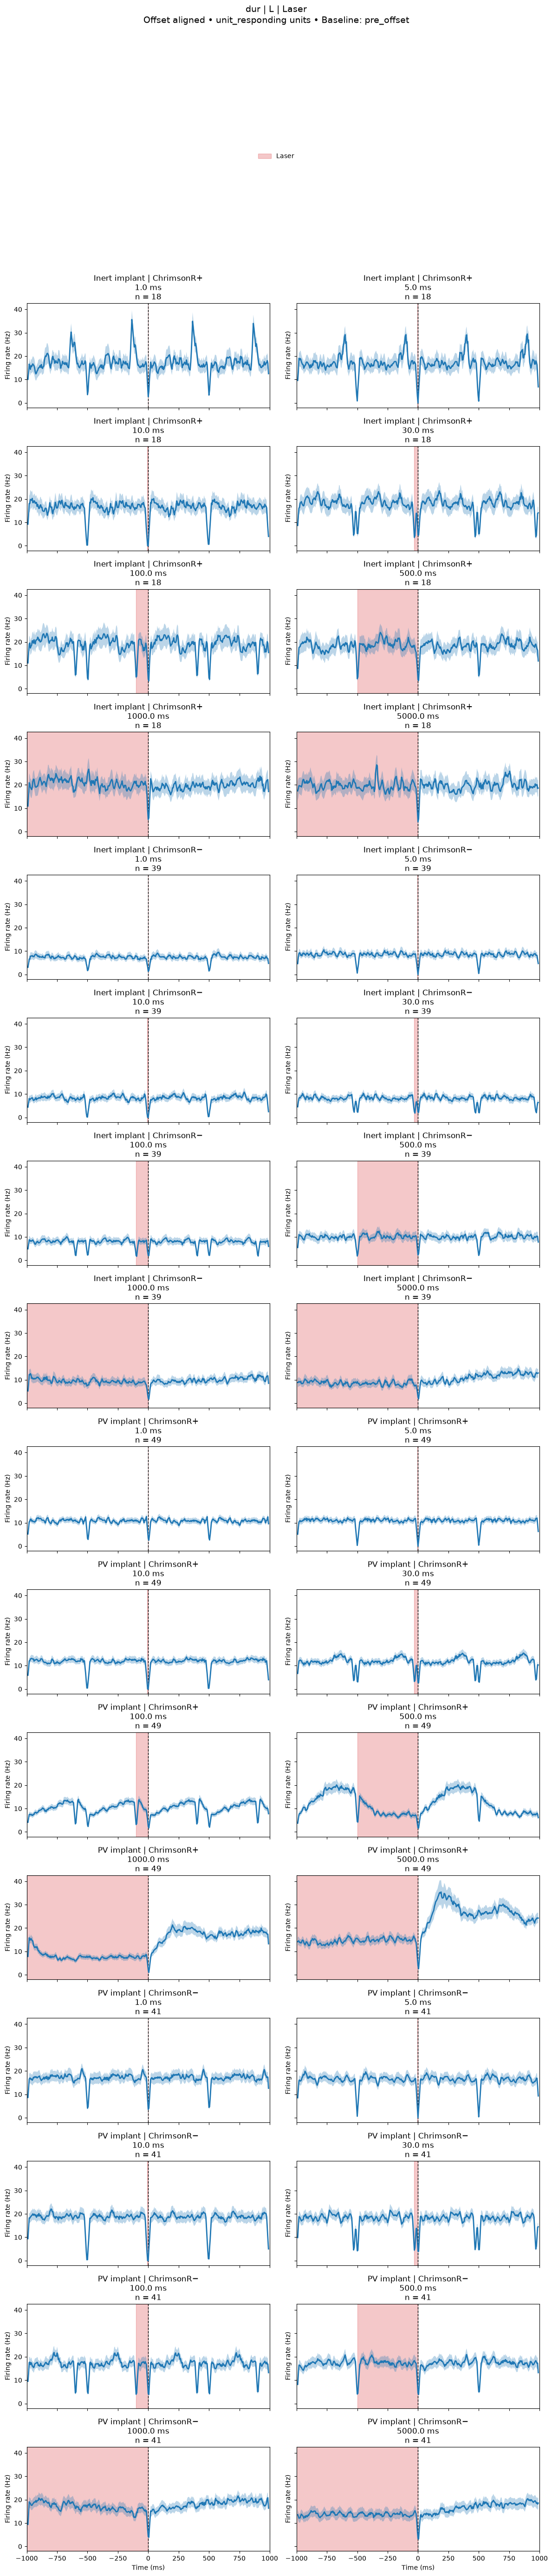

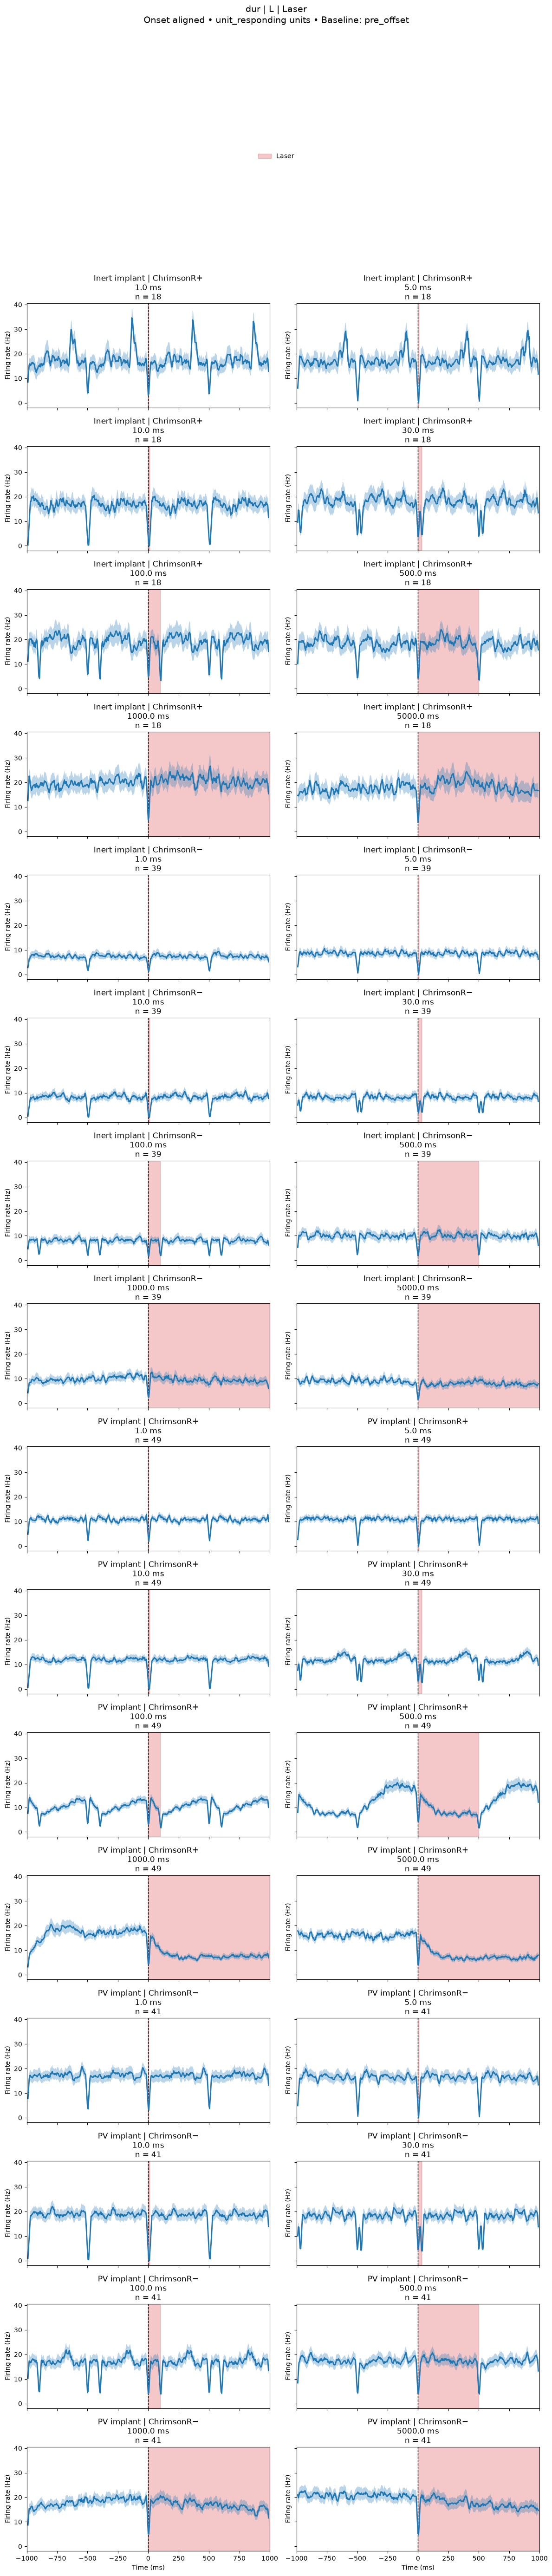

In [ ]:
#45
# ==========================================
# Plot population PSTHs
# ==========================================

if len(population_psth) == 0:

    print("No PSTHs available.")

else:

    alignment_groups = {}

    for key, psth in population_psth.items():

        alignment_groups.setdefault(
            psth["alignment"],
            []
        ).append(key)

    for alignment_name in sorted(alignment_groups):

        conditions = sorted(alignment_groups[alignment_name])

        n_conditions = len(conditions)

        n_cols = 2

        n_rows = int(np.ceil(n_conditions / n_cols))

        fig, axes = plt.subplots(

            n_rows,

            n_cols,

            figsize=(12, 3.5 * n_rows),

            sharex=True,

            sharey=True,

        )

        axes = np.atleast_1d(axes).ravel()

        legend_added = {

            "Laser": False,

            "Polychrome": False,

        }

        # ======================================
        # Plot each PSTH
        # ======================================

        for ax, condition_key in zip(axes, conditions):

            psth = population_psth[condition_key]

            group_value = psth["group_value"]

            stim_windows = psth["stim_windows"]

            time = psth["time"]

            mean = psth["mean"]

            sem = psth["sem"]

            # ----------------------------------
            # Shift windows into display coordinates
            # ----------------------------------

            if alignment_name == "offset":

                reference = next(

                    stop

                    for _, stop, label in stim_windows

                    if label == view

                )

            else:

                reference = 0

            display_windows = []

            for start, stop, label in stim_windows:

                start -= reference
                stop -= reference

                display_windows.append(
                    (start, stop, label)
                )

                colour = (
                    "tab:red"
                    if label == "Laser"
                    else "tab:blue"
                )

                ax.axvspan(

                    start,

                    stop,

                    color=colour,

                    alpha=0.25,

                    zorder=0,

                    label=(
                        label
                        if not legend_added[label]
                        else None
                    ),

                )

                legend_added[label] = True

            # ----------------------------------
            # PSTH
            # ----------------------------------

            ax.axvline(

                0,

                color="black",

                linestyle="--",

                linewidth=1,

            )

            ax.plot(

                time,

                mean,

                linewidth=2,

            )

            ax.fill_between(

                time,

                mean-sem,

                mean+sem,

                alpha=0.30,

            )

            ax.set_xlim(analysis_window)

            ax.set_ylabel("Firing rate (Hz)")

            window_text = ", ".join(

                f"{label} {start:.0f}–{stop:.0f} ms"

                for start, stop, label in display_windows

            )

            ax.set_title(

                f"{psth['comparison_label']}\n"
                f"{group_value} ms\n"
                f"n = {psth['n_units']}"

            )

        # ----------------------------------
        # Hide empty panels
        # ----------------------------------

        for ax in axes[n_conditions:]:

            ax.set_visible(False)

        # ----------------------------------
        # Labels
        # ----------------------------------

        for ax in axes[-n_cols:]:

            if ax.get_visible():

                ax.set_xlabel("Time (ms)")

        handles, labels = axes[0].get_legend_handles_labels()

        if handles:

            fig.legend(

                handles,

                labels,

                loc="upper center",

                bbox_to_anchor=(0.5, 0.935),

                ncol=len(labels),

                frameon=False,

            )

        fig.suptitle(

            f"{protocol} | {stim_mode} | {view}\n"
            f"{alignment_name.capitalize()} aligned • "
            f"{include_units} units • "
            f"Baseline: {baseline_mode}",

            fontsize=14,

            y=0.99,

        )

        plt.tight_layout(

            rect=[0,0,1,0.90]

        )

        plt.show()

#### 45A

In [ ]:
#45A
# ==========================================
# Prepare comparison PSTHs
# ==========================================

"""
Organise the computed population PSTHs by
alignment and experimental group.

The following plotting cell (#45B) will create
one figure for each comparison group.
"""

# ==========================================
# Organise PSTHs
# ==========================================

comparison_psth = {}

for key, psth in population_psth.items():

    alignment = psth["alignment"]

    comparison = psth["comparison_label"]

    comparison_psth.setdefault(
        alignment,
        {}
    )

    comparison_psth[alignment].setdefault(
        comparison,
        {}
    )

    comparison_psth[
        alignment
    ][
        comparison
    ][
        psth["group_value"]
    ] = psth

# ==========================================
# Summary
# ==========================================

print("Comparison PSTHs")
print("----------------")

for alignment in sorted(comparison_psth):

    print()

    print(alignment.capitalize())

    for comparison in sorted(
        comparison_psth[alignment]
    ):

        stimulus_values = sorted(

            comparison_psth[
                alignment
            ][
                comparison
            ].keys()

        )

        print(

            f"    {comparison:<35}"

            f"{len(stimulus_values):>2} stimulus condition(s)"

        )

        print(

            " " * 8

            + ", ".join(

                str(v)

                for v in stimulus_values

            )

        )

Comparison PSTHs
----------------

Offset
    Inert implant | ChrimsonR+          8 stimulus condition(s)
        1.0, 5.0, 10.0, 30.0, 100.0, 500.0, 1000.0, 5000.0
    Inert implant | ChrimsonR−          8 stimulus condition(s)
        1.0, 5.0, 10.0, 30.0, 100.0, 500.0, 1000.0, 5000.0
    PV implant | ChrimsonR+             8 stimulus condition(s)
        1.0, 5.0, 10.0, 30.0, 100.0, 500.0, 1000.0, 5000.0
    PV implant | ChrimsonR−             8 stimulus condition(s)
        1.0, 5.0, 10.0, 30.0, 100.0, 500.0, 1000.0, 5000.0

Onset
    Inert implant | ChrimsonR+          8 stimulus condition(s)
        1.0, 5.0, 10.0, 30.0, 100.0, 500.0, 1000.0, 5000.0
    Inert implant | ChrimsonR−          8 stimulus condition(s)
        1.0, 5.0, 10.0, 30.0, 100.0, 500.0, 1000.0, 5000.0
    PV implant | ChrimsonR+             8 stimulus condition(s)
        1.0, 5.0, 10.0, 30.0, 100.0, 500.0, 1000.0, 5000.0
    PV implant | ChrimsonR−             8 stimulus condition(s)
        1.0, 5.0, 10.0, 30

#### 45B

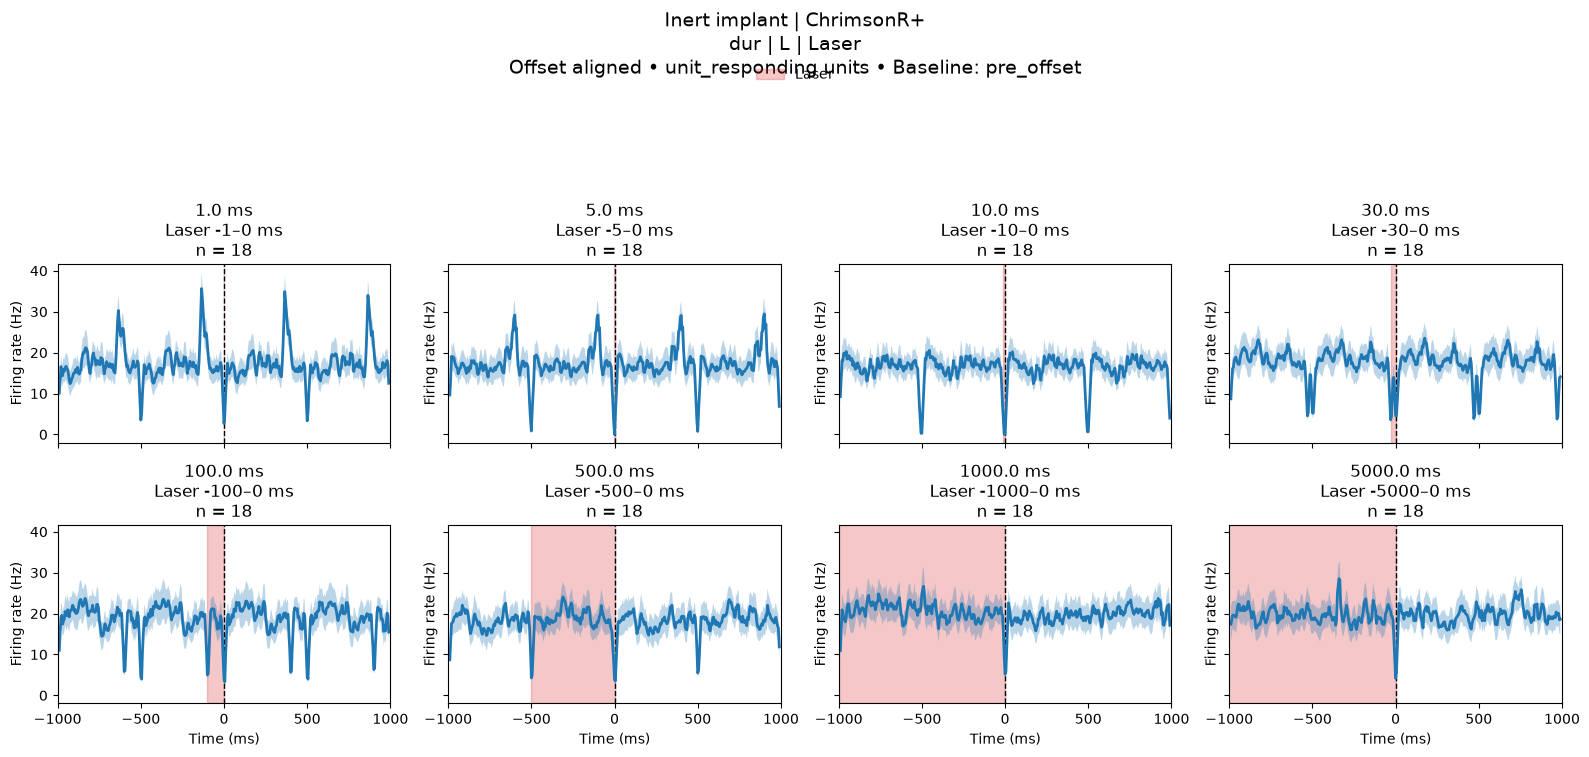

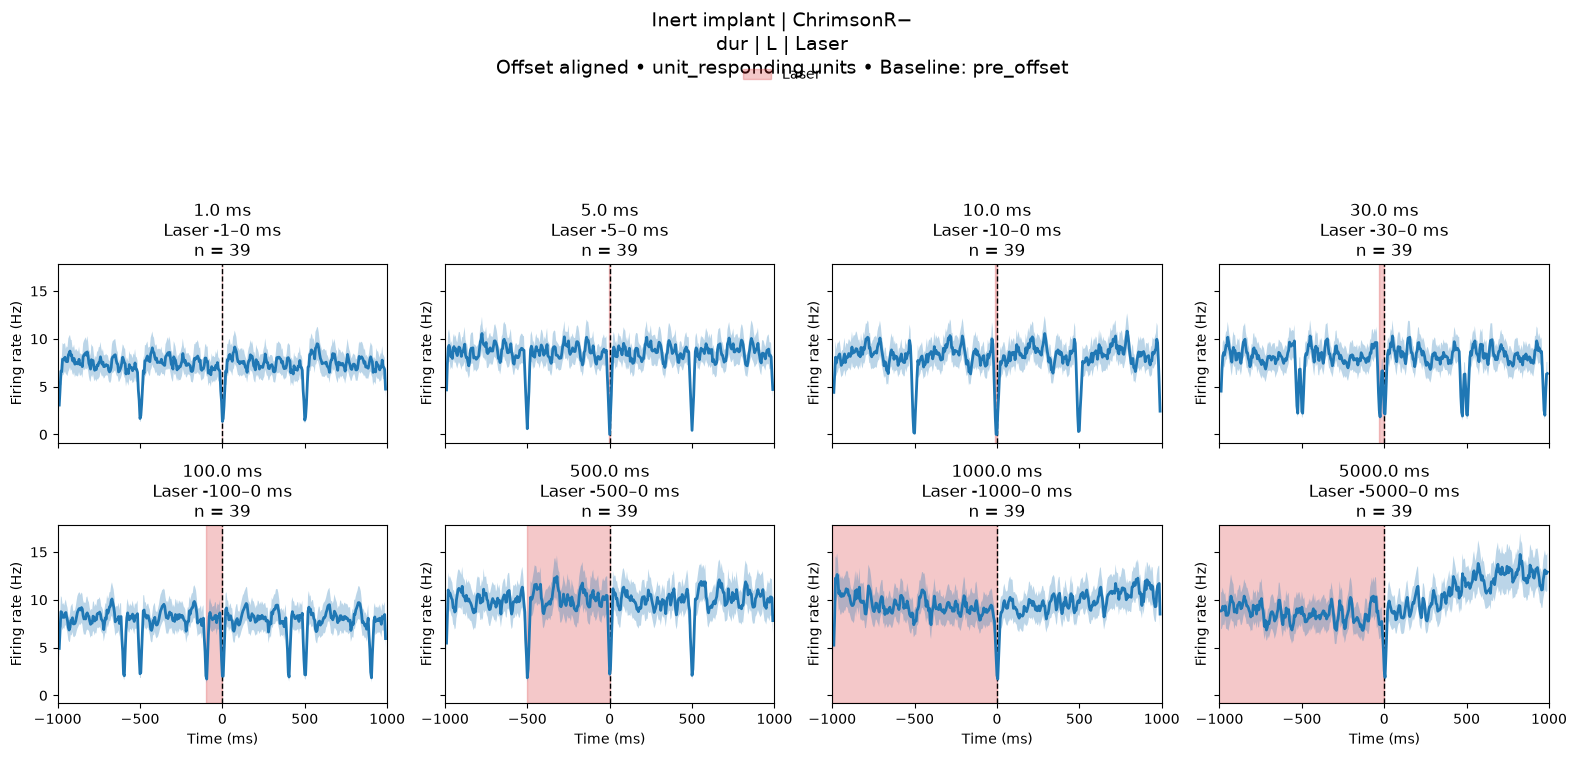

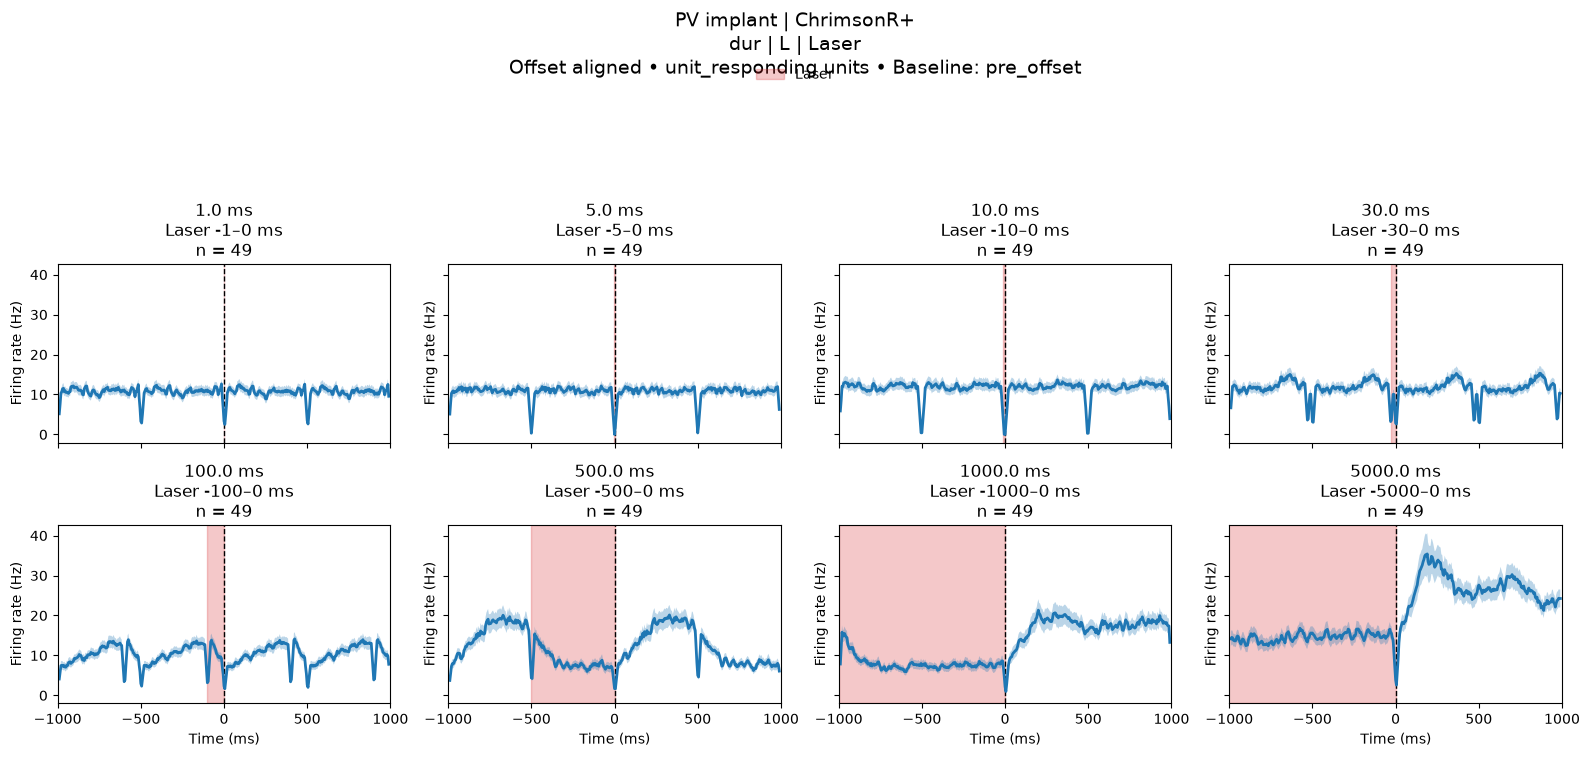

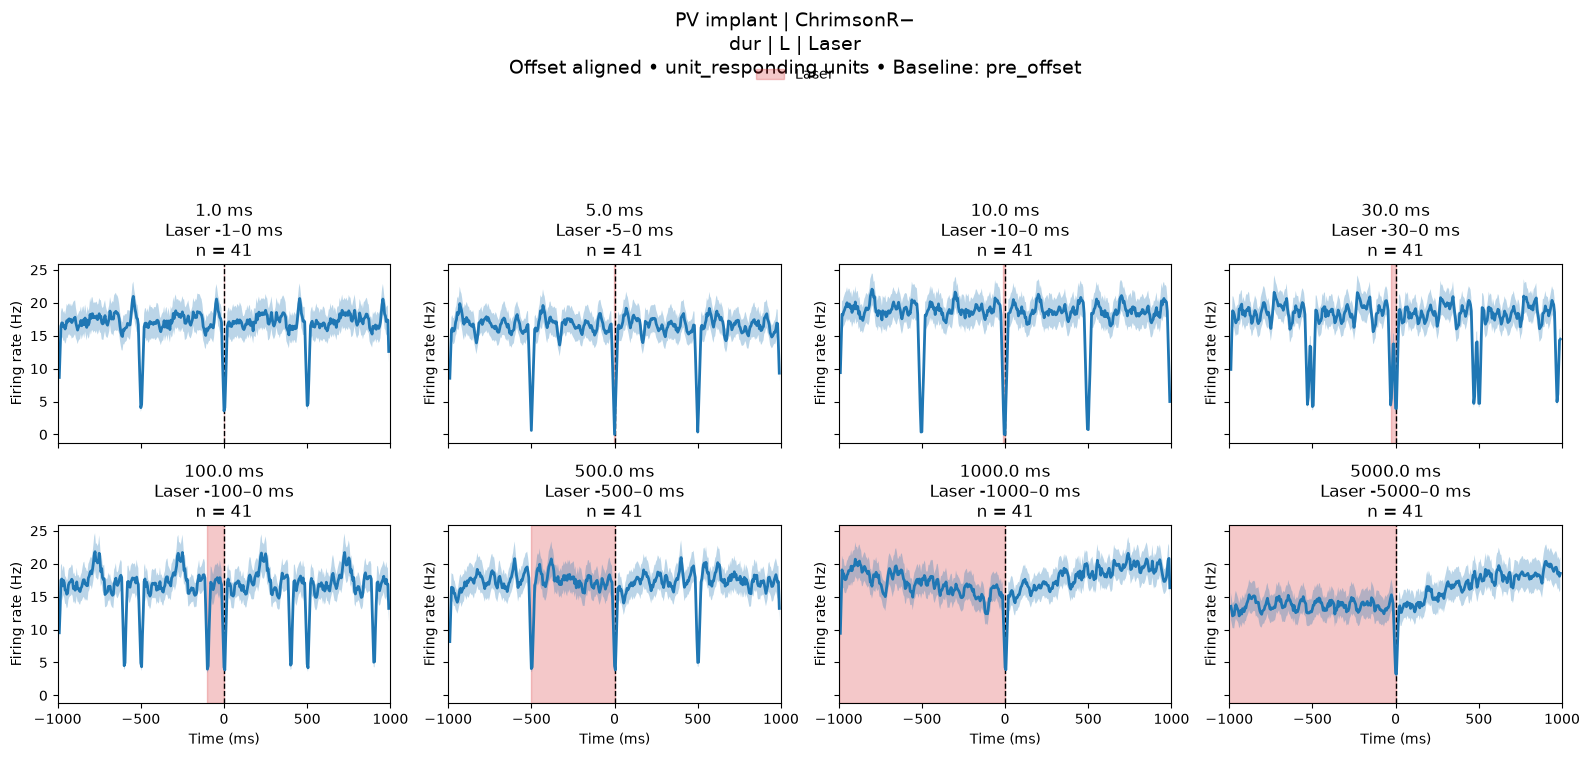

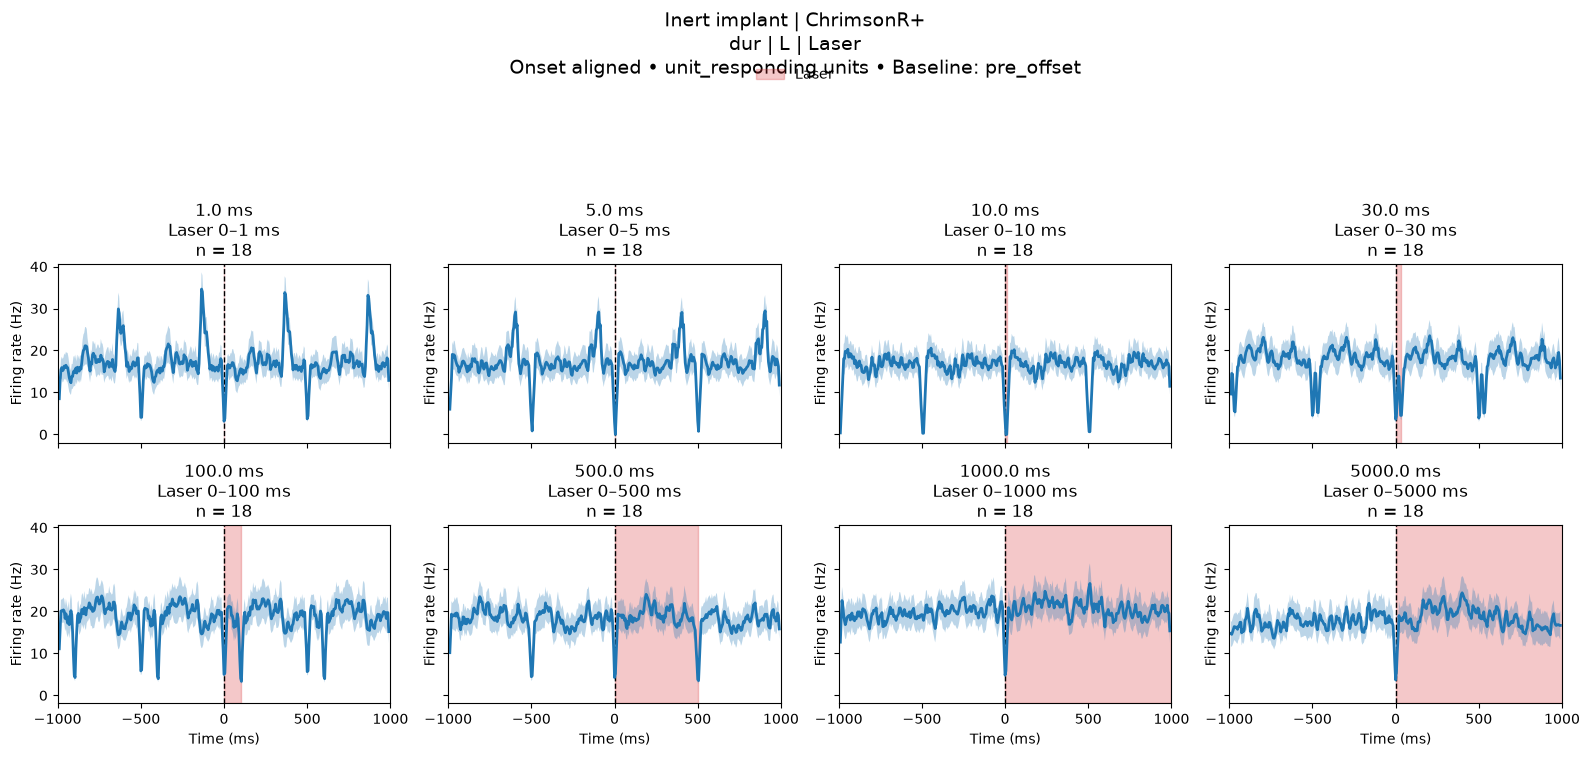

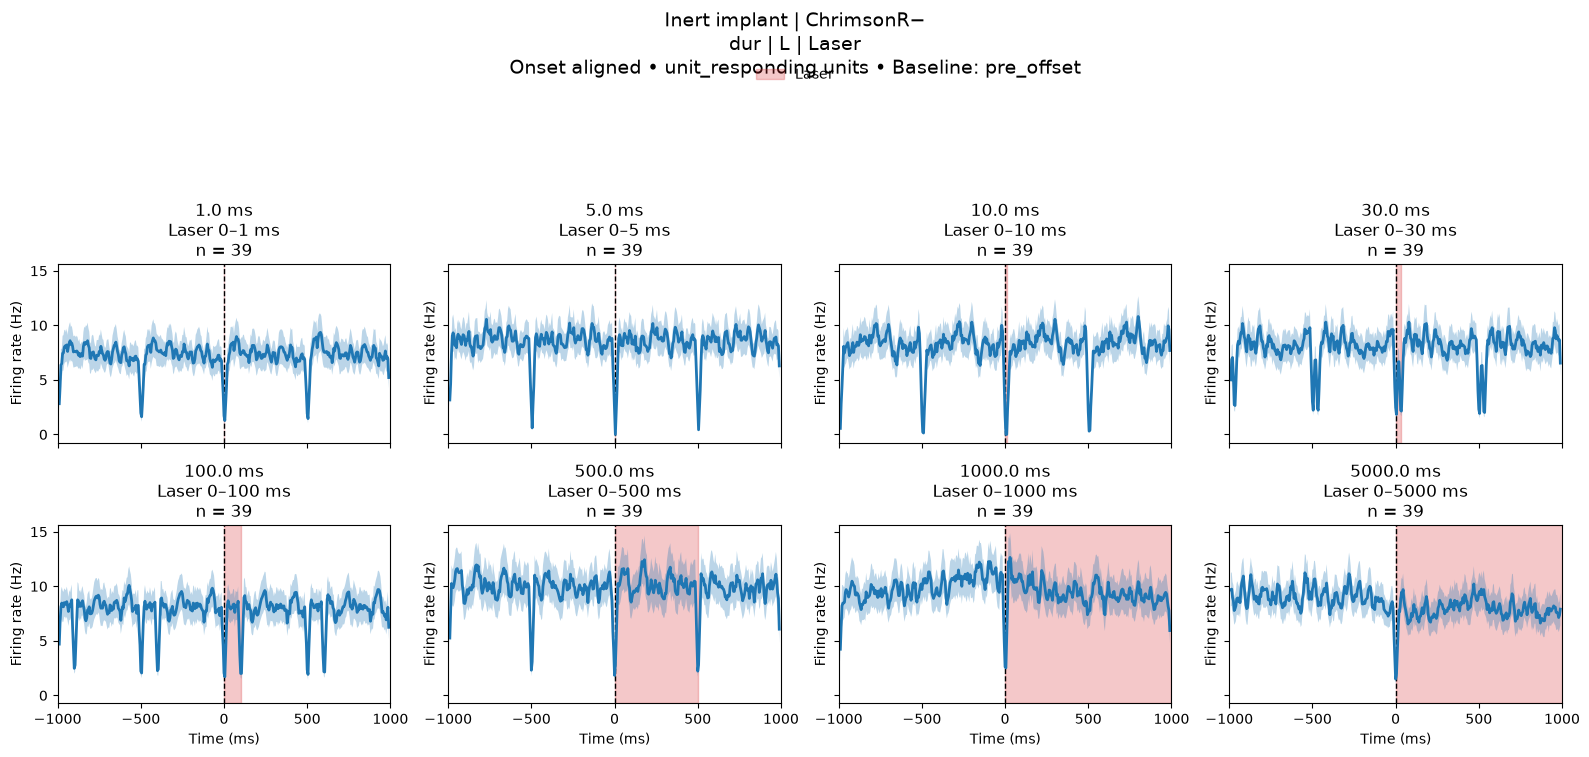

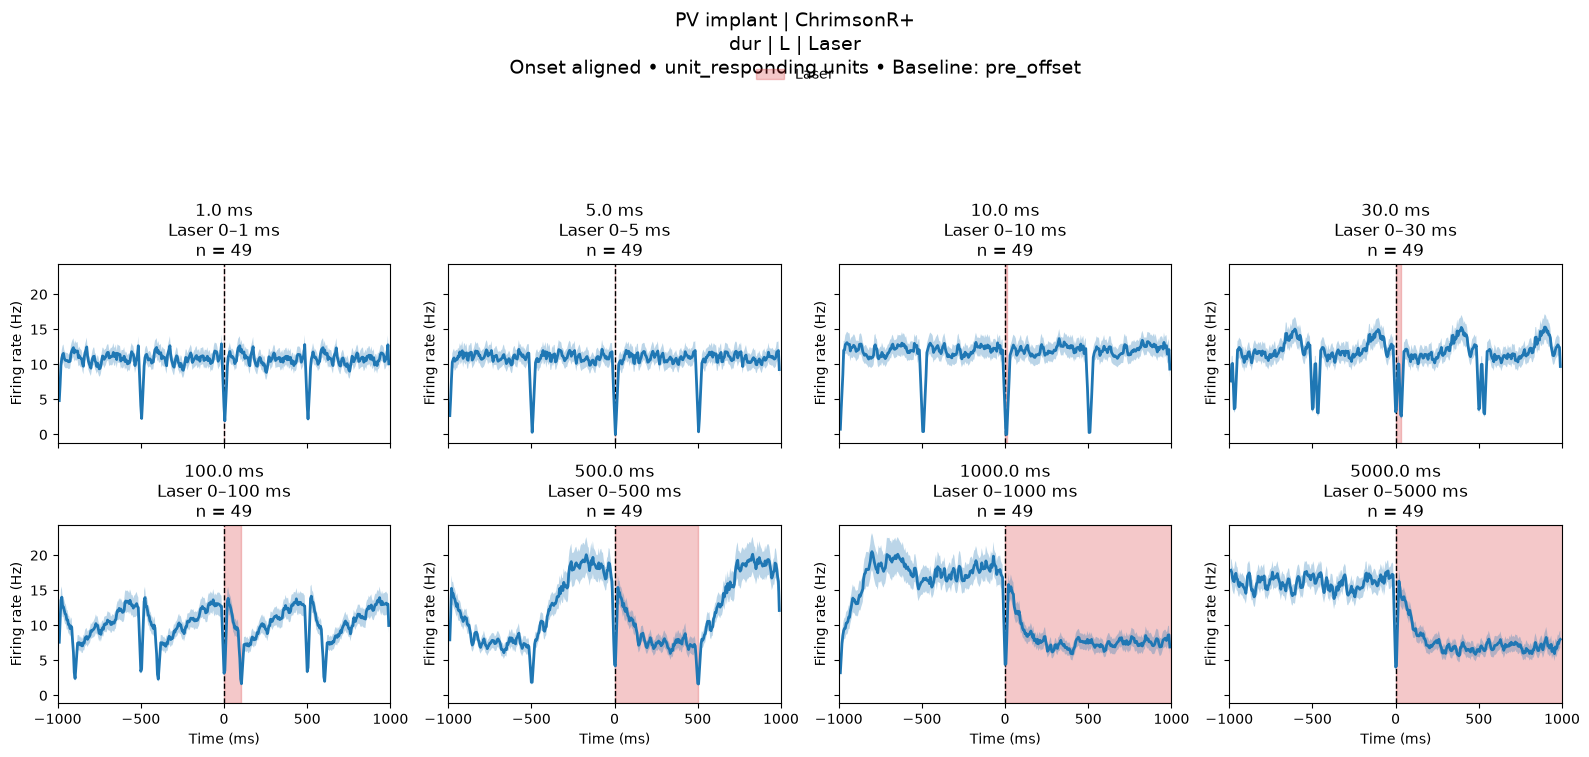

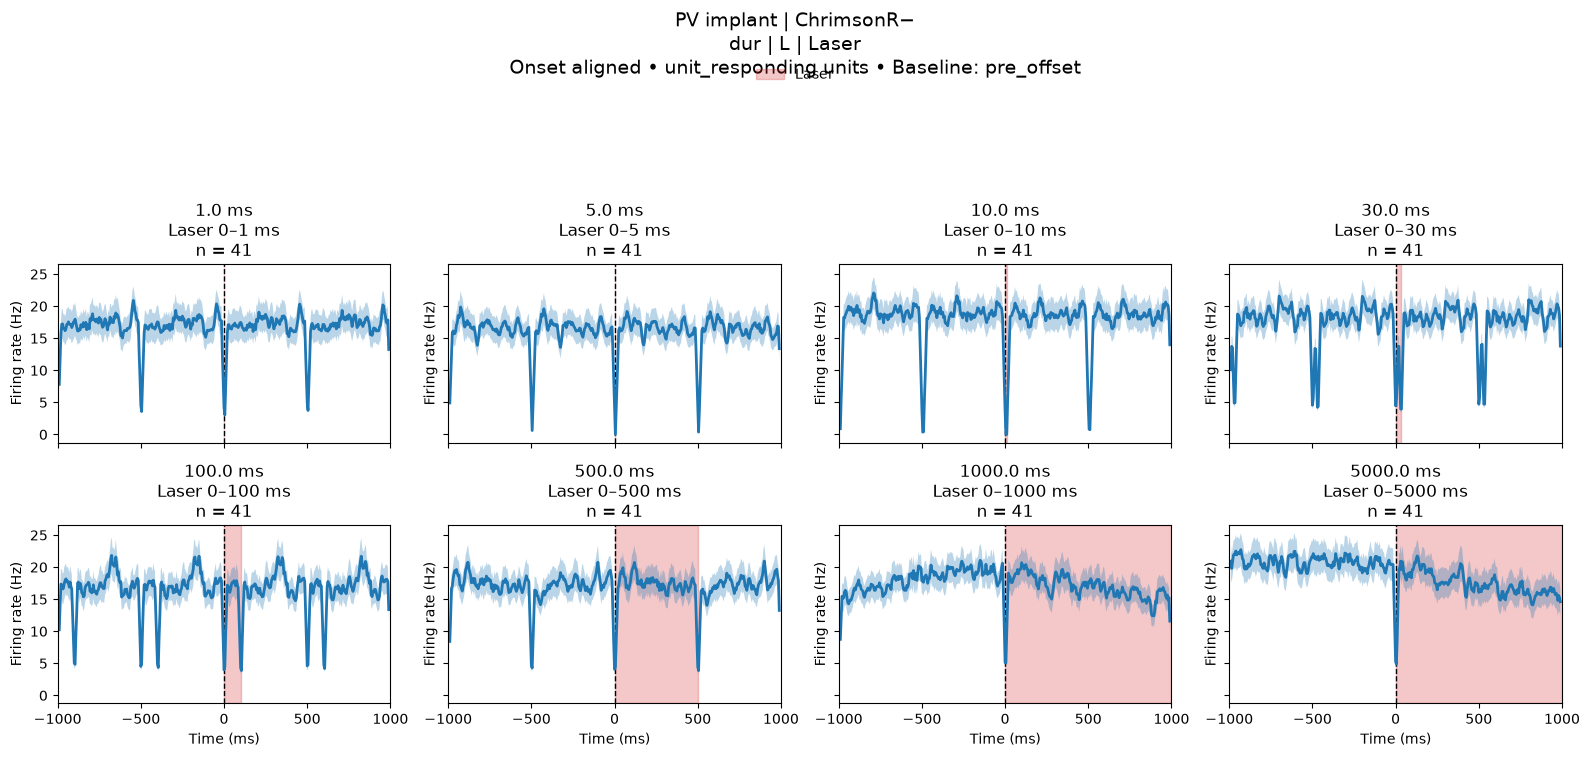

In [ ]:
#45B
# ==========================================
# Plot comparison PSTHs
# ==========================================

"""
Create one figure for each experimental group.

Within each figure, each subplot corresponds to one
stimulus condition.
"""

if len(comparison_psth) == 0:

    print("No comparison PSTHs available.")

else:

    # ======================================
    # Loop over alignments
    # ======================================

    for alignment_name in sorted(comparison_psth):

        # ----------------------------------
        # One figure per comparison group
        # ----------------------------------

        for comparison_label in sorted(

            comparison_psth[
                alignment_name
            ]

        ):

            psth_group = (

                comparison_psth[
                    alignment_name
                ][
                    comparison_label
                ]

            )

            stimulus_values = sorted(

                psth_group.keys()

            )

            n_conditions = len(

                stimulus_values

            )

            # ----------------------------------
            # Figure layout
            # ----------------------------------

            n_cols = 4

            n_rows = int(

                np.ceil(

                    n_conditions / n_cols

                )

            )

            fig, axes = plt.subplots(

                n_rows,

                n_cols,

                figsize=(16, 3.8 * n_rows),

                sharex=True,

                sharey=True,

            )

            axes = np.atleast_1d(

                axes

            ).ravel()

            legend_added = {

                "Laser": False,

                "Polychrome": False,

            }

            # ==================================
            # Plot each stimulus condition
            # ==================================

            for ax, stimulus_value in zip(

                axes,

                stimulus_values,

            ):

                psth = psth_group[stimulus_value]

                stim_windows = psth["stim_windows"]

                time = psth["time"]

                mean = psth["mean"]

                sem = psth["sem"]

                # ------------------------------
                # Shift stimulus windows
                # ------------------------------

                if alignment_name == "offset":

                    reference = next(

                        stop

                        for _, stop, label in stim_windows

                        if label == view

                    )

                else:

                    reference = 0

                display_windows = []

                for start, stop, label in stim_windows:

                    start -= reference
                    stop -= reference

                    display_windows.append(
                        (start, stop, label)
                    )

                    colour = (
                        "tab:red"
                        if label == "Laser"
                        else "tab:blue"
                    )

                    ax.axvspan(

                        start,

                        stop,

                        color=colour,

                        alpha=0.25,

                        zorder=0,

                        label=(
                            label
                            if not legend_added[label]
                            else None
                        ),

                    )

                    legend_added[label] = True

                # ------------------------------
                # PSTH
                # ------------------------------

                ax.axvline(

                    0,

                    color="black",

                    linestyle="--",

                    linewidth=1,

                )

                ax.plot(

                    time,

                    mean,

                    linewidth=2,

                )

                ax.fill_between(

                    time,

                    mean - sem,

                    mean + sem,

                    alpha=0.30,

                )

                ax.set_xlim(

                    analysis_window

                )

                window_text = ", ".join(

                    f"{label} {start:.0f}–{stop:.0f} ms"

                    for start, stop, label in display_windows

                )

                ax.set_title(

                    f"{stimulus_value} ms\n"
                    f"{window_text}\n"
                    f"n = {psth['n_units']}"

                )

                ax.set_ylabel(

                    "Firing rate (Hz)"

                )

            # ==================================
            # Hide unused panels
            # ==================================

            for ax in axes[n_conditions:]:

                ax.set_visible(False)

            # ==================================
            # X-axis labels
            # ==================================

            for ax in axes[-n_cols:]:

                if ax.get_visible():

                    ax.set_xlabel("Time (ms)")

            # ==================================
            # Figure legend
            # ==================================

            handles, labels = axes[0].get_legend_handles_labels()

            if handles:

                unique = dict(zip(labels, handles))

                fig.legend(

                    unique.values(),

                    unique.keys(),

                    loc="upper center",

                    bbox_to_anchor=(0.5, 0.93),

                    ncol=len(unique),

                    frameon=False,

                )

            # ==================================
            # Figure title
            # ==================================

            fig.suptitle(

                f"{comparison_label}\n"
                f"{protocol} | {stim_mode} | {view}\n"
                f"{alignment_name.capitalize()} aligned • "
                f"{include_units} units • "
                f"Baseline: {baseline_mode}",

                fontsize=14,

                y=0.99,

            )

            plt.tight_layout(
                rect=[0, 0, 1, 0.87]
            )

            plt.show()

#### Compute unit PSTHs (46)

In [ ]:
#46

# ==========================================
# Compute unit PSTHs
# ==========================================

"""
Compute one PSTH for every unit.

Workflow

    trials
        ↓
    mean within unit
        ↓
    store individual PSTHs

This database is used for heatmaps,
sorting and future population analyses.
"""

# ==========================================
# Compute unit PSTHs
# ==========================================

unit_psth = {}

# ==========================================
# Pre-group conditions
# ==========================================

grouped = psth_df.groupby(

    [

        "comparison_key",

        "comparison_label",

        "group_value",

        "pattern_key",

    ]

)

condition_groups = {

    key: value

    for key, value in grouped

}

condition_keys = list(condition_groups.keys())

for spike_column in spike_columns:

    alignment_name = spike_column.replace(
        "_spikes",
        "",
    )

    for (
        comparison_key,
        comparison_label,
        group_value,
        pattern_key,
    ) in condition_keys:

        print(

            f"{alignment_name:>6} | "

            f"{comparison_label:<30} | "

            f"{group_value:<8} | "

            f"pattern {hash(pattern_key)%1000}"

        )

        condition_df = condition_groups[
            (
                comparison_key,
                comparison_label,
                group_value,
                pattern_key,
            )
        ]

        first_row = condition_df.iloc[0]

        metadata = first_row["metadata"]

        stim_windows = first_row["stim_windows"]

        session_id = first_row["session_id"]

        rec_id = first_row["rec_id"]

        train_id = first_row["train_id"]

        view_name = first_row["view"]

        baseline_mode = first_row["baseline_mode"]

        units = []

        matrices = []

        # ----------------------------------
        # Compute one PSTH per unit
        # ----------------------------------

        unit_groups = condition_df.groupby(

            "unit_id",

            sort=True,

        )

        for unit_id, unit_df in unit_groups:

            trial_rates = []

            for spiketrain in unit_df[spike_column]:

                spiketrain = np.asarray(spiketrain)

                counts = (

                    (

                        (spiketrain[:, None] >= bin_starts)

                        &

                        (spiketrain[:, None] < bin_ends)

                    )

                    .sum(axis=0)

                    * 1000

                    / bin_width

                )

                trial_rates.append(counts)

            if len(trial_rates) == 0:

                continue

            trial_rates = np.asarray(trial_rates)

            units.append(unit_id)

            matrices.append(

                trial_rates.mean(axis=0)

            )

        if len(matrices) == 0:

            continue

        matrices = np.asarray(matrices)

        unit_psth[
            (
                alignment_name,
                comparison_label,
                group_value,
                pattern_key,
            )
        ] = {

            "alignment": alignment_name,

            "comparison_key": comparison_key,

            "comparison_label": comparison_label,

            "group_value": group_value,

            "pattern_key": pattern_key,

            "session_id": session_id,

            "rec_id": rec_id,

            "train_id": train_id,

            "view": view_name,

            "baseline_mode": baseline_mode,

            "metadata": metadata,

            "stim_windows": stim_windows,

            "time": bin_centres,

            "unit_ids": units,

            "matrix": matrices,

        }

# ==========================================
# Summary
# ==========================================

print()

print("Unit PSTHs")
print("----------")

for key in sorted(unit_psth):

    entry = unit_psth[key]

    print(

        f"{entry['alignment']:>6} | "

        f"{entry['comparison_label']:<30} | "

        f"{entry['group_value']:<8} | "

        f"{entry['matrix'].shape[0]:>3} units"

    )

 onset | PV implant | ChrimsonR−        | 1.0      | pattern 739
 onset | PV implant | ChrimsonR−        | 5.0      | pattern 321
 onset | PV implant | ChrimsonR−        | 10.0     | pattern 640
 onset | PV implant | ChrimsonR−        | 30.0     | pattern 602
 onset | PV implant | ChrimsonR−        | 100.0    | pattern 468
 onset | PV implant | ChrimsonR−        | 500.0    | pattern 842
 onset | PV implant | ChrimsonR−        | 1000.0   | pattern 843
 onset | PV implant | ChrimsonR−        | 5000.0   | pattern 808
 onset | PV implant | ChrimsonR+        | 1.0      | pattern 739
 onset | PV implant | ChrimsonR+        | 5.0      | pattern 321
 onset | PV implant | ChrimsonR+        | 10.0     | pattern 640
 onset | PV implant | ChrimsonR+        | 30.0     | pattern 602
 onset | PV implant | ChrimsonR+        | 100.0    | pattern 468
 onset | PV implant | ChrimsonR+        | 500.0    | pattern 842
 onset | PV implant | ChrimsonR+        | 1000.0   | pattern 843
 onset | PV implant | Chr

#### Sort units and normalizing (47)

In [ ]:
#47

# ==========================================
# Prepare heatmaps
# ==========================================

"""
Normalize, smooth and sort unit PSTHs.

Output
------
heatmap_data

One entry for each stimulation condition that is ready
for plotting.
"""

# ==========================================
# Settings
# ==========================================

heatmap_normalization = "global_zscore"
# "none"
# "baseline"
# "global_zscore"
# "baseline_zscore"
# "max"

sort_units = "peak_latency"
# "none"
# "peak_latency"
# "peak_response"
# "mean_response"

sort_direction = "ascending"
# "ascending"
# "descending"

heatmap_smoothing = 0
# standard deviation (bins)
# 0 = no smoothing

# ==========================================
# Optional smoothing
# ==========================================

from scipy.ndimage import gaussian_filter1d

heatmap_data = {}

# ==========================================
# Process every condition
# ==========================================

for key, entry in unit_psth.items():

    matrix = entry["matrix"].copy()

    time = entry["time"]

    baseline_mode = entry["baseline_mode"]

    if baseline_mode == "onset_baseline":

        current_baseline_window = (-200, -100)

    elif baseline_mode == "pre_offset":

        current_baseline_window = (-200, -100)

    else:

        raise ValueError(

            f"Unknown baseline_mode: {baseline_mode}"

        )

    # --------------------------------------
    # Optional smoothing
    # --------------------------------------

    if heatmap_smoothing > 0:

        matrix = gaussian_filter1d(

            matrix,

            sigma=heatmap_smoothing,

            axis=1,

        )

    # --------------------------------------
    # Normalization
    # --------------------------------------

    if heatmap_normalization == "none":

        norm_matrix = matrix

    elif heatmap_normalization == "global_zscore":

        mean = matrix.mean(axis=1, keepdims=True)

        std = matrix.std(axis=1, keepdims=True)

        std[std == 0] = 1

        norm_matrix = (matrix - mean) / std

    elif heatmap_normalization == "max":

        maximum = matrix.max(axis=1, keepdims=True)

        maximum[maximum == 0] = 1

        norm_matrix = matrix / maximum

    elif heatmap_normalization == "baseline":

        baseline_mask = (

            (time >= baseline_window[0])

            &

            (time <= baseline_window[1])

        )

        baseline = matrix[:, baseline_mask].mean(

            axis=1,

            keepdims=True,

        )

        norm_matrix = matrix - baseline

    elif heatmap_normalization == "baseline_zscore":

        baseline_mask = (

            (time >= current_baseline_window[0])

            &

            (time <= current_baseline_window[1])

        )

        baseline = matrix[:, baseline_mask]

        mean = baseline.mean(

            axis=1,

            keepdims=True,

        )

        std = baseline.std(

            axis=1,

            keepdims=True,

        )

        std[std == 0] = 1

        norm_matrix = (

            matrix - mean

        ) / std

    else:

        raise ValueError(

            f"Unknown normalization: "

            f"{heatmap_normalization}"

        )

    # --------------------------------------
    # Sorting metric
    # --------------------------------------

    if sort_units == "none":

        order = np.arange(norm_matrix.shape[0])

    elif sort_units == "peak_latency":

        order = np.argmax(

            norm_matrix,

            axis=1,

        )

        order = np.argsort(order)

    elif sort_units == "peak_response":

        order = np.argsort(

            norm_matrix.max(axis=1)

        )

    elif sort_units == "mean_response":

        response_mask = time >= 0

        order = np.argsort(

            norm_matrix[:, response_mask].mean(axis=1)

        )

    else:

        raise ValueError(

            f"Unknown sorting: "

            f"{sort_units}"

        )

    if sort_direction == "descending":

        order = order[::-1]

    # --------------------------------------
    # Store
    # --------------------------------------

    heatmap_data[key] = {

        **entry,

        "baseline_mode": entry["baseline_mode"],

        "matrix": norm_matrix[order],

        "unit_ids":

            np.asarray(entry["unit_ids"])[order],

        "comparison_label": entry["comparison_label"],

        "order":

            order,

    }

# ==========================================
# Summary
# ==========================================

print()

print("Heatmaps prepared")
print("-----------------")

print(

    f"Normalization : {heatmap_normalization}"

)

print(

    f"Baseline mode : {baseline_mode}"

)

print(

    f"Sorting       : {sort_units}"

)

print(

    f"Smoothing     : {heatmap_smoothing}"

)

print()

for key in sorted(heatmap_data):

    entry = heatmap_data[key]

    print(

        f"{entry['alignment']:>6} | "

        f"{entry['comparison_label']:<30} | "

        f"{entry['group_value']:<8} | "

        f"{entry['matrix'].shape[0]:>3} units"

    )


Heatmaps prepared
-----------------
Normalization : global_zscore
Baseline mode : onset_baseline
Sorting       : peak_latency
Smoothing     : 0

offset | Inert implant | ChrimsonR+     | 1.0      |  18 units
offset | Inert implant | ChrimsonR+     | 5.0      |  18 units
offset | Inert implant | ChrimsonR+     | 10.0     |  18 units
offset | Inert implant | ChrimsonR+     | 30.0     |  18 units
offset | Inert implant | ChrimsonR+     | 100.0    |  18 units
offset | Inert implant | ChrimsonR+     | 500.0    |  18 units
offset | Inert implant | ChrimsonR+     | 1000.0   |  18 units
offset | Inert implant | ChrimsonR+     | 5000.0   |  18 units
offset | Inert implant | ChrimsonR−     | 1.0      |  39 units
offset | Inert implant | ChrimsonR−     | 5.0      |  39 units
offset | Inert implant | ChrimsonR−     | 10.0     |  39 units
offset | Inert implant | ChrimsonR−     | 30.0     |  39 units
offset | Inert implant | ChrimsonR−     | 100.0    |  39 units
offset | Inert implant | ChrimsonR−

#### Plot heatmaps (48)

C:\Users\au617715\AppData\Local\Temp\ipykernel_45088\149174768.py:389: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


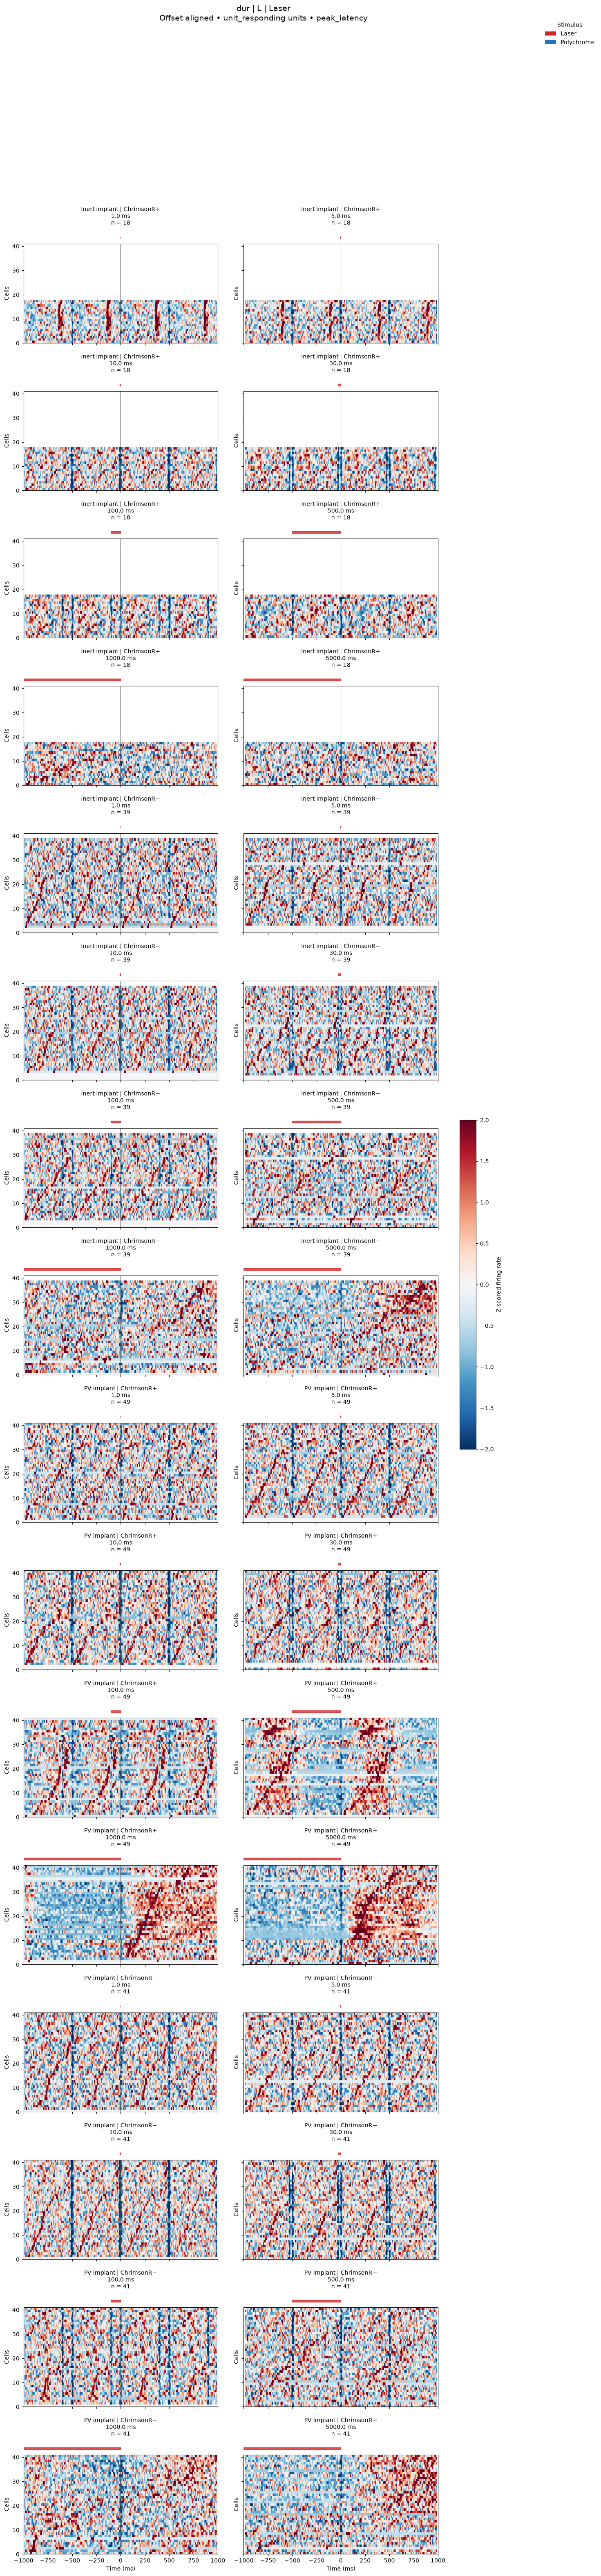

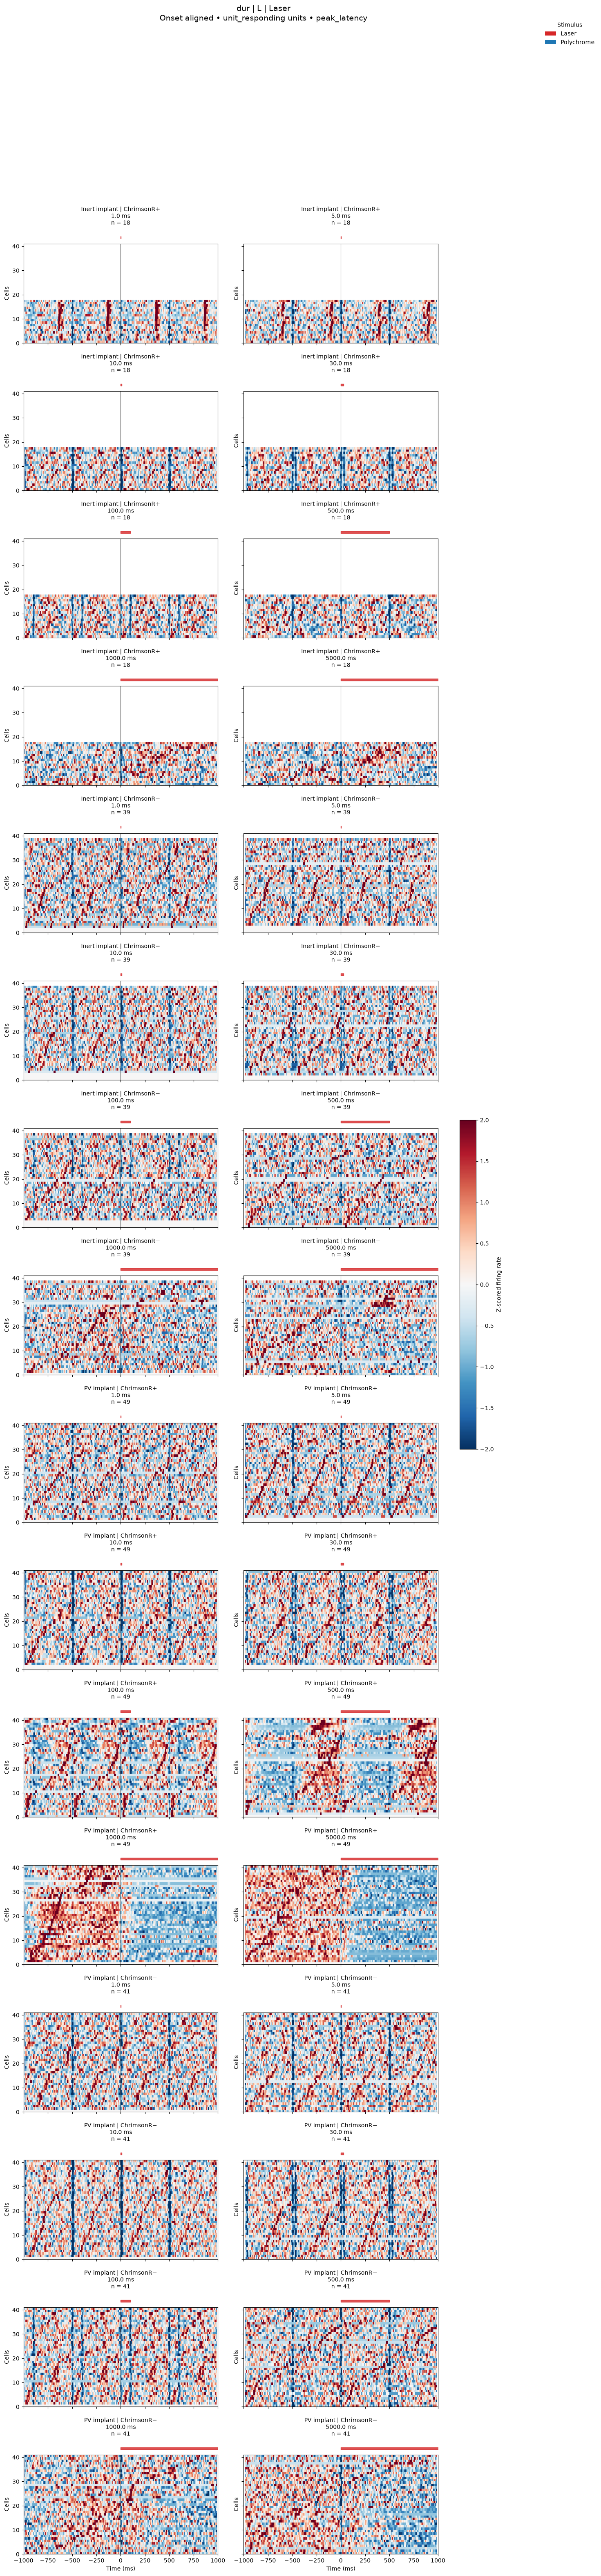

In [ ]:
#48

# ==========================================
# Plot population heatmaps
# ==========================================

if len(heatmap_data) == 0:

    print("No heatmaps available.")

else:

    # ======================================
    # Group by alignment
    # ======================================

    alignment_groups = {}

    for key, entry in heatmap_data.items():

        alignment_groups.setdefault(
            entry["alignment"],
            []
        ).append(key)

    # ======================================
    # Plot each alignment separately
    # ======================================

    for alignment_name in sorted(alignment_groups):

        condition_keys = sorted(

            alignment_groups[alignment_name],

            key=lambda k: (

                heatmap_data[k]["comparison_label"],

                heatmap_data[k]["group_value"],

            ),

        )

        n_conditions = len(condition_keys)

        n_cols = 2

        n_rows = int(
            np.ceil(n_conditions / n_cols)
        )

        fig, axes = plt.subplots(

            n_rows,

            n_cols,

            figsize=(13, 4*n_rows),

            sharex=True,

            sharey=True,

        )

        axes = np.atleast_1d(axes).ravel()

        image = None

        legend_added = {

            "Laser": False,

            "Polychrome": False,

        }

        # ==================================
        # Plot each condition
        # ==================================

        for ax, key in zip(

            axes,

            condition_keys,

        ):

            entry = heatmap_data[key]

            matrix = entry["matrix"]

            time = entry["time"]

            stim_windows = entry["stim_windows"]

            group_value = entry["group_value"]

            # ------------------------------
            # Stimulus alignment
            # ------------------------------

            if alignment_name == "offset":

                reference = next(

                    stop

                    for _, stop, label in stim_windows

                    if label == view

                )

            else:

                reference = 0

            # ------------------------------
            # Heatmap
            # ------------------------------

            if heatmap_normalization == "global_zscore":

                vmin = -2

                vmax = 2

            elif heatmap_normalization == "max":

                vmin = 0

                vmax = 1

            else:

                vmin = None

                vmax = None

            image = ax.imshow(

                matrix,

                aspect="auto",

                origin="lower",

                extent=[

                    time[0],

                    time[-1],

                    0,

                    matrix.shape[0],

                ],

                cmap="RdBu_r",

                vmin=vmin,

                vmax=vmax,

                interpolation="nearest",

            )

            # ------------------------------
            # Stimulus schematic
            # ------------------------------

            stim_ax = ax.inset_axes(

                [0.0, 1.01, 1.0, 0.08]

            )

            stim_ax.set_xlim(analysis_window)

            stim_ax.set_ylim(0, 2)

            stim_ax.axis("off")

            for start, stop, label in stim_windows:

                start -= reference
                stop -= reference

                if label == "Laser":

                    y = 1.1
                    colour = "tab:red"

                else:

                    y = 0.2
                    colour = "tab:blue"

                stim_ax.fill_between(

                    [start, stop],

                    y,

                    y + 0.5,

                    color=colour,

                    alpha=0.8,

                )

                legend_added[label] = True

            # ------------------------------
            # Alignment marker
            # ------------------------------

            ax.axvline(

                0,

                color="0.35",

                linewidth=0.8,

            )

            # ------------------------------
            # Labels
            # ------------------------------

            ax.set_title(

                f"{entry['comparison_label']}\n"
                f"{group_value} ms\n"
                f"n = {matrix.shape[0]}",

                fontsize=10,

                pad=18,

            )

            ax.set_ylabel("Cells")

            ax.set_xlim(analysis_window)

        # ==================================
        # Hide unused panels
        # ==================================

        for ax in axes[n_conditions:]:

            ax.set_visible(False)

        # ==================================
        # X labels
        # ==================================

        for ax in axes[-n_cols:]:

            if ax.get_visible():

                ax.set_xlabel(

                    "Time (ms)"

                )

        from matplotlib.patches import Patch

        # ==================================
        # Stimulus legend
        # ==================================

        legend_handles = [

            Patch(
                facecolor="tab:red",
                edgecolor="none",
                label="Laser",
            ),

            Patch(
                facecolor="tab:blue",
                edgecolor="none",
                label="Polychrome",
            ),

        ]

        fig.legend(

            handles=legend_handles,

            loc="upper left",

            bbox_to_anchor=(1.02, 0.98),

            title="Stimulus",

            frameon=False,

        )

        # ==================================
        # Colourbar
        # ==================================

        visible_axes = [

            ax

            for ax in axes

            if ax.get_visible()

        ]

        cbar = fig.colorbar(

            image,

            ax=visible_axes,

            shrink=0.90,

            pad=0.02,

            fraction=0.04,

        )

        if heatmap_normalization == "global_zscore":

            cbar.set_label(

                "Z-scored firing rate"

            )

        elif heatmap_normalization == "max":

            cbar.set_label(

                "Normalized firing rate"

            )

        else:

            cbar.set_label(

                "Firing rate (Hz)"

            )

        # ==================================
        # Figure title
        # ==================================

        fig.suptitle(

            f"{protocol} | "

            f"{stim_mode} | "

            f"{view}\n"

            f"{alignment_name.capitalize()} aligned • "

            f"{include_units} units • "

            f"{sort_units}",

            fontsize=14,

            y=0.985,

        )

        plt.tight_layout(

            rect=[0, 0, 0.84, 0.92]

        )

        plt.show()

#### 48A Plot single PSTH

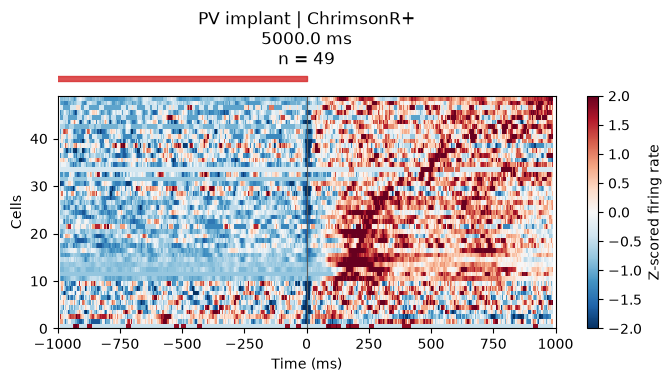

In [ ]:
#48A
# ==========================================
# Plot single population heatmap
# ==========================================

"""
Plot one population heatmap selected by
alignment, experimental group and stimulus
condition.
"""

# ==========================================
# User settings
# ==========================================

plot_alignment = "offset"
# "onset"
# "offset"

plot_comparison = "PV implant | ChrimsonR+"

plot_stimulus = 5000.0

# ==========================================
# Locate heatmap
# ==========================================

selected_key = None

for key, entry in heatmap_data.items():

    if (

        entry["alignment"] == plot_alignment

        and

        entry["comparison_label"] == plot_comparison

        and

        entry["group_value"] == plot_stimulus

    ):

        selected_key = key

        break

if selected_key is None:

    print("Requested heatmap not found.")

else:

    entry = heatmap_data[selected_key]

    matrix = entry["matrix"]

    time = entry["time"]

    stim_windows = entry["stim_windows"]

    # --------------------------------------
    # Alignment
    # --------------------------------------

    if plot_alignment == "offset":

        reference = next(

            stop

            for _, stop, label in stim_windows

            if label == view

        )

    else:

        reference = 0

    # --------------------------------------
    # Colour scaling
    # --------------------------------------

    if heatmap_normalization == "global_zscore":

        vmin = -2
        vmax = 2

    elif heatmap_normalization == "max":

        vmin = 0
        vmax = 1

    else:

        vmin = None
        vmax = None

    # ======================================
    # Figure
    # ======================================

    fig, ax = plt.subplots(

        figsize=(7, 4)

    )

    image = ax.imshow(

        matrix,

        aspect="auto",

        origin="lower",

        extent=[

            time[0],

            time[-1],

            0,

            matrix.shape[0],

        ],

        cmap="RdBu_r",

        vmin=vmin,

        vmax=vmax,

        interpolation="nearest",

    )

    # --------------------------------------
    # Stimulus schematic
    # --------------------------------------

    stim_ax = ax.inset_axes(

        [0.0, 1.02, 1.0, 0.08]

    )

    stim_ax.set_xlim(analysis_window)

    stim_ax.set_ylim(0, 2)

    stim_ax.axis("off")

    for start, stop, label in stim_windows:

        start -= reference
        stop -= reference

        if label == "Laser":

            y = 1.1
            colour = "tab:red"

        else:

            y = 0.2
            colour = "tab:blue"

        stim_ax.fill_between(

            [start, stop],

            y,

            y + 0.5,

            color=colour,

            alpha=0.8,

        )

    # --------------------------------------
    # Alignment marker
    # --------------------------------------

    ax.axvline(

        0,

        color="0.35",

        linewidth=0.8,

    )

    # --------------------------------------
    # Axes
    # --------------------------------------

    ax.set_xlim(analysis_window)

    ax.set_xlabel("Time (ms)")

    ax.set_ylabel("Cells")

    ax.set_title(

        f"{entry['comparison_label']}\n"

        f"{entry['group_value']} ms\n"

        f"n = {matrix.shape[0]}",

    )

    # --------------------------------------
    # Colourbar
    # --------------------------------------

    cbar = plt.colorbar(

        image,

        ax=ax,

    )

    if heatmap_normalization == "global_zscore":

        cbar.set_label(

            "Z-scored firing rate"

        )

    elif heatmap_normalization == "max":

        cbar.set_label(

            "Normalized firing rate"

        )

    else:

        cbar.set_label(

            "Firing rate (Hz)"

        )

    plt.tight_layout()

    plt.show()

In [ ]:
#48B
# ==========================================
# Find most responsive unit
# ==========================================

"""
Identify the unit with the largest mean response
within the current heatmap selection.
"""

# ==========================================
# Response window
# ==========================================

response_window = (10, 200)

response_mask = (

    (time >= response_window[0])

    &

    (time <= response_window[1])

)

# ==========================================
# Mean response
# ==========================================

response_strength = np.mean(

    matrix[:, response_mask],

    axis=1,

)

best_index = np.argmax(response_strength)

best_unit = entry["unit_ids"][best_index]

print()

print("Most responsive unit")

print("--------------------")

print(f"Index          : {best_index}")

print(f"Unit ID        : {best_unit}")

print(f"Response (Hz)  : {response_strength[best_index]:.2f}")


Most responsive unit
--------------------
Index          : 13
Unit ID        : uid_20260601_014
Response (Hz)  : 1.13


### Quantitative population analysis

#### 49 Configuration cell for quantitative analysis

In [ ]:
#49
# ==========================================
# Population statistics configuration
# ==========================================

"""
Configure quantitative analyses based on unit PSTHs.

Each statistic is calculated from the trial-averaged
PSTH of each unit.

The following cells will

    #50  Compute population statistics

    #51  Summarise statistics database

    #52  Shared plotting helper

    #53  Response firing rate

    #54  Response latency
"""

# ==========================================
# Recording selection
# ==========================================

protocol = "longstim"
# "pow"
# "dur"
# "freq"
# "del"
# "del2"
# "longstim"
# None (= all)

stim_mode = "P"
# "P"
# "L"
# "B"
# None (= all)

laser_mode = "N"
# "N"
# "LC"
# None (= all)

view = "Polychrome"
# "Laser"
# "Polychrome"

include_units = "unit_responding"
# "responding"
# "unit_responding"
# "all"

baseline_mode = "onset_baseline"
# "onset_baseline"
# "pre_offset"

event = "onset"
# "onset"
# "offset"
# "both"

# ==========================================
# Plot settings
# ==========================================

plot_alignment = "onset"
# "onset"
# "offset"

# ==========================================
# Experimental grouping
# ==========================================

statistics_comparison_groups = [
    "implant", "chrimsonr"
]
# Examples
#
# ["implant"]
#
# ["chrimsonr"]
#
# ["implant", "chrimsonr"]

# ==========================================
# Comparison styles
# ==========================================

statistics_comparison_styles = build_comparison_styles(

    statistics_comparison_groups,

)

# ==========================================
# Comparison selection
# ==========================================

selected_comparison_keys = [

    ("functional", True),      # PV implant | ChrimsonR+
    ("functional", False),     # PV implant | ChrimsonR−

    ("nonfunctional", True),   # Inert implant | ChrimsonR+
    ("nonfunctional", False),  # Inert implant | ChrimsonR−

]

# None = plot every available comparison.
#
# Examples
#
# Only ChrimsonR−
#
# [
#     ("functional", False),
#     ("nonfunctional", False),
# ]
#
# Only PV implants
#
# [
#     ("functional", True),
#     ("functional", False),
# ]
#
# Only ChrimsonR+
#
# [
#     ("functional", True),
#     ("nonfunctional", True),
# ]
#
# Only inert implants
#
# [
#     ("nonfunctional", True),
#     ("nonfunctional", False),
# ]

# ==========================================
# Stimulus grouping
# ==========================================

stimulus_group = "group_value"

# ==========================================
# Stimulus selection
# ==========================================

selected_group_values = [10, 500, 1000, 5000]
# None = plot all
#
# Example:
# [1, 10, 100, 1000]
#
# or
# [1, 30, 5000]

# ==========================================
# Baseline / response windows
# ==========================================

baseline_window = (-200, -100)

response_window = (10, 200)

peak_search_window = (10, 200)
# ==========================================
# Response detection
# ==========================================

response_polarity = "automatic"

# "automatic"
#     Use bootstrap significance to determine
#     whether each unit responds with excitation
#     or inhibition, then detect the appropriate
#     peak.
#
# "excitation"
#     Always detect the maximum firing rate. Basically useless, because it will always detect the maximum firing rate, even if the unit is inhibited.
#
# "inhibition"
#     Always detect the minimum firing rate. Basically useless, because it will always detect the minimum firing rate, even if the unit is excited.
#
# "absolute"
#     Detect the largest absolute deviation
#     from baseline.
#
#     The sign of the peak is preserved.

# Ignore peaks immediately after alignment

latency_threshold = 3
# Baseline SDs required for a significant response.

latency_consecutive_bins = 3
# Number of consecutive significant bins required
# to define response onset.

# ==========================================
# Statistic to analyse
# ==========================================

statistic = "peak_rate"

# "baseline_rate"
#     Mean firing rate during the baseline window
#     (currently -200 to -100 ms).
#
#     Useful for testing whether experimental
#     groups differ in spontaneous activity.

# "response_rate"
#     Mean firing rate across the response window
#     (currently 10-200 ms).
#
#     Represents the average evoked firing rate.
#     Suitable for sustained responses, but can
#     underestimate brief transient responses.

# "peak_rate"
#     Maximum or minimum firing rate within the
#     peak search window (currently 10-200 ms).
#
#     Peak detection follows response_polarity:
#
#         automatic  → detect excitation or
#                      inhibition from bootstrap.
#
#         excitation → maximum firing rate.
#
#         inhibition → minimum firing rate.
#
#         absolute   → largest deviation from
#                      baseline.
#
#     Recommended for brief optogenetic responses.

# "peak_latency"
#     Time (ms) at which the detected peak occurs.
#
#     This is NOT response onset.
#     It measures when the response reaches its
#     maximum (or minimum) amplitude.

# "onset_latency"
#     First significant response bin detected by
#     the bootstrap algorithm.
#
#     Requires latency_consecutive_bins
#     consecutive significant bins.
#
#     This is the biologically meaningful response
#     latency reported in most electrophysiology
#     studies.

# "response_amplitude"
#     Peak firing rate minus baseline firing rate.
#
#     Positive values indicate excitation.
#     Negative values indicate inhibition.

# "auc"
#     Area under the PSTH within the response
#     window.
#
#     Includes baseline firing.
#
#     Mostly useful for sustained responses.

# "baseline_corrected_auc"
#     Area under the PSTH after subtracting the
#     baseline firing rate.
#
#     Measures total evoked activity.
#     Preferred over raw AUC.

# "modulation_index"
#     (Peak − Baseline) / (Peak + Baseline)
#
#     Dimensionless measure of response strength.
#
#     Values near +1 indicate strong excitation.
#     Values near -1 indicate strong inhibition.
#     Values near 0 indicate little modulation.

# "peak_zscore"
#     Peak response expressed in units of baseline
#     standard deviation.
#
#     Measures effect size rather than absolute
#     firing rate.

# ==========================================
# Figure settings
# ==========================================

#plot_style = "box"
# "box"
# "violin"
# "bar"

show_points = True

show_mean = True

show_statistics = True

show_pairwise_statistics = True

# ==========================================
# Filter population summary
# ==========================================

statistics_filtered_summary = filter_population_summary(

    population_summary,

    protocol=protocol,
    stim_mode=stim_mode,
    laser_mode=laser_mode,
    view=view,
    baseline_mode=baseline_mode,
    event=event,
    include_units=include_units,

)

statistics_comparison_df = build_comparison_labels(

    statistics_filtered_summary,

    statistics_comparison_groups,

    comparison_styles=statistics_comparison_styles,

)

# ==========================================
# Summary
# ==========================================

print()

print("Population statistics selection")
print("-------------------------------")

print(
    f"Sessions   : "
    f"{statistics_comparison_df['session_id'].nunique()}"
)

print(
    f"Recordings : "
    f"{statistics_comparison_df['rec_id'].nunique()}"
)

print(
    f"Units      : "
    f"{statistics_comparison_df['unit_id'].nunique()}"
)

print(
    f"Conditions : "
    f"{statistics_comparison_df['group_value'].nunique()}"
)

print(
    f"Comparison : "
    f"{statistics_comparison_groups}"
)

print(
    f"Event      : "
    f"{event}"
)

print(
    f"Baseline   : "
    f"{baseline_mode}"
)

if not statistics_comparison_df.empty:

    display(

        statistics_comparison_df[
        [
            "session_id",
            "rec_id",
            "unit_id",
            "comparison_label",
            "group_value",
        ]
    ]
        .sort_values(
            [
                "rec_id",
                "group_value",
                "unit_id",
            ]
        )
        .head(20)

    )

else:

    print()

    print("No matching recordings.")


Population statistics selection
-------------------------------
Sessions   : 4
Recordings : 3
Units      : 51
Conditions : 5
Comparison : ['implant', 'chrimsonr']
Event      : onset
Baseline   : onset_baseline


,session_id,rec_id,unit_id,comparison_label,group_value
132,20260604_eye1_2nd,10_N_P_longstim,uid_20260604_000,PV implant | ChrimsonR−,100.0
174,20260604_eye2_2nd,10_N_P_longstim,uid_20260604_000,Inert implant | ChrimsonR−,100.0
136,20260604_eye1_2nd,10_N_P_longstim,uid_20260604_002,PV implant | ChrimsonR−,100.0
178,20260604_eye2_2nd,10_N_P_longstim,uid_20260604_004,Inert implant | ChrimsonR−,100.0
182,20260604_eye2_2nd,10_N_P_longstim,uid_20260604_008,Inert implant | ChrimsonR−,100.0
186,20260604_eye2_2nd,10_N_P_longstim,uid_20260604_009,Inert implant | ChrimsonR−,100.0
190,20260604_eye2_2nd,10_N_P_longstim,uid_20260604_010,Inert implant | ChrimsonR−,100.0
140,20260604_eye1_2nd,10_N_P_longstim,uid_20260604_011,PV implant | ChrimsonR−,100.0
144,20260604_eye1_2nd,10_N_P_longstim,uid_20260604_013,PV implant | ChrimsonR−,100.0
194,20260604_eye2_2nd,10_N_P_longstim,uid_20260604_013,Inert implant | ChrimsonR−,100.0


#### 49A Prepare statistics PSTHs

In [ ]:
#49A
# ==========================================
# Prepare statistics PSTHs
# ==========================================

"""
Create a filtered copy of unit_psth for the
population statistics workflow.

The original unit_psth database remains
unchanged and can still be used by heatmaps
and other analyses.

Filtering is performed using
statistics_filtered_summary, which already
contains all recording- and unit-level
selection made in #49.
"""

# ==========================================
# Valid units
# ==========================================

valid_units = set(

    zip(

        statistics_filtered_summary["session_id"],
        statistics_filtered_summary["rec_id"],
        statistics_filtered_summary["unit_id"],
        statistics_filtered_summary["group_value"],

    )

)

# ==========================================
# Build filtered PSTH database
# ==========================================

statistics_unit_psth = {}

for key, entry in unit_psth.items():

    keep_units = []

    keep_matrix = []

    # --------------------------------------
    # Keep only selected units
    # --------------------------------------

    for row, unit_id in enumerate(entry["unit_ids"]):

        lookup_key = (

            entry["session_id"],
            entry["rec_id"],
            unit_id,
            entry["group_value"],

        )

        if lookup_key not in valid_units:

            continue

        keep_units.append(unit_id)

        keep_matrix.append(

            entry["matrix"][row]

        )

    # --------------------------------------
    # Skip empty conditions
    # --------------------------------------

    if len(keep_units) == 0:

        continue

    statistics_entry = entry.copy()

    statistics_entry["unit_ids"] = keep_units

    statistics_entry["matrix"] = np.asarray(

        keep_matrix

    )

    statistics_unit_psth[key] = statistics_entry

# ==========================================
# Summary
# ==========================================

print()

print("Statistics PSTHs")
print("----------------")

print(

    f"Conditions : "

    f"{len(statistics_unit_psth)}"

)

print(

    f"Units      : "

    f"{sum(len(entry['unit_ids']) for entry in statistics_unit_psth.values())}"

)

print()

for key in sorted(statistics_unit_psth):

    entry = statistics_unit_psth[key]

    print(

        f"{entry['alignment']:>6} | "

        f"{entry['comparison_label']:<30} | "

        f"{entry['group_value']:<8} | "

        f"{len(entry['unit_ids']):>3} units"

    )


Statistics PSTHs
----------------
Conditions : 0
Units      : 0



#### 50 Compute population statistics

In [ ]:
#50A
# ==========================================
# Compute population statistics
# Part 1 - Prepare statistics table
# ==========================================

"""
Compute quantitative statistics from the
trial-averaged PSTH of every unit.

Each row of the final table corresponds to one unit
under one stimulation condition.
"""

population_statistics = []

# ==========================================
# Bootstrap helper
# ==========================================

def get_bootstrap_result(

    session_id,
    rec_id,
    unit_id,
    baseline_mode,
    view,
    train_id,
    alignment,

):
    """
    Return the bootstrap result corresponding to one
    unit, stimulus condition and alignment.
    """

    event = (

        "onset"

        if alignment == "onset"

        else "offset"

    )

    return (

        population_bootstrap

        [session_id]

        [rec_id]

        [unit_id]

        [baseline_mode]

        [view]

        [train_id]

        [event]

    )

# ==========================================
# Loop over all unit PSTHs
# ==========================================

for key, entry in statistics_unit_psth.items():

    print(

        f"{entry['alignment']:>6} | "

        f"{entry['comparison_label']:<20} | "

        f"{entry['group_value']}"

    )

    matrix = entry["matrix"]

    unit_ids = entry["unit_ids"]

    time = entry["time"]

    # --------------------------------------
    # Analysis windows
    # --------------------------------------

    baseline_mask = (

        (time >= baseline_window[0])

        &

        (time <= baseline_window[1])

    )

    response_mask = (

        (time >= response_window[0])

        &

        (time <= response_window[1])

    )

    peak_mask = (

        (time >= peak_search_window[0])

        &

        (time <= peak_search_window[1])

    )

    if matrix.shape[1] != len(time):

        raise ValueError(

            f"Matrix has {matrix.shape[1]} bins "

            f"but time axis has {len(time)}."

        )

    metadata = entry["metadata"]

    session_id = entry["session_id"]

    rec_id = entry["rec_id"]

    train_id = entry["train_id"]

    stim_windows = entry["stim_windows"]

    comparison_key = entry["comparison_key"]

    comparison_label = entry["comparison_label"]

    group_value = entry["group_value"]

    alignment = entry["alignment"]

    pattern_key = entry["pattern_key"]

    # --------------------------------------
    # Compute one statistics row per unit
    # --------------------------------------

    for unit_index, unit_id in enumerate(unit_ids):

        psth = matrix[unit_index]

        baseline_rate = np.mean(

            psth[baseline_mask]

        )

        response_rate = np.mean(

            psth[response_mask]

        )

        response_curve = psth[peak_mask]

        response_time = time[peak_mask]

        # ----------------------------------
        # Baseline statistics
        # ----------------------------------

        baseline_sd = np.std(

            psth[baseline_mask],

            ddof=1,

        )

        # ----------------------------------
        # Onset latency
        # Bootstrap significance
        # ----------------------------------

        bootstrap = get_bootstrap_result(

            session_id=session_id,

            rec_id=rec_id,

            unit_id=unit_id,

            baseline_mode=baseline_mode,

            view=view_name,

            train_id=train_id,

            alignment=alignment,

        )

        significant_bins = (

            bootstrap["excited_bins"]

            |

            bootstrap["inhibited_bins"]

        )

        valid_bins = bootstrap["valid_mask"]

        candidate_bins = significant_bins & valid_bins

        bin_centres = bootstrap["bin_centres"]

        onset_latency = np.nan

        consecutive = latency_consecutive_bins

        indices = np.where(candidate_bins)[0]

        for start in range(

            len(indices)

            - consecutive + 1

        ):

            window = indices[

                start :

                start + consecutive

            ]

            if np.all(

                np.diff(window) == 1

            ):

                onset_latency = (

                    bin_centres[window[0]]

                    - bootstrap["time_shift"]

                )

                break
        # ----------------------------------
        # Response statistics
        # ----------------------------------

        response_sd = np.std(

            psth[response_mask],

            ddof=1,

        )

        # ----------------------------------
        # Response detection
        # ----------------------------------

        excited = np.any(

            bootstrap["excited_bins"]

            &

            valid_bins

        )

        inhibited = np.any(

            bootstrap["inhibited_bins"]

            &

            valid_bins

        )

        # ----------------------------------
        # Determine response polarity
        # ----------------------------------

        if response_polarity == "automatic":

            if excited and not inhibited:

                mode = "excitation"

            elif inhibited and not excited:

                mode = "inhibition"

            elif excited and inhibited:

                mode = "absolute"

            else:

                mode = "absolute"

        elif response_polarity in (

            "excitation",

            "inhibition",

            "absolute",

        ):

            mode = response_polarity

        else:

            raise ValueError(

                f"Unknown response_polarity: "

                f"{response_polarity}"

            )

        # ----------------------------------
        # Detect response peak
        # ----------------------------------

        if mode == "excitation":

            peak_index = np.argmax(

                response_curve

            )

        elif mode == "inhibition":

            peak_index = np.argmin(

                response_curve

            )

        elif mode == "absolute":

            peak_index = np.argmax(

                np.abs(

                    response_curve

                )

            )

        peak_rate = response_curve[
            peak_index
        ]

        peak_latency = response_time[
            peak_index
        ]

        detected_polarity = mode

        # ----------------------------------
        # Response amplitude
        # ----------------------------------

        response_amplitude = (

            peak_rate

            - baseline_rate

        )

        # ----------------------------------
        # Area under curve
        # ----------------------------------

        auc = np.trapezoid(

            response_curve,

            response_time,

        )

        # ----------------------------------
        # Baseline-corrected AUC
        # ----------------------------------

        baseline_corrected_auc = np.trapezoid(

            response_curve - baseline_rate,

            response_time,

        )

        # ----------------------------------
        # Modulation index
        # ----------------------------------

        denominator = (

            peak_rate

            + baseline_rate

        )

        if denominator == 0:

            modulation_index = np.nan

        else:

            modulation_index = (

                (peak_rate - baseline_rate)

                / denominator

            )

        # ----------------------------------
        # Peak z-score
        # ----------------------------------

        if baseline_sd == 0:

            peak_zscore = np.nan

        else:

            peak_zscore = (

                peak_rate

                - baseline_rate

            ) / baseline_sd

        # ----------------------------------
        # Store statistics
        # ----------------------------------

        population_statistics.append(

            {

                 "session_id": session_id,

                "rec_id": rec_id,

                "train_id": train_id,

                "view": view,

                "baseline_mode": baseline_mode,

                "event": event,

                "alignment": alignment,

                "comparison_key": comparison_key,

                "comparison_label": comparison_label,

                "group_value": group_value,

                "pattern_key": pattern_key,

                "unit_id": unit_id,

                "metadata": metadata,

                "stim_windows": stim_windows,

                "baseline_rate": baseline_rate,

                "baseline_sd": baseline_sd,

                "response_rate": response_rate,

                "response_sd": response_sd,

                "peak_rate": peak_rate,

                "peak_latency": peak_latency,

                "detected_response_polarity": detected_polarity,

                "has_excitation": excited,

                "has_inhibition": inhibited,

                "onset_latency": onset_latency,

                "response_amplitude": response_amplitude,

                "auc": auc,

                "baseline_corrected_auc":
                    baseline_corrected_auc,

                "modulation_index":
                    modulation_index,

                "peak_zscore":
                    peak_zscore,

            }

        )

# ==========================================
# Build statistics table
# ==========================================

population_statistics = pd.DataFrame(
    population_statistics
)
print(population_statistics.columns.tolist())

# ==========================================
# Summary
# ==========================================

print()

print("Population statistics")
print("---------------------")

print(
    f"Rows : {len(population_statistics)}"
)

print(
    f"Units: "
    f"{population_statistics['unit_id'].nunique()}"
)

display(
    population_statistics.head()
)

[]

Population statistics
---------------------
Rows : 0


KeyError: 'unit_id'

#### Plot single unit PSTH diagnostic


Unit found in
-------------
 onset | PV implant | ChrimsonR−        | 1.0
 onset | PV implant | ChrimsonR−        | 5.0
 onset | PV implant | ChrimsonR−        | 10.0
 onset | PV implant | ChrimsonR−        | 30.0
 onset | PV implant | ChrimsonR−        | 100.0
 onset | PV implant | ChrimsonR−        | 500.0
 onset | PV implant | ChrimsonR−        | 1000.0
 onset | PV implant | ChrimsonR−        | 5000.0
 onset | Inert implant | ChrimsonR−     | 1.0
 onset | Inert implant | ChrimsonR−     | 5.0
 onset | Inert implant | ChrimsonR−     | 10.0
 onset | Inert implant | ChrimsonR−     | 30.0
 onset | Inert implant | ChrimsonR−     | 100.0
 onset | Inert implant | ChrimsonR−     | 500.0
 onset | Inert implant | ChrimsonR−     | 1000.0
 onset | Inert implant | ChrimsonR−     | 5000.0
offset | PV implant | ChrimsonR−        | 1.0
offset | PV implant | ChrimsonR−        | 5.0
offset | PV implant | ChrimsonR−        | 10.0
offset | PV implant | ChrimsonR−        | 30.0
offset | PV implant | Chr

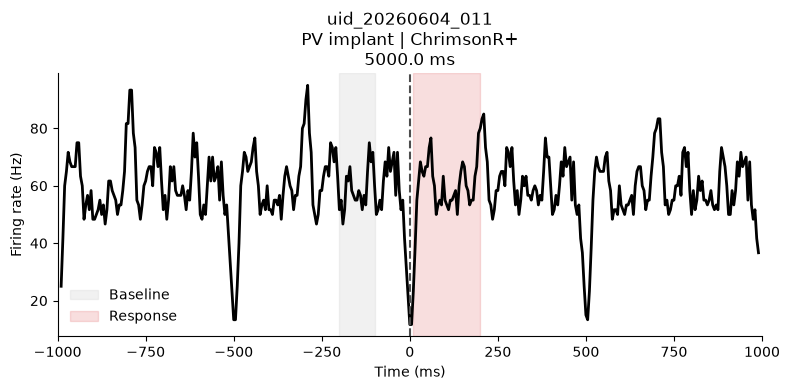

In [ ]:
#50C *Previously 48C()
# ==========================================
# Plot single unit PSTH
# ==========================================

"""
Plot the PSTH of a selected unit from the
current heatmap.

Useful for verifying that the heatmap and
population statistics are using the expected
responses.
"""

# ==========================================
# Unit selection
# ==========================================

selected_unit = "uid_20260604_011"

# ==========================================
# Locate unit
# ==========================================

matches = []

for key, entry in unit_psth.items():

    if selected_unit in entry["unit_ids"]:

        matches.append(entry)

# ------------------------------------------
# Check
# ------------------------------------------

if len(matches) == 0:

    raise ValueError(

        f"{selected_unit} not found."

    )

# ------------------------------------------
# Diagnostic
# ------------------------------------------

print()

print("Unit found in")

print("-------------")

for entry in matches:

    print(

        f"{entry['alignment']:>6} | "

        f"{entry['comparison_label']:<30} | "

        f"{entry['group_value']}"

    )

# ------------------------------------------
# Select dataset to plot
# ------------------------------------------

selected_entry = None

for entry in matches:

    if (

        entry["alignment"] == plot_alignment

        and

        entry["comparison_label"] == plot_comparison

        and

        entry["group_value"] == plot_stimulus

    ):

        selected_entry = entry

        break

if selected_entry is None:

    print()

    print("Requested condition not found.")

    print("Using first available dataset instead.")

    selected_entry = matches[0]

unit_index = selected_entry["unit_ids"].index(

    selected_unit

)

psth = selected_entry["matrix"][unit_index]

time = selected_entry["time"]

# ==========================================
# Plot
# ==========================================

fig, ax = plt.subplots(

    figsize=(8, 4)

)

ax.plot(

    time,

    psth,

    color="k",

    linewidth=2,

)

# Baseline window

ax.axvspan(

    baseline_window[0],

    baseline_window[1],

    color="lightgrey",

    alpha=0.3,

    label="Baseline",

)

# Response window

ax.axvspan(

    response_window[0],

    response_window[1],

    color="tab:red",

    alpha=0.15,

    label="Response",

)

# Alignment

ax.axvline(

    0,

    color="0.3",

    linestyle="--",

)

ax.set_xlim(analysis_window)

ax.set_xlabel("Time (ms)")

ax.set_ylabel("Firing rate (Hz)")

ax.set_title(

    f"{selected_unit}\n"
    f"{plot_comparison}\n"
    f"{plot_stimulus} ms"

)

ax.spines["top"].set_visible(False)

ax.spines["right"].set_visible(False)

ax.legend(frameon=False)

plt.tight_layout()

plt.show()

#### 51 Prepare plotting summary

In [ ]:
#51
# ==========================================
# Prepare plotting summary
# ==========================================

"""
Summarize unit-level statistics for plotting.

Each row of the output corresponds to one
experimental group and one stimulus condition.

The resulting dataframe is used by all
publication-quality plotting cells.
"""

# ==========================================
# Select metric
# ==========================================

metric = statistic

metric_labels = {

    "baseline_rate": "Baseline firing rate (Hz)",

    "response_rate": "Response firing rate (Hz)",

    "peak_rate": "Peak firing rate (Hz)",

    "peak_latency": "Peak latency (ms)",

    "onset_latency": "Response onset latency (ms)",

    "response_amplitude": "Response amplitude (Hz)",

    "auc": "Area under curve",

    "baseline_corrected_auc":
        "Baseline-corrected AUC",

    "modulation_index":
        "Modulation index",

    "peak_zscore":
        "Peak z-score",

}

metric_label = metric_labels[metric]

# ==========================================
# Aggregate statistics
# ==========================================

statistics_plotting_summary = (

    population_statistics

    .groupby(

        [

            "alignment",

            "comparison_label",

            "group_value",

        ],

        as_index=False,

    )

    .agg(

        mean=(

            metric,

            "mean",

        ),

        median=(

            metric,

            "median",

        ),

        sd=(

            metric,

            "std",

        ),

        sem=(

            metric,

            "sem",

        ),

        n=(

            metric,

            "count",

        ),

    )

)

# ==========================================
# Sort rows
# ==========================================

statistics_plotting_summary = (

    statistics_plotting_summary

    .sort_values(

        [

            "alignment",

            "comparison_label",

            "group_value",

        ]

    )

    .reset_index(

        drop=True

    )

)

# ------------------------------------------
# Store metric information
# ------------------------------------------

statistics_plotting_summary["metric"] = metric

statistics_plotting_summary["metric_label"] = metric_label

statistics_plotting_summary["view"] = view

statistics_plotting_summary["baseline_mode"] = baseline_mode

statistics_plotting_summary["event"] = event

# ==========================================
# Summary
# ==========================================

print()

print("Plotting summary")

print("----------------")

print(

    f"Metric : {metric_label}"

)

print(

    f"Rows   : {len(statistics_plotting_summary)}"

)

print(

    f"Groups : "

    f"{statistics_plotting_summary['comparison_label'].nunique()}"

)

print(

    f"Stimuli: "

    f"{statistics_plotting_summary['group_value'].nunique()}"

)

print()

print("Stimulus values")

print(

    sorted(

        statistics_plotting_summary["group_value"].unique()

    )

)

display(

    statistics_plotting_summary

)


Plotting summary
----------------
Metric : Peak firing rate (Hz)
Rows   : 64
Groups : 4
Stimuli: 8

Stimulus values
[np.float64(1.0), np.float64(5.0), np.float64(10.0), np.float64(30.0), np.float64(100.0), np.float64(500.0), np.float64(1000.0), np.float64(5000.0)]


,alignment,comparison_label,group_value,mean,median,sd,sem,n,metric,metric_label,view,baseline_mode,event
0,offset,Inert implant | ChrimsonR+,1.0,26.041667,19.166667,27.472028,9.712829,8,peak_rate,Peak firing rate (Hz),Laser,onset_baseline,onset
1,offset,Inert implant | ChrimsonR+,5.0,25.000000,14.166667,28.199966,9.970194,8,peak_rate,Peak firing rate (Hz),Laser,onset_baseline,onset
2,offset,Inert implant | ChrimsonR+,10.0,24.375000,20.000000,25.243850,8.925049,8,peak_rate,Peak firing rate (Hz),Laser,onset_baseline,onset
3,offset,Inert implant | ChrimsonR+,30.0,24.791667,15.000000,29.147102,10.305057,8,peak_rate,Peak firing rate (Hz),Laser,onset_baseline,onset
4,offset,Inert implant | ChrimsonR+,100.0,30.416667,20.833333,32.741775,11.575965,8,peak_rate,Peak firing rate (Hz),Laser,onset_baseline,onset
...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,onset,PV implant | ChrimsonR−,30.0,8.472222,3.333333,11.936999,2.436630,24,peak_rate,Peak firing rate (Hz),Laser,onset_baseline,onset
60,onset,PV implant | ChrimsonR−,100.0,3.750000,0.000000,7.913329,1.615301,24,peak_rate,Peak firing rate (Hz),Laser,onset_baseline,onset
61,onset,PV implant | ChrimsonR−,500.0,27.361111,24.166667,20.612110,4.207429,24,peak_rate,Peak firing rate (Hz),Laser,onset_baseline,onset
62,onset,PV implant | ChrimsonR−,1000.0,29.861111,25.833333,20.161885,4.115528,24,peak_rate,Peak firing rate (Hz),Laser,onset_baseline,onset


#### 52 Plotting helper

In [ ]:
#52
# ==========================================
# Publication plotting helper
# ==========================================

"""
Shared plotting functions for publication-
quality population statistics.

Each point represents one unit.

The helper draws

    • boxplots
    • jittered unit values
    • mean ± SEM

Statistical annotations are added later.
"""

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ==========================================
# Appearance
# ==========================================

box_width = 0.32

group_spacing = 0.40

condition_spacing = 1.8

jitter_width = 0.06

point_size = 24

point_alpha = 0.70

mean_size = 70

# ==========================================
# Plot helper
# ==========================================

def plot_population_statistic(

    data,

    metric,

    ylabel,

):

    """
    Plot one population statistic.

    Parameters
    ----------
    data : pandas.DataFrame

        population_statistics

    metric : str

        Column to plot.

    ylabel : str

        Y-axis label.
    """

    # --------------------------------------
    # Select alignment
    # --------------------------------------

    plot_data = data.loc[

        data["alignment"] == plot_alignment

    ].copy()

    # --------------------------------------
    # Optional stimulus selection
    # --------------------------------------

    if selected_group_values is not None:

        plot_data = plot_data.loc[

            plot_data["group_value"].isin(

                selected_group_values

            )

        ]

    if plot_data.empty:

        print("No data available.")

        return

    # --------------------------------------
    # Ordering
    # --------------------------------------

    stimulus_values = sorted(

        plot_data["group_value"].unique()

    )

    comparison_values = sorted(

        plot_data["comparison_label"].unique()

    )

    # --------------------------------------
    # Figure
    # --------------------------------------

    fig, ax = plt.subplots(

        figsize=(

            max(10, len(stimulus_values) * 2.2),

            6.5,

        )

    )

    xticks = []

    xticklabels = []

    legend_handles = []

    # --------------------------------------
    # Plot groups
    # --------------------------------------

    for stim_index, stimulus in enumerate(

        stimulus_values

    ):

        centre = stim_index * condition_spacing

        xticks.append(centre)

        xticklabels.append(str(stimulus))

        n_groups = len(comparison_values)

        step = box_width * 1.4

        offsets = (

            np.arange(n_groups)

            - (n_groups - 1) / 2

        ) * step

        for offset, group in zip(

            offsets,

            comparison_values,

        ):

            subset = plot_data.loc[

                (plot_data["group_value"] == stimulus)

                &

                (plot_data["comparison_label"] == group),

                metric,

            ].dropna()

            if subset.empty:

                continue

            x = centre + offset

            comparison_key = plot_data.loc[

                (plot_data["group_value"] == stimulus)

                &

                (plot_data["comparison_label"] == group),

                "comparison_key",

            ].iloc[0]

            colour = get_comparison_colour(

                comparison_key,

                statistics_comparison_groups,

                statistics_comparison_styles,

            )

            # ------------------------------
            # Boxplot
            # ------------------------------

            ax.boxplot(

                subset,

                positions=[x],

                widths=box_width,

                patch_artist=True,

                showfliers=False,

                boxprops=dict(

                    facecolor="none",

                    edgecolor=colour,

                    linewidth=1.6,

                ),

                whiskerprops=dict(

                    color=colour,

                    linewidth=1.4,

                ),

                capprops=dict(

                    color=colour,

                ),

                medianprops=dict(

                    color=colour,

                    linewidth=2,

                ),

            )

            # ------------------------------
            # Individual units
            # ------------------------------

            if show_points:

                jitter = np.random.uniform(

                    -jitter_width,

                    jitter_width,

                    len(subset),

                )

                ax.scatter(

                    np.full(

                        len(subset),

                        x,

                    ) + jitter,

                    subset,

                    s=point_size,

                    color=colour,

                    alpha=point_alpha,

                    zorder=3,

                )

            # ------------------------------
            # Mean ± SEM
            # ------------------------------

            if show_mean:

                mean = subset.mean()

                sem = subset.sem()

                ax.errorbar(

                    x,

                    mean,

                    yerr=sem,

                    fmt="o",

                    color=colour,

                    markersize=7,

                    linewidth=2,

                    capsize=4,

                    zorder=5,

                )

            if stim_index == 0:

                legend_handles.append(

                    mpatches.Patch(

                        facecolor="none",

                        edgecolor=colour,

                        label=group,

                    )

                )

    # --------------------------------------
    # Axes
    # --------------------------------------

    ax.set_xticks(

        xticks

    )

    ax.set_xticklabels(

        xticklabels

    )

    ax.set_xlabel(

        protocol.capitalize()

    )

    ax.set_ylabel(

        ylabel

    )

    ax.spines["top"].set_visible(False)

    ax.spines["right"].set_visible(False)

    ax.legend(

        handles=legend_handles,

        frameon=False,

    )

    plt.tight_layout()

    plt.show()

#### 53 Response Frequency plot


Comparison labels
['Inert implant | ChrimsonR+', 'Inert implant | ChrimsonR−', 'PV implant | ChrimsonR+', 'PV implant | ChrimsonR−']


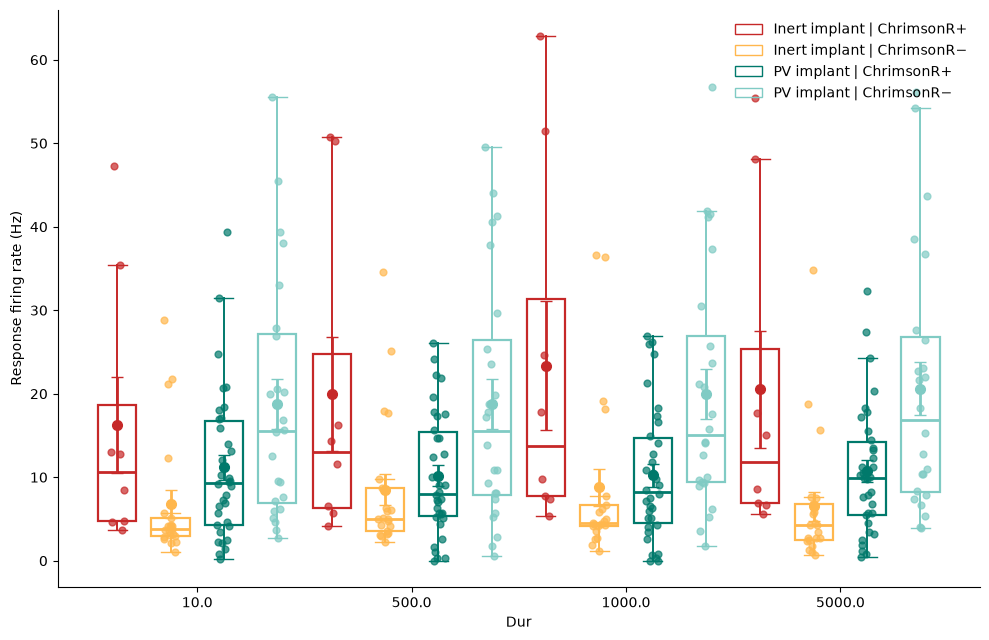


Response firing rate figure
---------------------------
Alignment : onset
Units     : 76
Groups    : 4
Stimuli   : 8


In [ ]:
#53
# ==========================================
# Plot response firing rate
# ==========================================

"""
Publication-quality plot of unit response
firing rates.

Each point represents one unit.

Response firing rate is computed from the
response window defined in #49.
"""

print()

print("Comparison labels")

print(
    sorted(
        population_statistics["comparison_label"].unique()
    )
)

# ==========================================
# Plot
# ==========================================

plot_population_statistic(

    data=population_statistics,

    metric="response_rate",

    ylabel="Response firing rate (Hz)",

)

# ==========================================
# Summary
# ==========================================

print()

print("Response firing rate figure")

print("---------------------------")

print(
    f"Alignment : {plot_alignment}"
)

print(
    f"Units     : "
    f"{population_statistics.loc[population_statistics['alignment'] == plot_alignment, 'unit_id'].nunique()}"
)

print(
    f"Groups    : "
    f"{population_statistics.loc[population_statistics['alignment'] == plot_alignment, 'comparison_label'].nunique()}"
)

print(
    f"Stimuli   : "
    f"{population_statistics.loc[population_statistics['alignment'] == plot_alignment, 'group_value'].nunique()}"
)

In [ ]:
print(sorted(population_statistics["comparison_label"].unique()))

['Inert implant | ChrimsonR+', 'Inert implant | ChrimsonR−', 'PV implant | ChrimsonR+', 'PV implant | ChrimsonR−']


#### 54 Baseline versus response firing rate


Baseline vs response comparison
-------------------------------
Units     : 76
Groups    : 4
Stimuli   : [np.float64(10.0), np.float64(500.0), np.float64(1000.0), np.float64(5000.0)]

Values used for plotting
------------------------


,unit_id,comparison_label,group_value,baseline_rate,peak_rate,response_amplitude,peak_latency,detected_response_polarity,has_excitation,has_inhibition
648,uid_20260603_001,Inert implant | ChrimsonR+,10.0,46.904762,73.333333,26.428571,40.0,absolute,False,False
649,uid_20260603_002,Inert implant | ChrimsonR+,10.0,17.222222,25.000000,7.777778,45.0,absolute,False,False
650,uid_20260603_003,Inert implant | ChrimsonR+,10.0,6.111111,0.000000,-6.111111,10.0,inhibition,False,True
651,uid_20260603_005,Inert implant | ChrimsonR+,10.0,16.190476,21.666667,5.476190,100.0,absolute,False,False
652,uid_20260603_006,Inert implant | ChrimsonR+,10.0,3.809524,8.333333,4.523810,195.0,absolute,False,False
...,...,...,...,...,...,...,...,...,...,...
187,uid_20260604_031,PV implant | ChrimsonR−,5000.0,8.968254,0.000000,-8.968254,180.0,inhibition,False,True
188,uid_20260604_036,PV implant | ChrimsonR−,5000.0,38.730159,60.000000,21.269841,160.0,absolute,False,False
189,uid_20260604_038,PV implant | ChrimsonR−,5000.0,10.476190,15.000000,4.523810,100.0,absolute,False,False
190,uid_20260604_039,PV implant | ChrimsonR−,5000.0,7.539683,0.000000,-7.539683,10.0,inhibition,False,True



         unit_id           comparison_label  group_value  baseline_rate  peak_rate  response_amplitude  peak_latency detected_response_polarity  has_excitation  has_inhibition
uid_20260603_001 Inert implant | ChrimsonR+        10.00          46.90      73.33               26.43         40.00                   absolute           False           False
uid_20260603_002 Inert implant | ChrimsonR+        10.00          17.22      25.00                7.78         45.00                   absolute           False           False
uid_20260603_003 Inert implant | ChrimsonR+        10.00           6.11       0.00               -6.11         10.00                 inhibition           False            True
uid_20260603_005 Inert implant | ChrimsonR+        10.00          16.19      21.67                5.48        100.00                   absolute           False           False
uid_20260603_006 Inert implant | ChrimsonR+        10.00           3.81       8.33                4.52        195.00   

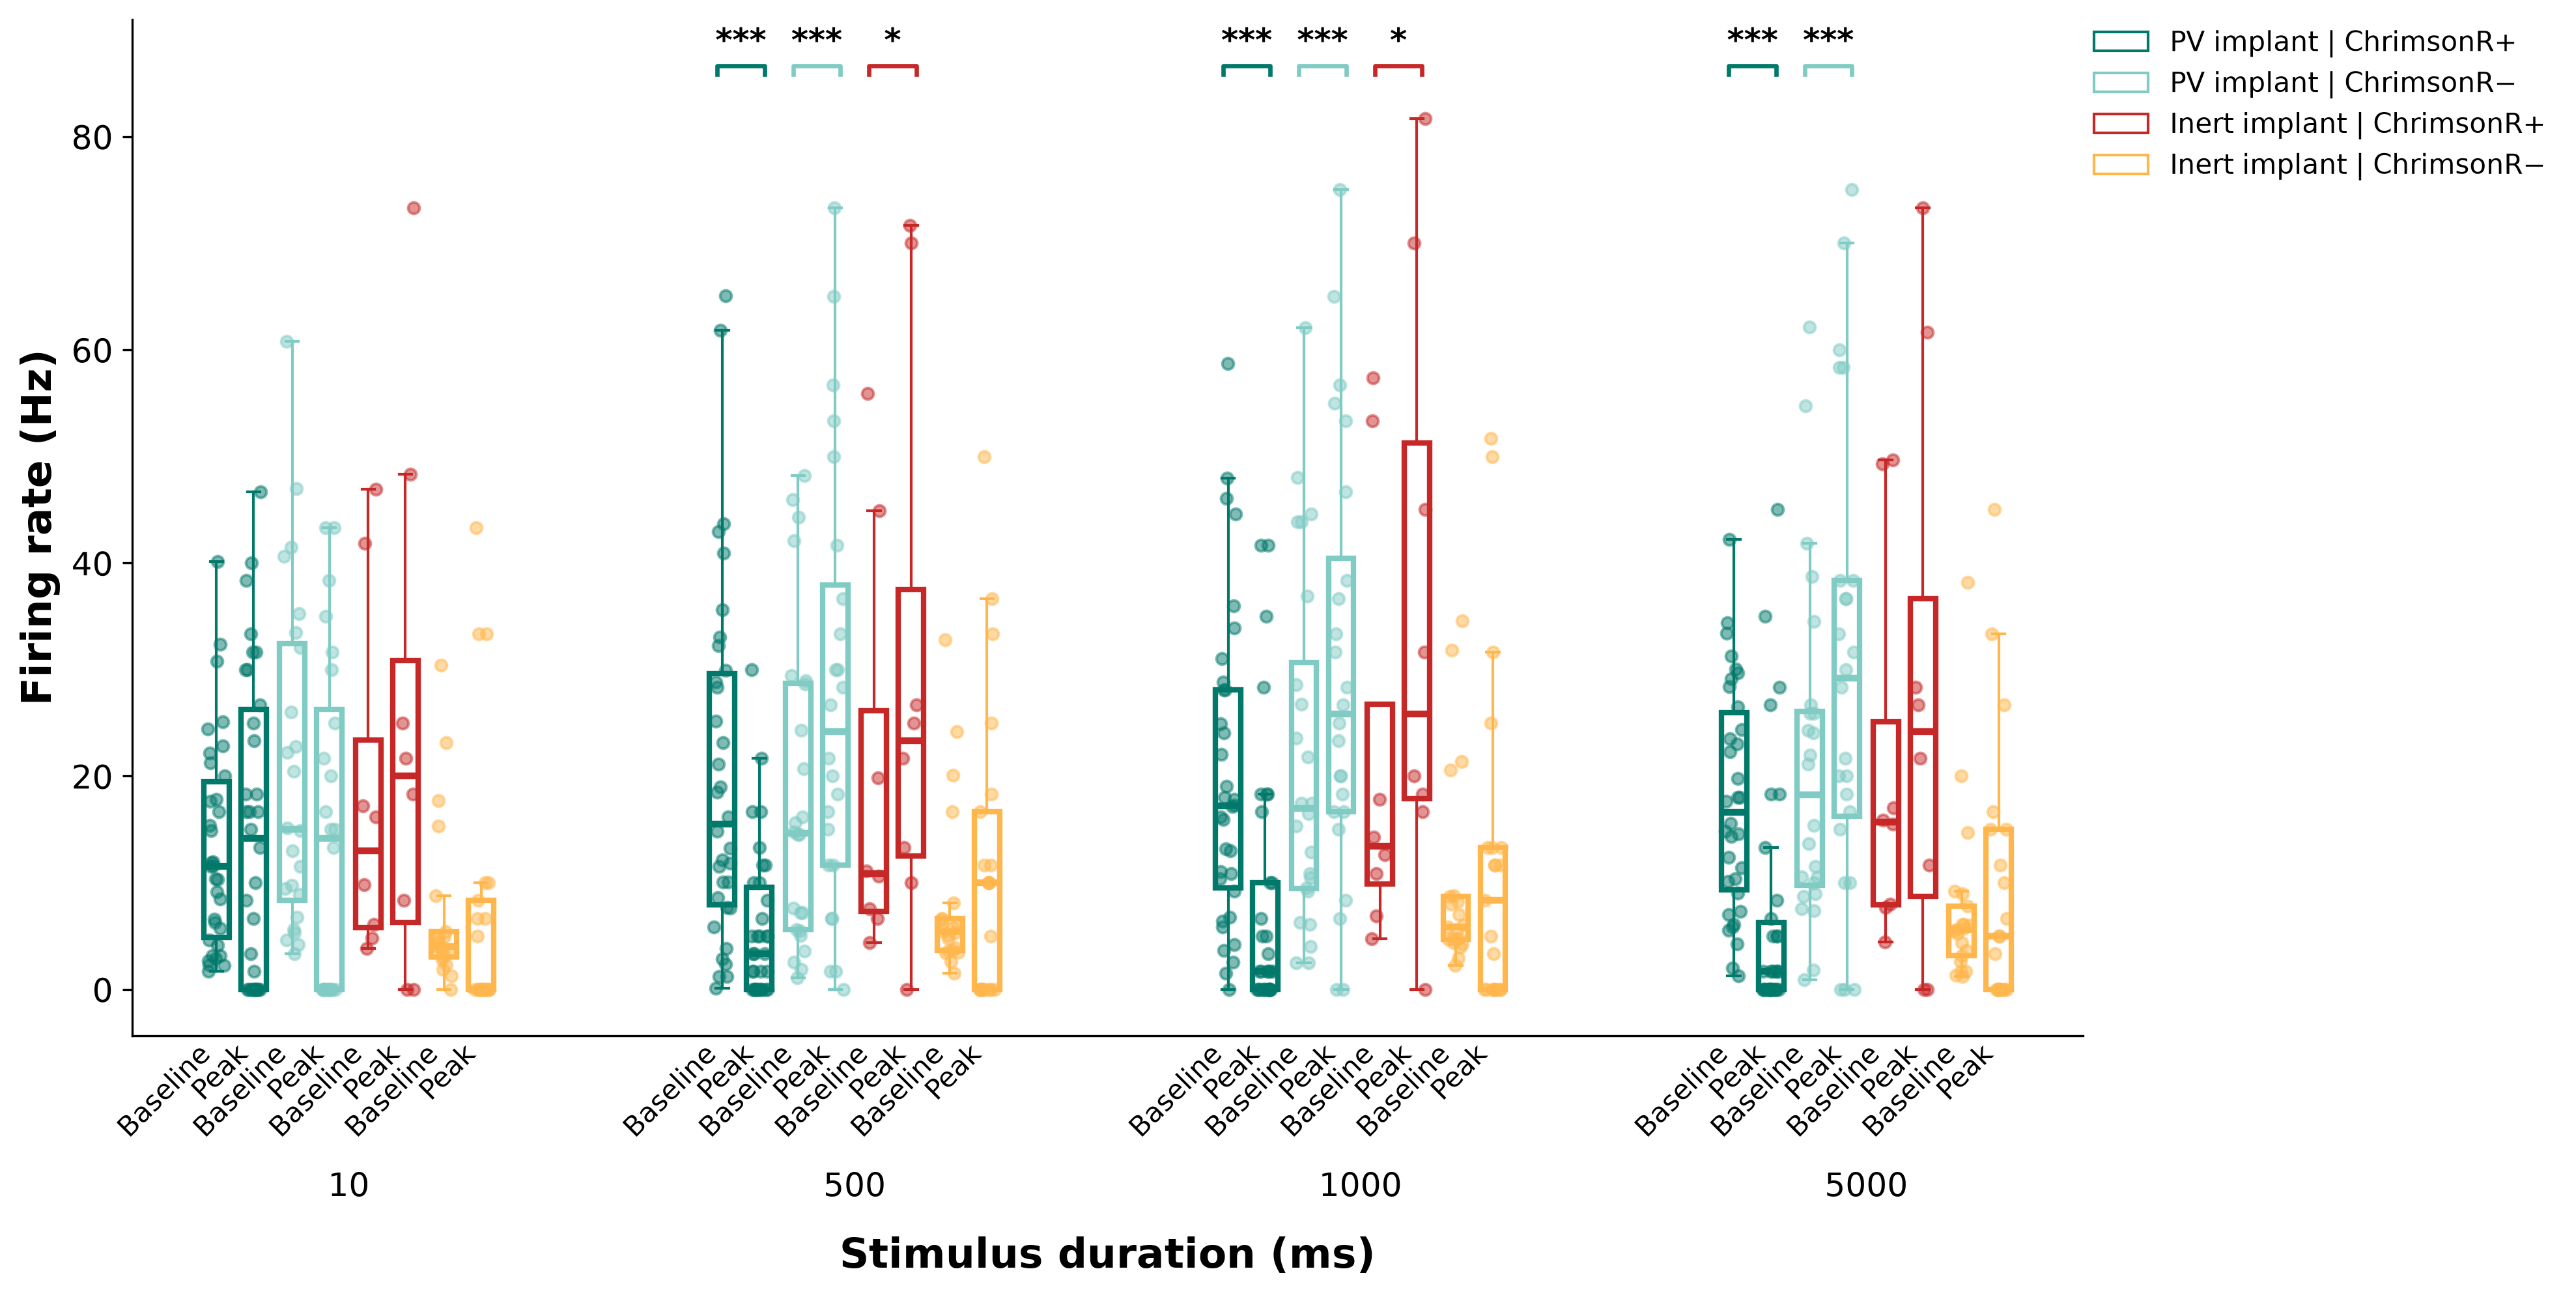

In [ ]:
#54
# ==========================================
# Baseline vs response firing rate
# ==========================================

"""
Compare baseline and response firing rates.

This cell is driven by #49

Each point represents one unit.
"""

import matplotlib.patches as mpatches

# ==========================================
# Select data
# ==========================================

plot_df = population_statistics.copy()

plot_df = plot_df.loc[
    plot_df["alignment"] == plot_alignment
]

if selected_group_values is not None:

    plot_df = plot_df.loc[
        plot_df["group_value"].isin(
            selected_group_values
        )
    ]

# ==========================================
# Select comparison groups
# ==========================================

if selected_comparison_keys is not None:

    plot_df = plot_df.loc[
        plot_df["comparison_key"].isin(
            selected_comparison_keys
        )
    ]

# ==========================================
# Summary
# ==========================================

print()

print("Baseline vs response comparison")
print("-------------------------------")

print(
    f"Units     : {plot_df['unit_id'].nunique()}"
)

print(
    f"Groups    : {plot_df['comparison_label'].nunique()}"
)

print(
    f"Stimuli   : {sorted(plot_df['group_value'].unique())}"
)

# ==========================================
# Reshape data
# ==========================================

"""
Convert the wide-format statistics table into
long format so baseline and response firing
rates can be plotted together.
"""

# ==========================================
# Diagnostic
# ==========================================

print()

print("Values used for plotting")

print("------------------------")

diagnostic_columns = [

    "unit_id",

    "comparison_label",

    "group_value",

    "baseline_rate",

    "peak_rate",

    "response_amplitude",

    "peak_latency",

    "detected_response_polarity",

    "has_excitation",

    "has_inhibition",

]

diagnostic_df = (

    plot_df[diagnostic_columns]

    .sort_values(

        [

            "comparison_label",

            "group_value",

            "unit_id",

        ]

    )

)

display(diagnostic_df)

print()

print(

    diagnostic_df.to_string(

        index=False,

        float_format=lambda x: f"{x:8.2f}",

    )

)

# ==========================================
# Comparison order
# ==========================================

if selected_comparison_keys is None:

    comparison_order = sorted(

        plot_df["comparison_key"].unique(),

        key=lambda x: get_comparison_label(
            x,
            statistics_comparison_groups,
            statistics_comparison_styles,
        ),

    )

else:

    comparison_order = selected_comparison_keys

# ==========================================
# Paired statistical tests
# ==========================================

from scipy.stats import wilcoxon

paired_statistics = {}

for duration in selected_group_values:

    for comparison_key in comparison_order:

        subset = plot_df.loc[

            (plot_df["alignment"] == plot_alignment)

            &

            (plot_df["group_value"] == duration)

            &

            (plot_df["comparison_key"] == comparison_key)

        ]

        if len(subset) < 2:

            continue

        result = wilcoxon(

            subset["baseline_rate"],

            subset["peak_rate"],

            alternative="two-sided",

        )

        paired_statistics[

            (duration, comparison_key)

        ] = result

print()

print("Paired Wilcoxon tests")

print("---------------------")

for key, result in paired_statistics.items():

    duration, comparison_key = key

    print(

        f"{duration:>6} ms | "

        f"{get_comparison_label(comparison_key, statistics_comparison_groups, statistics_comparison_styles):<30} "

        f"p = {result.pvalue:.4g}"

    )

# --------------------------------------
# Convert to long format
# --------------------------------------

plot_df = plot_df.melt(

    id_vars=[
        "comparison_key",
        "comparison_label",
        "group_value",
        "unit_id",
    ],

    value_vars=[
        "baseline_rate",
        "peak_rate",
    ],

    var_name="epoch",

    value_name="rate",

)

# ==========================================
# Figure
# ==========================================

global_ymax = plot_df["rate"].max()
significance_y = global_ymax + 5

fig, ax = plt.subplots(

    figsize=(

        max(12, len(selected_group_values) * 3.2),

        8,

    ),

    dpi=300,

)

duration_spacing = 3.0

group_spacing = 0.45

epoch_spacing = 0.22

box_width = 0.15

legend_handles = []

xticks = []

xticklabels = []

minor_xticks = []

minor_xticklabels = []

# ==========================================
# Plot baseline and response firing rates
# ==========================================

for duration_index, duration in enumerate(

    selected_group_values

):

    duration_origin = duration_index * duration_spacing

    duration_width = group_spacing * (len(comparison_order) - 1)

    duration_centre = duration_origin + duration_width / 2

    xticks.append(duration_centre)

    xticklabels.append(str(duration))

    for group_index, comparison_key in enumerate(

        comparison_order

    ):

        colour = get_comparison_colour(

            comparison_key,

            statistics_comparison_groups,

            statistics_comparison_styles,

        )

        group_offset = (

            group_index - 0.5

        ) * group_spacing

        for epoch_index, epoch in enumerate(

            [

                "baseline_rate",

                "peak_rate",

            ]

        ):

            epoch_offset = (

                epoch_index - 0.5

            ) * epoch_spacing

            x = (

                duration_origin

                + group_index * group_spacing

                + epoch_offset

            )

            if epoch == "baseline_rate":

                baseline_x = x

            else:

                peak_x = x

            minor_xticks.append(x)

            minor_xticklabels.append(

                "Baseline"

                if epoch == "baseline_rate"

                else "Peak"

            )

            subset = plot_df.loc[

                (plot_df["group_value"] == duration)

                &

                (plot_df["comparison_key"] == comparison_key)

                &

                (plot_df["epoch"] == epoch),

                "rate",

            ]

            if subset.empty:

                continue

            ax.boxplot(

                subset,

                positions=[x],

                widths=box_width,

                showfliers=False,

                patch_artist=True,

                boxprops=dict(

                    facecolor="none",

                    edgecolor=colour,

                    linewidth=2,

                ),

                whiskerprops=dict(

                    color=colour,

                ),

                capprops=dict(

                    color=colour,

                ),

                medianprops=dict(

                    color=colour,

                    linewidth=2.5,

                ),

            )

            jitter = np.random.uniform(

                -0.05,

                0.05,

                len(subset),

            )

            ax.scatter(

                np.full(

                    len(subset),

                    x,

                ) + jitter,

                subset,

                s=18,

                color=colour,

                alpha=0.5,

            )

        if (

            show_pairwise_statistics

            and epoch == "peak_rate"

        ):

            result = paired_statistics.get(

                (duration, comparison_key),

                None,

            )

            if result is not None:

                p = result.pvalue

                if p < 0.001:

                    stars = "***"

                elif p < 0.01:

                    stars = "**"

                elif p < 0.05:

                    stars = "*"

                else:

                    stars = None

                if stars is not None:

                    y = significance_y

                    bar_padding = 0.03

                    ax.plot(

                        [

                            baseline_x - bar_padding,

                            baseline_x - bar_padding,

                            peak_x + bar_padding,

                            peak_x + bar_padding,

                        ],

                        [

                            y - 0.8,

                            y,

                            y,

                            y - 0.8,

                        ],

                        color=colour,

                        linewidth=1.6,

                    )

                    ax.text(

                        (baseline_x + peak_x) / 2,

                        y + 0.6,

                        stars,

                        ha="center",

                        va="bottom",

                        fontsize=12,

                        fontweight="bold",

                    )   

        if duration_index == 0:

            legend_handles.append(

                mpatches.Patch(

                    facecolor="none",

                    edgecolor=colour,

                    label=get_comparison_label(

                        comparison_key,

                        statistics_comparison_groups,

                        statistics_comparison_styles,

                    ),

                )

            )

# ==========================================
# Format figure
# ==========================================

# Major ticks (stimulus duration)

ax.set_xticks(xticks)

ax.set_xticklabels(

    xticklabels,

    fontsize=13,

)

# Minor ticks (Baseline / Peak)

ax.set_xticks(

    minor_xticks,

    minor=True,

)

ax.set_xticklabels(

    minor_xticklabels,

    minor=True,

    rotation=45,

    ha="right",

    fontsize=10,

)

ax.tick_params(

    axis="x",

    which="major",

    pad=50,

    length=0,

)

ax.tick_params(

    axis="x",

    which="minor",

    pad=2,

    length=0,

)

ax.set_xlabel(

    "Stimulus duration (ms)",

    fontsize=15,

    fontweight="bold",

    labelpad=12,

)

ax.set_ylabel(

    "Firing rate (Hz)",

    fontsize=15,

    fontweight="bold",

)

ax.tick_params(

    axis="both",

    labelsize=12,

)

ax.spines["top"].set_visible(False)

ax.spines["right"].set_visible(False)

ax.legend(

    handles=legend_handles,

    loc="upper left",

    bbox_to_anchor=(1.00, 1.00),

    borderaxespad=0,

    frameon=False,

    fontsize=10,

)

plt.subplots_adjust(

    bottom=0.30,

    left=0.10,

    right=0.88,

    top=0.95,

)

plt.show()


### Appendix: Debugging

In [ ]:
from pathlib import Path
from pv_chip_aarhus.preprocessing.params import dataset_dir

sid = "20260601_eye1_1st"

trigger_dir = Path(dataset_dir) / sid / "trigger_files"
stim_dir = Path(dataset_dir) / sid / "stim_files"

print("Trigger files:")
for f in sorted(trigger_dir.glob("*_triggers.pkl")):
    print(f.name)

print("\nStim files:")
for f in sorted(stim_dir.glob("*.dat")):
    print(f.name)

Trigger files:

Stim files:


In [ ]:
# from pv_chip_aarhus.preprocessing.lib.filepaths import FilePaths

# sid = "20260601_eye1_1st"

# filepaths = FilePaths(sid)

In [ ]:
# display(filepaths.recording_table)

In [ ]:
# from pathlib import Path
# from pv_chip_aarhus.preprocessing.params import dataset_dir

# sid = "20260601_eye1_1st"

# trigger_dir = (
#     Path(dataset_dir)
#     / sid
#     / "trigger_files"
# )

# print("Trigger directory:")
# print(trigger_dir)

# for file in trigger_dir.iterdir():
#     if "_triggers.pkl" in file.name:
#         parts = file.name.split("_")

#         print("\nFilename:")
#         print(file.name)

#         print(f"Number of parts: {len(parts)}")

#         for i, part in enumerate(parts):
#             print(i, part)